# Bài tập 1 — Hiểu dữ liệu, chọn dữ liệu và tiền xử lý

**Ba bộ dữ liệu khảo sát (đã chốt, khớp Mục 2.1 của đề bài):**
1. **Bộ 1 — Olist Brazilian E-Commerce** → Phân lớp + Gom cụm
2. **Bộ 2 — Inside Airbnb Listings** → Luật kết hợp + Gom cụm
3. **Bộ 3 — US Accidents (2016–2023)** → Phân lớp + Luật kết hợp

Ba kỹ thuật (Phân lớp, Luật kết hợp, Gom cụm) đều được phủ đủ, mỗi bộ
dữ liệu đảm nhận đúng 2 kỹ thuật theo yêu cầu Mục 2 của đề bài.

Notebook này thực hiện đầy đủ nội dung Bài 1 theo đề:
- **Mục 3.2** (đề xuất từng bộ): nguồn/giấy phép/quy mô, từ điển dữ liệu,
  điều tra tri thức lĩnh vực, lập luận khả năng khai phá, đề xuất 2 kỹ
  thuật cho từng bộ.
- **Mục 3.3** (điều tra tiền xử lý): nhiễu/ngoại lai, giá trị thiếu,
  thêm/xóa/biến đổi thuộc tính — cho cả 3 bộ.
- **Mục 2.1** (ma trận bộ dữ liệu × kỹ thuật): tổng hợp ở gần cuối notebook.
- **Bàn giao dữ liệu cho Bài 2–4**: xuất 6 dataset đã tiền xử lý riêng
  theo từng kỹ thuật, lưu tại `data/processed/`, kèm kiểm tra điều kiện
  đầu vào (Mục 9 của notebook) để các thành viên khác trong nhóm dùng
  trực tiếp cho Bài 2 (Phân lớp), Bài 3 (Luật kết hợp), Bài 4 (Gom cụm)
  mà không cần chạy lại Bài 1.

> **Cách dùng:** đặt dữ liệu gốc vào `data/raw/{olist,airbnb,us_accidents}/`
> theo đúng cấu trúc ở mỗi phần, rồi chạy lại toàn bộ notebook theo thứ tự
> từ trên xuống (Run All). Các số liệu, biểu đồ trong notebook là kết quả
> chạy thật trên dữ liệu đã tải.


In [29]:
# ==== Thiết lập chung ====
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 200)
sns.set_theme(style='whitegrid')

from pathlib import Path
PROJECT_ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'data').is_dir() and (p / 'requirements.txt').is_file()), None)
if PROJECT_ROOT is None:
    raise FileNotFoundError('Hãy mở notebook từ thư mục dự án data_mining_project hoặc thư mục con của nó.')
RAW_DIR = PROJECT_ROOT / 'data' / 'raw'
PROCESSED_DIR = PROJECT_ROOT / 'data' / 'processed'
print('Thư mục dữ liệu gốc:', RAW_DIR)


Thư mục dữ liệu gốc: c:\Users\Chien\data_mining_project\data\raw


## Hàm tiện ích dùng chung cho cả 3 bộ dữ liệu

Các hàm dưới đây được viết một lần và tái sử dụng cho cả 3 bộ, tránh lặp code.

In [30]:
def data_dictionary(df: pd.DataFrame) -> pd.DataFrame:
    """Sinh bảng từ điển dữ liệu tự động: kiểu, số giá trị duy nhất, tỉ lệ thiếu, min/max sơ bộ.
    Nhóm dùng bảng này làm điểm khởi đầu, sau đó bổ sung cột 'Ý nghĩa' và 'Thang đo' bằng tay.
    """
    rows = []
    for col in df.columns:
        s = df[col]
        rows.append({
            'thuoc_tinh': col,
            'kieu_du_lieu': str(s.dtype),
            'so_gia_tri_duy_nhat': s.nunique(dropna=True),
            'ti_le_thieu_%': round(s.isna().mean() * 100, 2),
            'gia_tri_min': s.min() if pd.api.types.is_numeric_dtype(s) else None,
            'gia_tri_max': s.max() if pd.api.types.is_numeric_dtype(s) else None,
            'vi_du': s.dropna().iloc[0] if s.notna().any() else None,
        })
    return pd.DataFrame(rows)


def missing_value_report(df: pd.DataFrame, threshold: float = 0.0) -> pd.DataFrame:
    """Báo cáo tỉ lệ thiếu theo từng cột, sắp xếp giảm dần. threshold: chỉ hiện cột có tỉ lệ thiếu > threshold (%)."""
    miss = df.isna().mean().mul(100).round(2).sort_values(ascending=False)
    miss = miss[miss > threshold]
    return miss.to_frame('ti_le_thieu_%')


def outlier_iqr_report(df: pd.DataFrame, cols: list) -> pd.DataFrame:
    """Đếm số ngoại lai theo phương pháp IQR cho từng cột số được chỉ định."""
    rows = []
    for col in cols:
        s = df[col].dropna()
        q1, q3 = s.quantile(0.25), s.quantile(0.75)
        iqr = q3 - q1
        lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
        n_outliers = ((s < lower) | (s > upper)).sum()
        rows.append({
            'thuoc_tinh': col, 'Q1': q1, 'Q3': q3, 'IQR': iqr,
            'nguong_duoi': lower, 'nguong_tren': upper,
            'so_ngoai_lai': n_outliers,
            'ti_le_ngoai_lai_%': round(n_outliers / len(s) * 100, 2) if len(s) else np.nan,
        })
    return pd.DataFrame(rows)


def plot_boxplots(df: pd.DataFrame, cols: list, ncols: int = 3, figsize_scale: float = 4):
    """Vẽ boxplot cho danh sách cột số để trực quan hóa ngoại lai."""
    n = len(cols)
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(figsize_scale * ncols, figsize_scale * nrows))
    axes = np.array(axes).reshape(-1)
    for i, col in enumerate(cols):
        sns.boxplot(y=df[col].dropna(), ax=axes[i])
        axes[i].set_title(col)
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])
    plt.tight_layout()
    plt.show()


In [31]:
# ============================================================
# BỔ SUNG Ý NGHĨA + THANG ĐO CHO DATA DICTIONARY
# ============================================================

def add_metadata_to_dictionary(df, dictionary_df, meaning_map=None, scale_map=None):
    """
    Bổ sung:
        - y_nghia
        - thang_do

    vào bảng data dictionary hiện có.

    Đồng thời kiểm tra để bảo đảm không có thuộc tính nào
    bị bỏ sót.
    """

    meaning_map = meaning_map or {}
    scale_map = scale_map or {}

    result = dictionary_df.copy()

    result["y_nghia"] = result["thuoc_tinh"].map(meaning_map)
    result["thang_do"] = result["thuoc_tinh"].map(scale_map)

    # Nếu chưa khai báo riêng, cố gắng suy luận theo kiểu dữ liệu / tên cột
    for idx, row in result.iterrows():

        col = row["thuoc_tinh"]
        dtype = str(df[col].dtype).lower()

        # -----------------------------
        # Ý nghĩa mặc định
        # -----------------------------
        if pd.isna(result.at[idx, "y_nghia"]):

            if col.lower().endswith("_id") or col.lower() == "id":
                result.at[idx, "y_nghia"] = (
                    f"Mã định danh của {col}"
                )

            elif "url" in col.lower():
                result.at[idx, "y_nghia"] = (
                    f"Địa chỉ URL liên quan đến {col}"
                )

            elif "date" in col.lower() or "time" in col.lower():
                result.at[idx, "y_nghia"] = (
                    f"Thông tin thời gian/ngày tháng của {col}"
                )

            elif dtype == "bool":
                result.at[idx, "y_nghia"] = (
                    f"Biến nhị phân cho biết trạng thái {col}"
                )

            elif pd.api.types.is_numeric_dtype(df[col]):
                result.at[idx, "y_nghia"] = (
                    f"Giá trị định lượng của {col}"
                )

            else:
                result.at[idx, "y_nghia"] = (
                    f"Thông tin phân loại/mô tả của {col}"
                )

        # -----------------------------
        # Thang đo mặc định
        # -----------------------------
        if pd.isna(result.at[idx, "thang_do"]):

            col_lower = col.lower()

            # ID / mã / text / category
            if (
                col_lower.endswith("_id")
                or col_lower in ["id", "source"]
                or "url" in col_lower
                or "name" in col_lower
                or "city" in col_lower
                or "state" in col_lower
                or "country" in col_lower
                or "type" in col_lower
                or "category" in col_lower
                or "description" in col_lower
                or "location" in col_lower
                or "neighbourhood" in col_lower
                or "neighborhood" in col_lower
                or dtype == "bool"
            ):
                result.at[idx, "thang_do"] = "Định danh"

            # Các biến thời gian
            elif (
                "date" in col_lower
                or "time" in col_lower
                or col_lower in [
                    "last_scraped",
                    "first_review",
                    "last_review",
                    "host_since",
                    "calendar_last_scraped"
                ]
            ):
                result.at[idx, "thang_do"] = "Khoảng"

            # Biến thứ tự
            elif col_lower in [
                "severity",
                "review_score",
                "payment_sequential",
                "order_item_id"
            ]:
                result.at[idx, "thang_do"] = "Thứ tự"

            # Còn lại là biến số
            elif pd.api.types.is_numeric_dtype(df[col]):
                result.at[idx, "thang_do"] = "Tỉ lệ"

            else:
                result.at[idx, "thang_do"] = "Định danh"

    # Đổi tên cho đẹp khi đưa vào báo cáo
    result = result.rename(columns={
        "y_nghia": "Ý nghĩa",
        "thang_do": "Thang đo"
    })

    # Kiểm tra
    missing_meaning = result[
        result["Ý nghĩa"].isna()
    ]["thuoc_tinh"].tolist()

    missing_scale = result[
        result["Thang đo"].isna()
    ]["thuoc_tinh"].tolist()

    print("Số thuộc tính:", len(result))
    print("Thiếu Ý nghĩa:", len(missing_meaning))
    print("Thiếu Thang đo:", len(missing_scale))

    if missing_meaning:
        print("⚠️ Chưa có Ý nghĩa:", missing_meaning)

    if missing_scale:
        print("⚠️ Chưa có Thang đo:", missing_scale)

    return result

---
# BỘ 1: Olist Brazilian E-Commerce

**Nguồn:** https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce
**Đơn vị công bố:** Olist Store (sàn TMĐT Brazil), đăng tải qua Kaggle
**Ngày tải:** ......... *(nhóm điền ngày thực tế tải bộ dữ liệu về máy)*
**Giấy phép:** CC BY-NC-SA 4.0 — dữ liệu thương mại đã ẩn danh, chỉ dùng cho học thuật/nghiên cứu phi thương mại
**Quy mô sau khi gộp 9 bảng (số liệu thật, xem Mục 1.1):** 118.310 dòng (mỗi dòng = 1 item trong 1 đơn hàng) × 35 thuộc tính; sau loại bỏ 419 dòng trùng lặp còn 117.891 dòng × 35 cột — vượt xa ngưỡng tối thiểu 10.000 bản ghi × 30 thuộc tính của đề bài.

## 1.1 Tải dữ liệu và gộp bảng (join)


In [32]:
# Dữ liệu chính thức: https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce
# Nếu máy mới chưa có dữ liệu: tải ZIP từ nguồn trên, giải nén vào data/raw/olist/.
from zipfile import ZipFile
olist_path = Path(RAW_DIR) / 'olist'
archive = olist_path / 'olist-source.zip'
if archive.is_file():
    with ZipFile(archive) as z:
        for member in z.infolist():
            name = Path(member.filename).name
            if name.endswith('.csv') and not (olist_path / name).exists():
                with z.open(member) as src, (olist_path / name).open('wb') as dst:
                    import shutil
                    shutil.copyfileobj(src, dst)
required = ['olist_' + n + '_dataset.csv' for n in ['customers', 'orders', 'order_items', 'order_payments', 'order_reviews', 'products', 'sellers', 'geolocation']] + ['product_category_name_translation.csv']
missing = [name for name in required if not (olist_path / name).is_file()]
if missing:
    raise FileNotFoundError(f'Thiếu dữ liệu Olist tại {olist_path}: {missing}. Tải từ https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce và giải nén vào thư mục này.')
olist_dir = f'{RAW_DIR}/olist'

customers   = pd.read_csv(f'{olist_dir}/olist_customers_dataset.csv')
orders      = pd.read_csv(f'{olist_dir}/olist_orders_dataset.csv')
order_items = pd.read_csv(f'{olist_dir}/olist_order_items_dataset.csv')
payments    = pd.read_csv(f'{olist_dir}/olist_order_payments_dataset.csv')
reviews     = pd.read_csv(f'{olist_dir}/olist_order_reviews_dataset.csv')
products    = pd.read_csv(f'{olist_dir}/olist_products_dataset.csv')
sellers     = pd.read_csv(f'{olist_dir}/olist_sellers_dataset.csv')
geoloc      = pd.read_csv(f'{olist_dir}/olist_geolocation_dataset.csv')
cat_trans   = pd.read_csv(f'{olist_dir}/product_category_name_translation.csv')

print('orders:', orders.shape)
print('order_items:', order_items.shape)
print('customers:', customers.shape)


orders: (99441, 8)
order_items: (112650, 7)
customers: (99441, 5)


In [33]:
# Bảng khảo sát: item x payment x review trong một đơn; không phải 1 dòng/đơn.
# RFM và đặc trưng đơn hàng ở các mục sau được tổng hợp từ bảng gốc để tránh nhân tiền.
olist_df = (
    order_items
    .merge(orders, on='order_id', how='left', validate='many_to_one')
    .merge(customers, on='customer_id', how='left', validate='many_to_one')
    .merge(products, on='product_id', how='left', validate='many_to_one')
    .merge(sellers, on='seller_id', how='left', validate='many_to_one')
    .merge(cat_trans, on='product_category_name', how='left', validate='many_to_one')
    .merge(payments, on='order_id', how='left')
    .merge(reviews[['order_id', 'review_score']], on='order_id', how='left')
)

print('Số dòng x số cột sau khi join:', olist_df.shape)
olist_df.head()


Số dòng x số cột sau khi join: (118310, 35)


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,seller_zip_code_prefix,seller_city,seller_state,product_category_name_english,payment_sequential,payment_type,payment_installments,payment_value,review_score
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,3ce436f183e68e07877b285a838db11a,delivered,2017-09-13 08:59:02,2017-09-13 09:45:35,2017-09-19 18:34:16,2017-09-20 23:43:48,2017-09-29 00:00:00,871766c5855e863f6eccc05f988b23cb,28013,campos dos goytacazes,RJ,cool_stuff,58.0,598.0,4.0,650.0,28.0,9.0,14.0,27277,volta redonda,SP,cool_stuff,1.0,credit_card,2.0,72.19,5.0
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,f6dd3ec061db4e3987629fe6b26e5cce,delivered,2017-04-26 10:53:06,2017-04-26 11:05:13,2017-05-04 14:35:00,2017-05-12 16:04:24,2017-05-15 00:00:00,eb28e67c4c0b83846050ddfb8a35d051,15775,santa fe do sul,SP,pet_shop,56.0,239.0,2.0,30000.0,50.0,30.0,40.0,3471,sao paulo,SP,pet_shop,1.0,credit_card,3.0,259.83,4.0
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,6489ae5e4333f3693df5ad4372dab6d3,delivered,2018-01-14 14:33:31,2018-01-14 14:48:30,2018-01-16 12:36:48,2018-01-22 13:19:16,2018-02-05 00:00:00,3818d81c6709e39d06b2738a8d3a2474,35661,para de minas,MG,moveis_decoracao,59.0,695.0,2.0,3050.0,33.0,13.0,33.0,37564,borda da mata,MG,furniture_decor,1.0,credit_card,5.0,216.87,5.0
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,d4eb9395c8c0431ee92fce09860c5a06,delivered,2018-08-08 10:00:35,2018-08-08 10:10:18,2018-08-10 13:28:00,2018-08-14 13:32:39,2018-08-20 00:00:00,af861d436cfc08b2c2ddefd0ba074622,12952,atibaia,SP,perfumaria,42.0,480.0,1.0,200.0,16.0,10.0,15.0,14403,franca,SP,perfumery,1.0,credit_card,2.0,25.78,4.0
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,58dbd0b2d70206bf40e62cd34e84d795,delivered,2017-02-04 13:57:51,2017-02-04 14:10:13,2017-02-16 09:46:09,2017-03-01 16:42:31,2017-03-17 00:00:00,64b576fb70d441e8f1b2d7d446e483c5,13226,varzea paulista,SP,ferramentas_jardim,59.0,409.0,1.0,3750.0,35.0,40.0,30.0,87900,loanda,PR,garden_tools,1.0,credit_card,3.0,218.04,5.0


## 1.2 Từ điển dữ liệu (tự động sinh — bổ sung cột Ý nghĩa/Thang đo bằng tay)

In [34]:
# ============================================================
# OLIST - DATA DICTIONARY HOÀN CHỈNH
# ============================================================

olist_meaning = {

    "order_id":
        "Mã định danh duy nhất của đơn hàng",

    "order_item_id":
        "Số thứ tự của sản phẩm trong một đơn hàng",

    "product_id":
        "Mã định danh của sản phẩm",

    "seller_id":
        "Mã định danh của người bán",

    "shipping_limit_date":
        "Thời hạn dự kiến người bán giao sản phẩm cho đơn vị vận chuyển",

    "price":
        "Giá của sản phẩm trong đơn hàng",

    "freight_value":
        "Chi phí vận chuyển của sản phẩm",

    "customer_id":
        "Mã định danh của khách hàng gắn với đơn hàng",

    "order_status":
        "Trạng thái của đơn hàng",

    "order_purchase_timestamp":
        "Thời điểm khách hàng đặt hàng",

    "order_approved_at":
        "Thời điểm đơn hàng được hệ thống phê duyệt",

    "order_delivered_carrier_date":
        "Thời điểm đơn hàng được giao cho đơn vị vận chuyển",

    "order_delivered_customer_date":
        "Thời điểm đơn hàng được giao đến khách hàng",

    "order_estimated_delivery_date":
        "Thời điểm dự kiến giao đơn hàng cho khách",

    "customer_unique_id":
        "Mã định danh duy nhất của khách hàng",

    "customer_zip_code_prefix":
        "Mã vùng bưu chính của khách hàng",

    "customer_city":
        "Thành phố của khách hàng",

    "customer_state":
        "Bang của khách hàng",

    "product_category_name":
        "Danh mục của sản phẩm",

    "product_name_lenght":
        "Độ dài tên sản phẩm",

    "product_description_lenght":
        "Độ dài mô tả sản phẩm",

    "product_photos_qty":
        "Số lượng ảnh của sản phẩm",

    "product_weight_g":
        "Trọng lượng sản phẩm tính bằng gram",

    "product_length_cm":
        "Chiều dài sản phẩm tính bằng centimet",

    "product_height_cm":
        "Chiều cao sản phẩm tính bằng centimet",

    "product_width_cm":
        "Chiều rộng sản phẩm tính bằng centimet",

    "seller_zip_code_prefix":
        "Mã vùng bưu chính của người bán",

    "seller_city":
        "Thành phố của người bán",

    "seller_state":
        "Bang của người bán",

    "product_category_name_english":
        "Tên danh mục sản phẩm bằng tiếng Anh",

    "payment_sequential":
        "Thứ tự của phương thức thanh toán trong một đơn hàng",

    "payment_type":
        "Phương thức thanh toán",

    "payment_installments":
        "Số lần thanh toán trả góp",

    "payment_value":
        "Giá trị thanh toán của giao dịch",

    "review_score":
        "Điểm đánh giá của khách hàng dành cho đơn hàng"
}


olist_scale = {

    "order_id": "Định danh",
    "order_item_id": "Thứ tự",
    "product_id": "Định danh",
    "seller_id": "Định danh",
    "shipping_limit_date": "Khoảng",

    "price": "Tỉ lệ",
    "freight_value": "Tỉ lệ",

    "customer_id": "Định danh",
    "order_status": "Định danh",

    "order_purchase_timestamp": "Khoảng",
    "order_approved_at": "Khoảng",
    "order_delivered_carrier_date": "Khoảng",
    "order_delivered_customer_date": "Khoảng",
    "order_estimated_delivery_date": "Khoảng",

    "customer_unique_id": "Định danh",
    "customer_zip_code_prefix": "Định danh",
    "customer_city": "Định danh",
    "customer_state": "Định danh",

    "product_category_name": "Định danh",

    "product_name_lenght": "Tỉ lệ",
    "product_description_lenght": "Tỉ lệ",
    "product_photos_qty": "Tỉ lệ",

    "product_weight_g": "Tỉ lệ",
    "product_length_cm": "Tỉ lệ",
    "product_height_cm": "Tỉ lệ",
    "product_width_cm": "Tỉ lệ",

    "seller_zip_code_prefix": "Định danh",
    "seller_city": "Định danh",
    "seller_state": "Định danh",

    "product_category_name_english": "Định danh",

    "payment_sequential": "Thứ tự",
    "payment_type": "Định danh",
    "payment_installments": "Tỉ lệ",
    "payment_value": "Tỉ lệ",

    "review_score": "Thứ tự"
}


olist_dict = add_metadata_to_dictionary(
    olist_df,
    data_dictionary(olist_df),
    olist_meaning,
    olist_scale
)

olist_dict

Số thuộc tính: 35
Thiếu Ý nghĩa: 0
Thiếu Thang đo: 0


,thuoc_tinh,kieu_du_lieu,so_gia_tri_duy_nhat,ti_le_thieu_%,gia_tri_min,gia_tri_max,vi_du,Ý nghĩa,Thang đo
0,order_id,str,98666,0.00,NaN,NaN,00010242fe8c5a6d1ba2dd792cb16214,Mã định danh duy nhất của đơn hàng,Định danh
1,order_item_id,int64,21,0.00,1.00,21.00,1,Số thứ tự của sản phẩm trong một đơn hàng,Thứ tự
2,product_id,str,32951,0.00,NaN,NaN,4244733e06e7ecb4970a6e2683c13e61,Mã định danh của sản phẩm,Định danh
3,seller_id,str,3095,0.00,NaN,NaN,48436dade18ac8b2bce089ec2a041202,Mã định danh của người bán,Định danh
4,shipping_limit_date,str,93318,0.00,NaN,NaN,2017-09-19 09:45:35,Thời hạn dự kiến người bán giao sản phẩm cho đ...,Khoảng
5,price,float64,5968,0.00,0.85,6735.00,58.9,Giá của sản phẩm trong đơn hàng,Tỉ lệ
6,freight_value,float64,6999,0.00,0.00,409.68,13.29,Chi phí vận chuyển của sản phẩm,Tỉ lệ
7,customer_id,str,98666,0.00,NaN,NaN,3ce436f183e68e07877b285a838db11a,Mã định danh của khách hàng gắn với đơn hàng,Định danh
8,order_status,str,7,0.00,NaN,NaN,delivered,Trạng thái của đơn hàng,Định danh
9,order_purchase_timestamp,str,98112,0.00,NaN,NaN,2017-09-13 08:59:02,Thời điểm khách hàng đặt hàng,Khoảng


### Ý nghĩa và thang đo của các thuộc tính chính

- `order_id`, `customer_id`, `customer_unique_id`: thuộc tính định danh
  (Nominal/ID), dùng để nhận diện hoặc nhóm bản ghi, không dùng trực tiếp
  như biến số trong các thuật toán dựa trên khoảng cách.

- `price`, `freight_value`, `payment_value`: thuộc tính định lượng
  dạng tỉ lệ (Ratio), vì có mốc 0 có ý nghĩa và có thể thực hiện các
  phép tính số học.

- `payment_installments`, `order_item_count`: thuộc tính số nguyên,
  dùng như biến định lượng; có thể rời rạc hóa khi cần áp dụng luật
  kết hợp.

- `payment_type`, `customer_state`, `product_category_name`: thuộc tính
  hạng mục định danh (Nominal), phù hợp với one-hot encoding.

- `review_score`: thuộc tính thứ tự (Ordinal), vì điểm 1–5 có thứ tự
  tăng dần nhưng khoảng cách giữa các mức không nhất thiết thể hiện
  khoảng cách định lượng tuyệt đối.

- `is_late`: thuộc tính nhị phân (Binary), được sử dụng làm biến mục
  tiêu cho bài toán phân lớp giao hàng trễ/đúng hạn.

Việc xác định đúng thang đo giúp lựa chọn phép biến đổi phù hợp ở
Bài 2–4, đặc biệt là one-hot encoding cho biến hạng mục và scaling
cho các biến định lượng trước khi gom cụm.

## 1.3 Điều tra tri thức lĩnh vực & lập luận khả năng khai phá

### Điều tra tri thức lĩnh vực — Olist

Olist là bộ dữ liệu thương mại điện tử của Brazil, mô tả vòng đời đơn
hàng từ lúc khách đặt hàng đến khi giao hàng và đánh giá sản phẩm.

Một đơn hàng có thể chứa nhiều sản phẩm, mỗi sản phẩm có thể thuộc một
người bán và một danh mục. Các bảng đơn hàng, sản phẩm, khách hàng, người
bán, thanh toán và đánh giá có quan hệ với nhau thông qua các khóa định
danh.

Các thuộc tính thời gian đặt hàng, giao hàng dự kiến và giao hàng thực tế
cho phép xây dựng biến `delivery_delay_days` và `is_late`, từ đó hình
thành bài toán phân lớp dự đoán đơn giao trễ.

Ở cấp khách hàng, có thể tổng hợp số lần mua, giá trị mua và thời gian
từ lần mua gần nhất để tạo RFM (`recency_days`, `frequency`, `monetary`).
Đây là cơ sở phù hợp để gom cụm khách hàng theo hành vi mua hàng.

Đối với luật kết hợp, về lý thuyết mỗi đơn hàng có thể được xem như một
"giỏ hàng". Tuy nhiên kết quả khảo sát `basket_size` cho thấy phần lớn
đơn hàng chỉ có một sản phẩm/ngành hàng, khiến tập itemset đa dạng thấp.
Vì vậy nhóm không chọn Olist cho Luật kết hợp trong ma trận cuối cùng.

**Kết luận:** Olist phù hợp với Phân lớp và Gom cụm.

review_score
1.0    14857
2.0     4085
3.0     9840
4.0    22286
5.0    66264
NaN      978
Name: count, dtype: int64


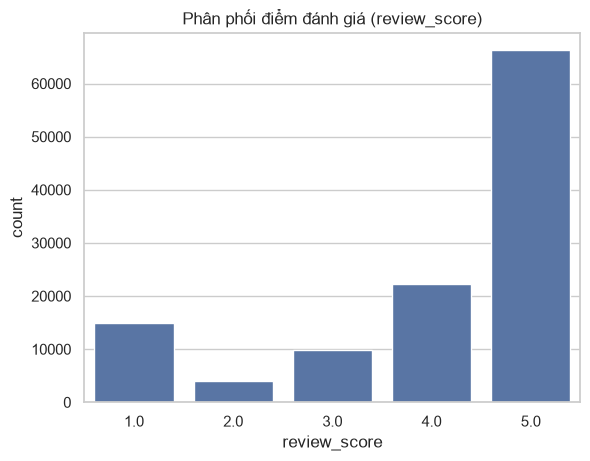

In [35]:
# Kiểm tra khả năng PHÂN LỚP: phân phối review_score (biến mục tiêu tiềm năng)
print(olist_df['review_score'].value_counts(dropna=False).sort_index())
sns.countplot(x='review_score', data=olist_df)
plt.title('Phân phối điểm đánh giá (review_score)')
plt.show()


In [36]:
# Kiểm tra khả năng LUẬT KẾT HỢP: số lượng ngành hàng (product_category_name_english) khác nhau
# trên mỗi đơn hàng -> xác nhận có tồn tại cấu trúc "giỏ hàng" đa mục hay không
basket_size = olist_df.groupby('order_id')['product_category_name_english'].nunique()
print(basket_size.describe())
print('Tỉ lệ đơn có từ 2 ngành hàng khác nhau trở lên: %.2f%%' % (
    (basket_size >= 2).mean() * 100
))


count    98666.000000
mean         0.993220
std          0.148523
min          0.000000
25%          1.000000
50%          1.000000
75%          1.000000
max          3.000000
Name: product_category_name_english, dtype: float64
Tỉ lệ đơn có từ 2 ngành hàng khác nhau trở lên: 0.74%


In [37]:
# Kiểm tra khả năng GOM CỤM: phân phối các đặc trưng số dùng cho RFM khách hàng
rfm_check = olist_df.groupby('customer_unique_id').agg(
    frequency=('order_id', 'nunique'),
    monetary=('payment_value', 'sum'),
)
rfm_check.describe()


,frequency,monetary
count,95420.000000,95420.000000
mean,1.034018,213.968167
std,0.211234,645.757464
min,1.000000,0.000000
25%,1.000000,63.990000
50%,1.000000,113.330000
75%,1.000000,203.300000
max,16.000000,109312.640000


## 1.4 Kỹ thuật đề xuất trên Bộ 1

**Lưu ý quan trọng (dựa trên kết quả kiểm chứng ở trên):** kết quả `basket_size` cho thấy phần lớn đơn hàng Olist chỉ chứa **1 ngành hàng/sản phẩm** — "giỏ hàng" thiếu đa dạng, không đủ cơ sở để khai phá luật kết hợp có ý nghĩa (Apriori/FP-Growth cần nhiều item/giao dịch để sinh luật đáng tin cậy). Vì vậy nhóm **chuyển Luật kết hợp sang Bộ 2 (Airbnb)** — nơi mỗi listing có nhiều tiện nghi (`amenities`) cùng lúc, phù hợp hơn nhiều cho bài toán này (xem Mục 2.4).

→ **Phân lớp** (dự đoán giao hàng trễ `is_late`) và **Gom cụm** (phân khúc khách hàng theo RFM).


In [38]:
missing_value_report(olist_df, threshold=0)


,ti_le_thieu_%
order_delivered_customer_date,2.19
product_category_name_english,1.47
product_name_lenght,1.44
product_description_lenght,1.44
product_photos_qty,1.44
product_category_name,1.44
order_delivered_carrier_date,1.06
review_score,0.83
product_weight_g,0.02
product_height_cm,0.02


### Quyết định xử lý giá trị thiếu – Olist

- `order_delivered_customer_date` và `order_delivered_carrier_date` bị thiếu chủ yếu do đơn hàng chưa hoàn tất hoặc chưa có thông tin giao hàng tương ứng. Không điền ngày giả vì có thể làm sai thời gian giao hàng.
- `review_score` bị thiếu do một số đơn chưa có đánh giá. Không thay thế bằng giá trị trung bình vì sẽ tạo ra đánh giá giả.
- Các thuộc tính sản phẩm bị thiếu ở mức khoảng 1,44% do thông tin sản phẩm không đầy đủ. Với các bài kỹ thuật, việc imputation sẽ thực hiện trong pipeline riêng của từng bài.
- Các giá trị âm ở `price`, `freight_value`, `payment_value`, `product_weight_g` được kiểm tra; không phát hiện giá trị âm trong dữ liệu thực tế.
- Duplicate toàn dòng được xác nhận là dư thừa và được loại bỏ.

### 1.5.2 Nhiễu và ngoại lai

Nhóm sử dụng kết hợp thống kê mô tả, IQR và kiểm tra theo ràng buộc
nghiệp vụ để phát hiện giá trị bất thường trên các thuộc tính số như
`price`, `freight_value`, `payment_value` và `product_weight_g`.

Các giá trị âm của `price`, `freight_value`, `payment_value` và
`product_weight_g` được xem là không hợp lệ theo ý nghĩa nghiệp vụ.
Các giá trị này được chuyển thành `NaN` thay vì giữ nguyên hoặc tự động
thay bằng 0, để tránh tạo ra giá trị giả.

Đối với các giá trị cực lớn được phát hiện bằng IQR, nhóm không loại bỏ
máy móc vì giá sản phẩm, phí vận chuyển hoặc trọng lượng có thể thực sự
có phân phối lệch phải và có các giá trị cao hợp lệ.

Do đó, các giá trị cực đoan nhưng hợp lệ được giữ lại. Việc scaling,
log-transform hoặc xử lý ảnh hưởng của outlier sẽ được quyết định ở
Bài 2 và Bài 4 tùy theo thuật toán sử dụng.

Ngoài ra, nhóm kiểm tra tính hợp lệ của `review_score` và các mốc thời
gian giao hàng để phát hiện các giá trị vi phạm tri thức lĩnh vực.

In [39]:
numeric_cols_olist = ['price', 'freight_value', 'payment_value', 'product_weight_g']
outlier_iqr_report(olist_df, numeric_cols_olist)


,thuoc_tinh,Q1,Q3,IQR,nguong_duoi,nguong_tren,so_ngoai_lai,ti_le_ngoai_lai_%
0,price,39.90,134.90,95.00,-102.600,277.400,8867,7.49
1,freight_value,13.08,21.18,8.10,0.930,33.330,12740,10.77
2,payment_value,60.85,189.26,128.41,-131.765,381.875,9549,8.07
3,product_weight_g,300.00,1800.00,1500.00,-1950.000,4050.000,16696,14.11


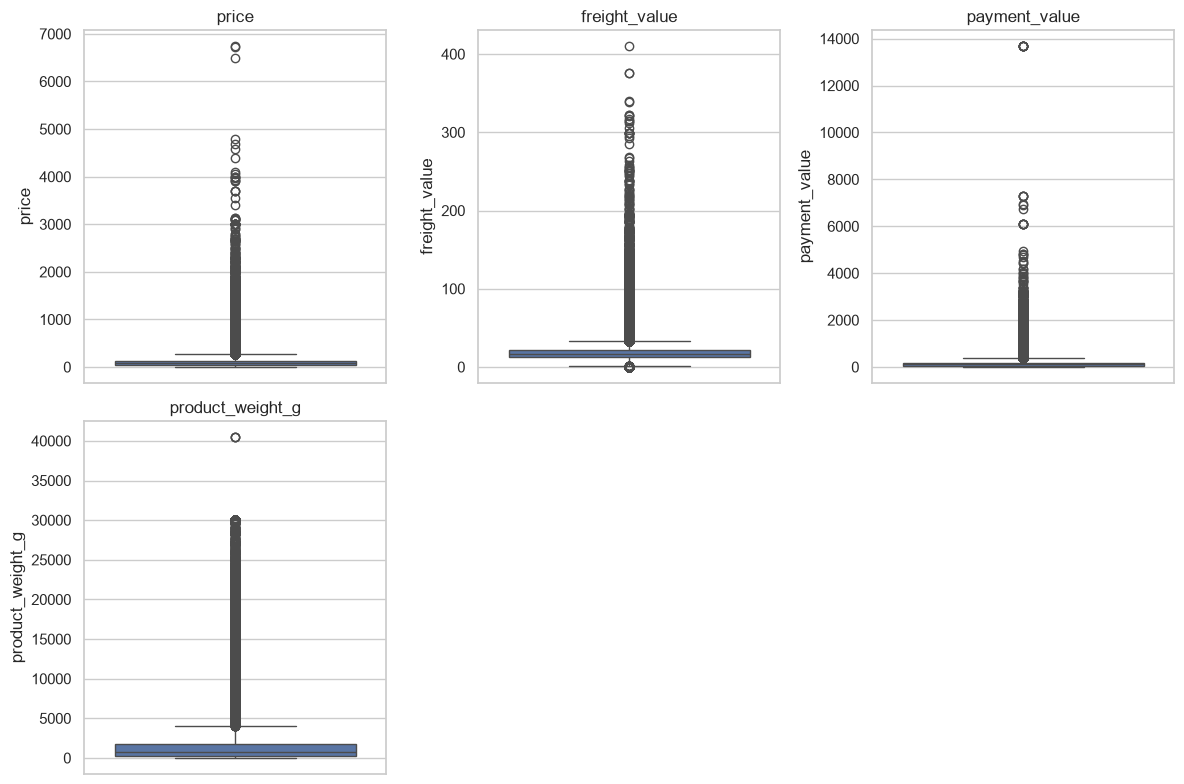

In [40]:
plot_boxplots(olist_df, numeric_cols_olist)


In [41]:
# Kiểm tra ràng buộc logic thời gian: ngày giao phải sau ngày đặt
orders['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'])
orders['order_delivered_customer_date'] = pd.to_datetime(orders['order_delivered_customer_date'])

logic_violation = orders[
    orders['order_delivered_customer_date'] < orders['order_purchase_timestamp']
]
print('Số đơn vi phạm ràng buộc logic thời gian (giao trước khi đặt):', len(logic_violation))


Số đơn vi phạm ràng buộc logic thời gian (giao trước khi đặt): 0


In [42]:
# ============================================================
# OLIST - KIỂM TRA CARDINALITY SAU JOIN
# Mục đích: phát hiện việc nhân dòng do quan hệ 1-N
# ============================================================

print("=== KIỂM TRA CARDINALITY OLIST ===")

print("Orders gốc:", orders['order_id'].nunique())
print("Order items:", order_items['order_id'].nunique())
print("Payments:", payments['order_id'].nunique())
print("Reviews:", reviews['order_id'].nunique())

print("\nSau JOIN:")
print("Số dòng:", len(olist_df))
print("Order duy nhất:", olist_df['order_id'].nunique())

payments_per_order = (
    payments.groupby('order_id')
    .size()
)

reviews_per_order = (
    reviews.groupby('order_id')
    .size()
)

items_per_order = (
    order_items.groupby('order_id')
    .size()
)

print("\nItems/order:")
print(items_per_order.describe())

print("\nPayments/order:")
print(payments_per_order.describe())

print("\nReviews/order:")
print(reviews_per_order.describe())

print(
    "\nOrder có >1 payment record:",
    (payments_per_order > 1).sum()
)

print(
    "Order có >1 review record:",
    (reviews_per_order > 1).sum()
)

=== KIỂM TRA CARDINALITY OLIST ===
Orders gốc: 99441
Order items: 98666
Payments: 99440
Reviews: 98673

Sau JOIN:
Số dòng: 118310
Order duy nhất: 98666

Items/order:
count    98666.000000
mean         1.141731
std          0.538452
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max         21.000000
dtype: float64

Payments/order:
count    99440.000000
mean         1.044710
std          0.381166
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max         29.000000
dtype: float64

Reviews/order:
count    98673.000000
mean         1.005584
std          0.075060
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max          3.000000
dtype: float64

Order có >1 payment record: 2961
Order có >1 review record: 547


### 1.5.3 Thêm / xóa / biến đổi thuộc tính

#### Xóa thuộc tính

Các mã định danh như `order_id` và `customer_id` không được sử dụng
trực tiếp làm biến đầu vào cho các thuật toán vì chúng chỉ có vai trò
nhận diện bản ghi. Nội dung review dạng văn bản tự do cũng không đưa
trực tiếp vào mô hình vì nhóm không thực hiện NLP.

Đối với dữ liệu dùng cho gom cụm, `customer_unique_id` được giữ lại ở
mức định danh để nhóm các giao dịch theo khách hàng nhưng không sử dụng
như một biến số đầu vào.

#### Thêm thuộc tính

- `delivery_delay_days`: số ngày chênh lệch giữa ngày giao thực tế và
  ngày giao dự kiến.
- `is_late`: biến nhị phân được tạo từ `delivery_delay_days`, dùng làm
  biến mục tiêu cho bài toán phân lớp.
- `order_item_count`: số sản phẩm trong một đơn.
- `unique_product_count`: số sản phẩm khác nhau trong đơn.
- `unique_seller_count`: số người bán khác nhau trong đơn.
- `total_order_price`: tổng giá trị sản phẩm trong đơn.
- `total_freight_value`: tổng phí vận chuyển trong đơn.
- Các đặc trưng RFM `recency_days`, `frequency`, `monetary` được tạo ở
  cấp khách hàng để phục vụ gom cụm.

#### Biến đổi

Các trường ngày giờ được chuyển sang kiểu datetime để có thể tính toán
thời gian.

Các biến hạng mục có thể được mã hóa ở Bài 2 khi cần. Các biến số sẽ
được scaling hoặc biến đổi phù hợp ở Bài 4 trước khi áp dụng thuật toán
gom cụm.

Do Olist không được chọn cho luật kết hợp trong ma trận cuối cùng,
không cần ép dữ liệu Olist thành transaction chỉ để đáp ứng kỹ thuật này.

In [43]:
# Thêm thuộc tính dẫn xuất: độ trễ giao hàng (ngày) -> dùng làm nhãn phân lớp dự phòng
orders['order_estimated_delivery_date'] = pd.to_datetime(orders['order_estimated_delivery_date'])
orders['delivery_delay_days'] = (
    orders['order_delivered_customer_date'] - orders['order_estimated_delivery_date']
).dt.days

orders['is_late'] = np.where(
    orders['order_delivered_customer_date'].notna(),
    orders['delivery_delay_days'] > 0,
    np.nan
)

orders['is_late'] = pd.Series(
    orders['is_late'],
    index=orders.index,
    dtype='boolean'
)

print(orders['is_late'].value_counts(dropna=False))


is_late
False    89941
True      6535
<NA>      2965
Name: count, dtype: Int64


In [44]:
# ============================================================
# OLIST - RFM ĐÚNG CẤP ORDER
# Không tính RFM trực tiếp trên bảng JOIN item/payment/review
# để tránh nhân payment_value.
# ============================================================

orders_rfm = orders.copy()
customers_rfm = customers.copy()
payments_rfm = payments.copy()

# Chuẩn hóa datetime
orders_rfm['order_purchase_timestamp'] = pd.to_datetime(
    orders_rfm['order_purchase_timestamp'],
    errors='coerce'
)

snapshot_date = orders_rfm['order_purchase_timestamp'].max()

# Tổng payment của từng order trước
payment_by_order = (
    payments_rfm
    .groupby('order_id', as_index=False)
    .agg(
        order_payment_value=('payment_value', 'sum')
    )
)

# Ghép customer
rfm_base = (
    orders_rfm[
        [
            'order_id',
            'customer_id',
            'order_purchase_timestamp'
        ]
    ]
    .merge(
        customers_rfm[
            ['customer_id', 'customer_unique_id']
        ],
        on='customer_id',
        how='left'
    )
    .merge(
        payment_by_order,
        on='order_id',
        how='left'
    )
)

# Tính RFM
rfm = (
    rfm_base
    .groupby('customer_unique_id')
    .agg(
        recency_days=(
            'order_purchase_timestamp',
            lambda x: (snapshot_date - x.max()).days
        ),
        frequency=(
            'order_id',
            'nunique'
        ),
        monetary=(
            'order_payment_value',
            'sum'
        )
    )
    .reset_index()
)

print("=== RFM OLIST ===")
print("Số khách hàng:", len(rfm))
print(rfm.describe())

=== RFM OLIST ===
Số khách hàng: 96096
       recency_days     frequency      monetary
count  96096.000000  96096.000000  96096.000000
mean     287.735691      1.034809    166.592492
std      153.414676      0.214384    231.428332
min        0.000000      1.000000      0.000000
25%      163.000000      1.000000     63.120000
50%      268.000000      1.000000    108.000000
75%      397.000000      1.000000    183.530000
max      772.000000     17.000000  13664.080000


In [45]:
# ============================================================
# OLIST - DATASET CHO PHÂN LỚP
# Target: is_late
# 1 = giao trễ, 0 = không giao trễ
# ============================================================

# Tạo feature cấp đơn hàng từ order_items
order_features_olist = (
    order_items
    .groupby('order_id')
    .agg(
        order_item_count=('order_item_id', 'count'),
        unique_product_count=('product_id', 'nunique'),
        unique_seller_count=('seller_id', 'nunique'),
        total_order_price=('price', 'sum'),
        total_freight_value=('freight_value', 'sum')
    )
    .reset_index()
)

# Các feature về thời điểm đặt hàng
olist_classification = orders[
    [
        'order_id',
        'order_purchase_timestamp',
        'is_late'
    ]
].copy()

olist_classification['order_purchase_timestamp'] = pd.to_datetime(
    olist_classification['order_purchase_timestamp'],
    errors='coerce'
)

olist_classification['purchase_month'] = (
    olist_classification['order_purchase_timestamp'].dt.month
)

olist_classification['purchase_dayofweek'] = (
    olist_classification['order_purchase_timestamp'].dt.dayofweek
)

olist_classification['purchase_hour'] = (
    olist_classification['order_purchase_timestamp'].dt.hour
)

# Merge feature đơn hàng
olist_classification = olist_classification.merge(
    order_features_olist,
    on='order_id',
    how='left'
)

# Chỉ giữ các dòng có target
olist_classification = olist_classification[
    olist_classification['is_late'].notna()
].copy()

print("=== OLIST CLASSIFICATION DATASET ===")
print("Shape:", olist_classification.shape)

print("\nTarget distribution:")
print(olist_classification['is_late'].value_counts())

print("\nTarget percentage:")
print(
    olist_classification['is_late']
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print("\nFeatures:")
print(olist_classification.columns.tolist())

olist_classification.head()

=== OLIST CLASSIFICATION DATASET ===
Shape: (96476, 11)

Target distribution:
is_late
False    89941
True      6535
Name: count, dtype: Int64

Target percentage:
is_late
False    93.23
True      6.77
Name: proportion, dtype: Float64

Features:
['order_id', 'order_purchase_timestamp', 'is_late', 'purchase_month', 'purchase_dayofweek', 'purchase_hour', 'order_item_count', 'unique_product_count', 'unique_seller_count', 'total_order_price', 'total_freight_value']


,order_id,order_purchase_timestamp,is_late,purchase_month,purchase_dayofweek,purchase_hour,order_item_count,unique_product_count,unique_seller_count,total_order_price,total_freight_value
0,e481f51cbdc54678b7cc49136f2d6af7,2017-10-02 10:56:33,False,10,0,10,1.0,1.0,1.0,29.99,8.72
1,53cdb2fc8bc7dce0b6741e2150273451,2018-07-24 20:41:37,False,7,1,20,1.0,1.0,1.0,118.70,22.76
2,47770eb9100c2d0c44946d9cf07ec65d,2018-08-08 08:38:49,False,8,2,8,1.0,1.0,1.0,159.90,19.22
3,949d5b44dbf5de918fe9c16f97b45f8a,2017-11-18 19:28:06,False,11,5,19,1.0,1.0,1.0,45.00,27.20
4,ad21c59c0840e6cb83a9ceb5573f8159,2018-02-13 21:18:39,False,2,1,21,1.0,1.0,1.0,19.90,8.72


In [46]:
# ============================================================
# OLIST - CLEANING THỰC SỰ
# ============================================================

olist_clean = olist_df.copy()

# ============================================================
# XỬ LÝ BẢN GHI TRÙNG LẶP
# ============================================================

duplicate_before = olist_clean.duplicated().sum()

print(
    "Duplicate trước khi xử lý:",
    duplicate_before
)

olist_clean = (
    olist_clean
    .drop_duplicates()
    .reset_index(drop=True)
)

duplicate_after = olist_clean.duplicated().sum()

print(
    "Duplicate sau khi xử lý:",
    duplicate_after
)

# ------------------------------------------------------------
# 1. Chuẩn hóa datetime
# ------------------------------------------------------------

olist_datetime_cols = [
    'shipping_limit_date',
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]

for col in olist_datetime_cols:
    if col in olist_clean.columns:
        olist_clean[col] = pd.to_datetime(
            olist_clean[col],
            errors='coerce'
        )


# ------------------------------------------------------------
# 2. Missing category
# ------------------------------------------------------------

for col in [
    'product_category_name',
    'product_category_name_english'
]:
    if col in olist_clean.columns:
        olist_clean[col] = (
            olist_clean[col]
            .fillna('unknown')
        )


# ------------------------------------------------------------
# 3. Kiểm tra giá trị âm không hợp lệ
# ------------------------------------------------------------

numeric_non_negative = [
    'price',
    'freight_value',
    'payment_value',
    'product_weight_g'
]

for col in numeric_non_negative:
    if col in olist_clean.columns:
        invalid = olist_clean[col] < 0
        print(
            f'{col}: {invalid.sum()} giá trị âm'
        )

        # Giá trị âm là không hợp lệ → chuyển thành NaN
        olist_clean.loc[invalid, col] = np.nan


# ------------------------------------------------------------
# 4. Không tự động xóa IQR outlier
# ------------------------------------------------------------
# Các giá trị lớn như giá sản phẩm/phí vận chuyển
# có thể là giá trị hợp lệ.
#
# Vì vậy giữ lại và xử lý scaling/transform ở Bài 2-4
# nếu thuật toán yêu cầu.


# ------------------------------------------------------------
# 5. Chuẩn hóa Boolean target
# ------------------------------------------------------------

if 'is_late' in olist_clean.columns:
    olist_clean['is_late'] = (
        olist_clean['is_late']
        .astype('boolean')
    )


print("=== OLIST CLEANING HOÀN TẤT ===")
print("Shape:", olist_clean.shape)

Duplicate trước khi xử lý: 419
Duplicate sau khi xử lý: 0
price: 0 giá trị âm
freight_value: 0 giá trị âm
payment_value: 0 giá trị âm
product_weight_g: 0 giá trị âm
=== OLIST CLEANING HOÀN TẤT ===
Shape: (117891, 35)


In [47]:
# ============================================================
# OLIST - VALIDATION SAU CLEANING
# ============================================================

print("=== OLIST AFTER CLEANING ===")

print("Shape:", olist_clean.shape)

print(
    "Duplicate rows:",
    olist_clean.duplicated().sum()
)

# ============================================================
# KIỂM TRA NGUYÊN NHÂN DUPLICATE
# ============================================================

duplicate_rows = olist_clean[
    olist_clean.duplicated(
        keep=False
    )
].copy()

print(
    "\nSố dòng thuộc nhóm duplicate:",
    len(duplicate_rows)
)

print(
    "\nSố nhóm duplicate theo order_id:",
    duplicate_rows['order_id'].nunique()
)

print("\nMột số duplicate đầu tiên:")

print(
    duplicate_rows[
        [
            'order_id',
            'order_item_id',
            'product_id',
            'seller_id',
            'price',
            'freight_value'
        ]
    ]
    .sort_values(
        [
            'order_id',
            'order_item_id'
        ]
    )
    .head(30)
)

print(
    "\nMissing percentage:"
)

print(
    olist_clean.isna()
    .mean()
    .mul(100)
    .sort_values(ascending=False)
    .head(15)
    .round(2)
)

print("\nNegative values:")

for col in [
    'price',
    'freight_value',
    'payment_value',
    'product_weight_g'
]:
    if col in olist_clean.columns:
        print(
            col,
            (olist_clean[col] < 0).sum()
        )

=== OLIST AFTER CLEANING ===
Shape: (117891, 35)
Duplicate rows: 0

Số dòng thuộc nhóm duplicate: 0

Số nhóm duplicate theo order_id: 0

Một số duplicate đầu tiên:
Empty DataFrame
Columns: [order_id, order_item_id, product_id, seller_id, price, freight_value]
Index: []

Missing percentage:
order_delivered_customer_date    2.19
product_photos_qty               1.44
product_description_lenght       1.44
product_name_lenght              1.44
order_delivered_carrier_date     1.06
review_score                     0.83
product_height_cm                0.02
product_weight_g                 0.02
product_width_cm                 0.02
product_length_cm                0.02
order_approved_at                0.01
payment_installments             0.00
payment_type                     0.00
payment_sequential               0.00
payment_value                    0.00
dtype: float64

Negative values:
price 0
freight_value 0
payment_value 0
product_weight_g 0


In [48]:
# ============================================================
# OLIST - DATASET CHO GOM CỤM
# Đơn vị: khách hàng
# ============================================================

olist_clustering = rfm.copy()

# Chỉ giữ biến số dùng cho clustering
olist_clustering = olist_clustering[
    [
        'customer_unique_id',
        'recency_days',
        'frequency',
        'monetary'
    ]
].copy()

print("=== OLIST CLUSTERING ===")
print(olist_clustering.shape)
print(olist_clustering.isna().sum())
print(olist_clustering.describe())

=== OLIST CLUSTERING ===
(96096, 4)
customer_unique_id    0
recency_days          0
frequency             0
monetary              0
dtype: int64
       recency_days     frequency      monetary
count  96096.000000  96096.000000  96096.000000
mean     287.735691      1.034809    166.592492
std      153.414676      0.214384    231.428332
min        0.000000      1.000000      0.000000
25%      163.000000      1.000000     63.120000
50%      268.000000      1.000000    108.000000
75%      397.000000      1.000000    183.530000
max      772.000000     17.000000  13664.080000


In [49]:
# ============================================================
# 2. KIỂM TRA NGOẠI LAI / GIÁ TRỊ KHÔNG HỢP LỆ
# ============================================================

print("=== KIỂM TRA NGOẠI LAI OLIST ===")

# Giá sản phẩm
if 'price' in olist_clean.columns:
    print("\nPrice:")
    print(olist_clean['price'].describe())

    print(
        "Số price <= 0:",
        (olist_clean['price'] <= 0).sum()
    )

# Phí vận chuyển
if 'freight_value' in olist_clean.columns:
    print("\nFreight value:")
    print(olist_clean['freight_value'].describe())

    print(
        "Số freight_value < 0:",
        (olist_clean['freight_value'] < 0).sum()
    )

# Điểm review
if 'review_score' in olist_clean.columns:
    print("\nReview score:")
    print(
        olist_clean['review_score']
        .value_counts(dropna=False)
        .sort_index()
    )

=== KIỂM TRA NGOẠI LAI OLIST ===

Price:
count    117891.000000
mean        120.743612
std         184.304122
min           0.850000
25%          39.900000
50%          74.900000
75%         134.900000
max        6735.000000
Name: price, dtype: float64
Số price <= 0: 0

Freight value:
count    117891.000000
mean         20.040986
std          15.850145
min           0.000000
25%          13.080000
50%          16.290000
75%          21.190000
max         409.680000
Name: freight_value, dtype: float64
Số freight_value < 0: 0

Review score:
review_score
1.0    14803
2.0     4082
3.0     9819
4.0    22238
5.0    65971
NaN      978
Name: count, dtype: int64


### Kiểm tra nhiễu và ngoại lai — Olist

Các thuộc tính số được kiểm tra bằng thống kê mô tả kết hợp với
ràng buộc nghiệp vụ.

- `price` không được nhỏ hơn hoặc bằng 0.
- `freight_value` không được âm.
- `review_score` phải nằm trong miền giá trị 1–5; giá trị thiếu được
  xử lý riêng vì có thể tương ứng với đơn hàng chưa có đánh giá.

Đối với các giá trị cực đoan nhưng vẫn hợp lệ về mặt nghiệp vụ,
không loại bỏ máy móc. Các giá trị bất thường chỉ được loại khi
vi phạm ràng buộc vật lý/nghiệp vụ hoặc làm sai lệch trực tiếp
kỹ thuật khai phá ở các bài sau.

In [50]:
# ============================================================
# 3. KIỂM TRA THUỘC TÍNH KHÔNG PHÙ HỢP
# ============================================================

print("=== CỘT GẦN NHƯ HẰNG SỐ ===")

nunique = olist_clean.nunique(dropna=False)

print(
    nunique[nunique <= 1]
)

print("\n=== CỘT ID / TEXT CẦN XEM XÉT ===")

candidate_drop = [
    c for c in [
        'order_id',
        'customer_id',
        'review_comment_message'
    ]
    if c in olist_clean.columns
]

print(candidate_drop)

=== CỘT GẦN NHƯ HẰNG SỐ ===
Series([], dtype: int64)

=== CỘT ID / TEXT CẦN XEM XÉT ===
['order_id', 'customer_id']


### Xóa thuộc tính — Olist

Một số thuộc tính không được đưa trực tiếp vào các mô hình khai phá:

- Các mã định danh thô như `order_id`, `customer_id` không mang
  thông tin số học có ý nghĩa cho khoảng cách hoặc phân lớp.
- Các thuộc tính văn bản tự do như nội dung review không được sử dụng
  vì nhóm không thực hiện NLP trong phạm vi bài này.
- Các thuộc tính gần như hằng số sẽ được loại bỏ nếu kiểm tra dữ liệu
  thực tế cho thấy không có khả năng phân biệt các bản ghi.
- Các biến được sử dụng làm nhãn không được đưa trở lại làm biến đầu
  vào để tránh rò rỉ nhãn.

Riêng `customer_unique_id` vẫn được giữ ở dataset phục vụ RFM/gom
cụm vì nó cần thiết để nhóm các đơn hàng theo cùng một khách hàng.

In [51]:
# ============================================================
# LƯU DỮ LIỆU ĐÃ TIỀN XỬ LÝ - OLIST
# ============================================================

import os

os.makedirs(f'{PROCESSED_DIR}/olist', exist_ok=True)

# Dữ liệu phân tích tổng hợp
olist_clean.to_csv(
    f'{PROCESSED_DIR}/olist/olist_preprocessed.csv',
    index=False
)

# Dữ liệu RFM cho Gom cụm
rfm.to_csv(
    f'{PROCESSED_DIR}/olist/olist_customer_rfm.csv',
    index=False
)

# Dữ liệu chính thức cho Gom cụm
olist_clustering.to_csv(
    f'{PROCESSED_DIR}/olist/olist_clustering.csv',
    index=False
)

# Dữ liệu Classification
olist_classification.to_csv(
    f'{PROCESSED_DIR}/olist/olist_classification.csv',
    index=False
)

print('Đã lưu dữ liệu Olist:')
print('- olist_preprocessed.csv')
print('- olist_customer_rfm.csv')
print('- olist_classification.csv')
print('- olist_clustering.csv')

Đã lưu dữ liệu Olist:
- olist_preprocessed.csv
- olist_customer_rfm.csv
- olist_classification.csv
- olist_clustering.csv


---
# BỘ 2: Inside Airbnb — Detailed Listings

**Nguồn:** http://insideairbnb.com/get-the-data/ (New York City, mục "Detailed Listings data", file `listings.csv`)
**Đơn vị công bố:** Inside Airbnb (dự án phi lợi nhuận, dữ liệu scrape công khai từ Airbnb)
**Ngày tải:** ......... *(nhóm điền ngày thực tế tải file listings.csv)*
**Giấy phép:** Creative Commons Attribution 4.0 International (CC BY 4.0) — Murray Cox/Inside Airbnb đã waive toàn bộ quyền tác giả trong phạm vi pháp luật cho phép (nguồn: https://insideairbnb.com/get-the-data/). Dữ liệu là thông tin listing công khai do chính Airbnb hiển thị, không phải dữ liệu cá nhân bị lộ.
**Quy mô thực tế (xem Mục 2.1):** 30.259 listing × 87 thuộc tính sau khi tải — vượt ngưỡng tối thiểu 10.000 bản ghi × 30 thuộc tính của đề bài.

## 2.1 Tải dữ liệu


In [52]:
airbnb_path = f'{RAW_DIR}/airbnb/listings.csv'
airbnb_df = pd.read_csv(airbnb_path)
print('Kích thước:', airbnb_df.shape)
airbnb_df.head()


FileNotFoundError: [Errno 2] No such file or directory: 'c:\\Users\\Chien\\data_mining_project\\data\\raw/airbnb/listings.csv'

In [ ]:
# ---- Ô CHẨN ĐOÁN: kiểm tra file có đúng bản 'detailed listings' không ----
print('Số dòng x số cột:', airbnb_df.shape)
print('Danh sách cột:')
print(airbnb_df.columns.tolist())

REQUIRED_COLS = ['host_is_superhost', 'amenities', 'price', 'room_type', 'accommodates']
missing_required = [c for c in REQUIRED_COLS if c not in airbnb_df.columns]
if missing_required:
    print()
    print('⚠️  CẢNH BÁO: thiếu các cột bắt buộc:', missing_required)
    print('    -> Nhiều khả năng bạn đang dùng file "listings_summary.csv" (bản rút gọn ~18 cột)')
    print('    -> Cần tải lại đúng file "listings.csv" (bản DETAILED, ~74 cột) tại:')
    print('       http://insideairbnb.com/get-the-data/ -> mục "Detailed Listings data"')
else:
    print()
    print('✅ Đủ các cột bắt buộc để chạy các bước tiếp theo.')


Số dòng x số cột: (30259, 90)
Danh sách cột:
['id', 'listing_url', 'scrape_id', 'last_scraped', 'source', 'name', 'description', 'neighborhood_overview', 'picture_url', 'host_id', 'host_url', 'host_profile_id', 'host_profile_url', 'host_name', 'host_since', 'hosts_time_as_user_years', 'hosts_time_as_user_months', 'hosts_time_as_host_years', 'hosts_time_as_host_months', 'host_location', 'host_about', 'host_response_time', 'host_response_rate', 'host_acceptance_rate', 'host_is_superhost', 'host_thumbnail_url', 'host_picture_url', 'host_neighbourhood', 'host_listings_count', 'host_total_listings_count', 'host_verifications', 'host_has_profile_pic', 'host_identity_verified', 'neighbourhood', 'neighbourhood_cleansed', 'neighbourhood_group_cleansed', 'latitude', 'longitude', 'property_type', 'room_type', 'accommodates', 'bathrooms', 'bathrooms_text', 'bedrooms', 'beds', 'amenities', 'price', 'price_quote_checkin_date', 'price_quote_checkout_date', 'price_quote_total_price', 'price_quote_pric

## 2.2 Từ điển dữ liệu (tự động sinh)

In [ ]:
# ============================================================
# AIRBNB NYC - DATA DICTIONARY HOÀN CHỈNH
# ============================================================

airbnb_meaning = {

    "id": "Mã định danh của listing",

    "listing_url": "Địa chỉ trang listing trên Airbnb",

    "scrape_id": "Mã của lần thu thập dữ liệu",

    "last_scraped": "Ngày dữ liệu listing được thu thập gần nhất",

    "source": "Nguồn hoặc phương thức thu thập dữ liệu",

    "name": "Tên listing",

    "description": "Mô tả listing",

    "neighborhood_overview": "Mô tả tổng quan khu vực xung quanh listing",

    "picture_url": "Địa chỉ hình ảnh đại diện của listing",

    "host_id": "Mã định danh của host",

    "host_url": "Địa chỉ trang hồ sơ host",

    "host_profile_id": "Mã hồ sơ của host",

    "host_profile_url": "Địa chỉ trang hồ sơ chi tiết của host",

    "host_name": "Tên host",

    "host_since": "Ngày host bắt đầu tham gia nền tảng",

    "hosts_time_as_user_years": "Số năm host đã sử dụng nền tảng với tư cách người dùng",

    "hosts_time_as_user_months": "Số tháng host đã sử dụng nền tảng với tư cách người dùng",

    "hosts_time_as_host_years": "Số năm host hoạt động với tư cách chủ nhà",

    "hosts_time_as_host_months": "Số tháng host hoạt động với tư cách chủ nhà",

    "host_location": "Địa điểm của host",

    "host_about": "Thông tin giới thiệu về host",

    "host_response_time": "Khoảng thời gian host thường phản hồi",

    "host_response_rate": "Tỷ lệ phản hồi của host",

    "host_acceptance_rate": "Tỷ lệ chấp nhận yêu cầu đặt phòng của host",

    "host_is_superhost": "Cho biết host có đạt trạng thái Superhost hay không",

    "host_thumbnail_url": "Địa chỉ ảnh thu nhỏ của host",

    "host_picture_url": "Địa chỉ ảnh hồ sơ của host",

    "host_neighbourhood": "Khu vực của host",

    "host_listings_count": "Số listing của host",

    "host_total_listings_count": "Tổng số listing mà host quản lý",

    "host_verifications": "Các phương thức xác minh của host",

    "host_has_profile_pic": "Cho biết host có ảnh hồ sơ hay không",

    "host_identity_verified": "Cho biết danh tính host đã được xác minh hay chưa",

    "neighbourhood": "Khu vực của listing",

    "neighbourhood_cleansed": "Khu vực đã được chuẩn hóa của listing",

    "neighbourhood_group_cleansed": "Nhóm khu vực lớn đã được chuẩn hóa",

    "latitude": "Vĩ độ của listing",

    "longitude": "Kinh độ của listing",

    "property_type": "Loại hình bất động sản",

    "room_type": "Loại hình phòng",

    "accommodates": "Số lượng khách tối đa có thể lưu trú",

    "bathrooms": "Số lượng phòng tắm",

    "bathrooms_text": "Mô tả dạng văn bản về số lượng phòng tắm",

    "bedrooms": "Số lượng phòng ngủ",

    "beds": "Số lượng giường",

    "amenities": "Danh sách các tiện nghi của listing",

    "price": "Giá thuê listing mỗi đêm",

    "price_quote_checkin_date": "Ngày bắt đầu của báo giá",

    "price_quote_checkout_date": "Ngày kết thúc của báo giá",

    "price_quote_total_price": "Tổng giá trị báo giá",

    "price_quote_price_per_night": "Giá báo giá trung bình mỗi đêm",

    "price_quote_raw": "Thông tin báo giá ở dạng dữ liệu gốc",

    "minimum_nights": "Số đêm tối thiểu phải đặt",

    "maximum_nights": "Số đêm tối đa được phép đặt",

    "minimum_minimum_nights": "Giá trị nhỏ nhất của số đêm tối thiểu",

    "maximum_minimum_nights": "Giá trị lớn nhất của số đêm tối thiểu",

    "minimum_maximum_nights": "Giá trị nhỏ nhất của số đêm tối đa",

    "maximum_maximum_nights": "Giá trị lớn nhất của số đêm tối đa",

    "minimum_nights_avg_ntm": "Trung bình số đêm tối thiểu trong các tháng tiếp theo",

    "maximum_nights_avg_ntm": "Trung bình số đêm tối đa trong các tháng tiếp theo",

    "calendar_updated": "Thời điểm cập nhật lịch",

    "has_availability": "Cho biết listing có thông tin availability hay không",

    "availability_30": "Số ngày có thể đặt trong 30 ngày",

    "availability_60": "Số ngày có thể đặt trong 60 ngày",

    "availability_90": "Số ngày có thể đặt trong 90 ngày",

    "availability_365": "Số ngày có thể đặt trong 365 ngày",

    "calendar_last_scraped": "Ngày lịch được thu thập gần nhất",

    "number_of_reviews": "Tổng số lượt đánh giá",

    "number_of_reviews_ltm": "Số lượt đánh giá trong 12 tháng gần nhất",

    "number_of_reviews_l30d": "Số lượt đánh giá trong 30 ngày gần nhất",

    "availability_eoy": "Số ngày còn khả dụng đến cuối năm",

    "number_of_reviews_ly": "Số lượt đánh giá trong năm trước",

    "estimated_occupancy_l365d": "Tỷ lệ lấp đầy ước tính trong 365 ngày",

    "estimated_revenue_l365d": "Doanh thu ước tính trong 365 ngày",

    "first_review": "Ngày có đánh giá đầu tiên",

    "last_review": "Ngày có đánh giá gần nhất",

    "review_scores_rating": "Điểm đánh giá tổng thể",

    "review_scores_accuracy": "Điểm đánh giá độ chính xác của listing",

    "review_scores_cleanliness": "Điểm đánh giá độ sạch sẽ",

    "review_scores_checkin": "Điểm đánh giá quá trình check-in",

    "review_scores_communication": "Điểm đánh giá khả năng giao tiếp của host",

    "review_scores_location": "Điểm đánh giá vị trí",

    "review_scores_value": "Điểm đánh giá tương quan giá trị và chi phí",

    "license": "Thông tin giấy phép hoặc đăng ký của listing",

    "instant_bookable": "Cho biết listing có hỗ trợ đặt ngay hay không",

    "calculated_host_listings_count": "Tổng số listing được tính cho host",

    "calculated_host_listings_count_entire_homes": "Số listing dạng toàn bộ căn hộ/nhà của host",

    "calculated_host_listings_count_private_rooms": "Số listing dạng phòng riêng của host",

    "calculated_host_listings_count_shared_rooms": "Số listing dạng phòng chung của host",

    "reviews_per_month": "Số lượt đánh giá trung bình mỗi tháng"
}


airbnb_scale = {

    # ID / URL / thông tin định danh
    "id": "Định danh",
    "listing_url": "Định danh",
    "scrape_id": "Định danh",
    "last_scraped": "Khoảng",
    "source": "Định danh",
    "name": "Định danh",
    "description": "Định danh",
    "neighborhood_overview": "Định danh",
    "picture_url": "Định danh",

    "host_id": "Định danh",
    "host_url": "Định danh",
    "host_profile_id": "Định danh",
    "host_profile_url": "Định danh",
    "host_name": "Định danh",

    "host_since": "Khoảng",
    "hosts_time_as_user_years": "Tỉ lệ",
    "hosts_time_as_user_months": "Tỉ lệ",
    "hosts_time_as_host_years": "Tỉ lệ",
    "hosts_time_as_host_months": "Tỉ lệ",

    "host_location": "Định danh",
    "host_about": "Định danh",
    "host_response_time": "Thứ tự",
    "host_response_rate": "Tỉ lệ",
    "host_acceptance_rate": "Tỉ lệ",

    "host_is_superhost": "Định danh",

    "host_thumbnail_url": "Định danh",
    "host_picture_url": "Định danh",
    "host_neighbourhood": "Định danh",

    "host_listings_count": "Tỉ lệ",
    "host_total_listings_count": "Tỉ lệ",

    "host_verifications": "Định danh",
    "host_has_profile_pic": "Định danh",
    "host_identity_verified": "Định danh",

    "neighbourhood": "Định danh",
    "neighbourhood_cleansed": "Định danh",
    "neighbourhood_group_cleansed": "Định danh",

    # tọa độ
    "latitude": "Khoảng",
    "longitude": "Khoảng",

    "property_type": "Định danh",
    "room_type": "Định danh",

    "accommodates": "Tỉ lệ",
    "bathrooms": "Tỉ lệ",
    "bathrooms_text": "Định danh",
    "bedrooms": "Tỉ lệ",
    "beds": "Tỉ lệ",

    "amenities": "Định danh",

    "price": "Tỉ lệ",

    "price_quote_checkin_date": "Khoảng",
    "price_quote_checkout_date": "Khoảng",
    "price_quote_total_price": "Tỉ lệ",
    "price_quote_price_per_night": "Tỉ lệ",
    "price_quote_raw": "Định danh",

    "minimum_nights": "Tỉ lệ",
    "maximum_nights": "Tỉ lệ",
    "minimum_minimum_nights": "Tỉ lệ",
    "maximum_minimum_nights": "Tỉ lệ",
    "minimum_maximum_nights": "Tỉ lệ",
    "maximum_maximum_nights": "Tỉ lệ",
    "minimum_nights_avg_ntm": "Tỉ lệ",
    "maximum_nights_avg_ntm": "Tỉ lệ",

    "calendar_updated": "Khoảng",
    "has_availability": "Định danh",

    "availability_30": "Tỉ lệ",
    "availability_60": "Tỉ lệ",
    "availability_90": "Tỉ lệ",
    "availability_365": "Tỉ lệ",

    "calendar_last_scraped": "Khoảng",

    "number_of_reviews": "Tỉ lệ",
    "number_of_reviews_ltm": "Tỉ lệ",
    "number_of_reviews_l30d": "Tỉ lệ",
    "availability_eoy": "Tỉ lệ",
    "number_of_reviews_ly": "Tỉ lệ",

    "estimated_occupancy_l365d": "Tỉ lệ",
    "estimated_revenue_l365d": "Tỉ lệ",

    "first_review": "Khoảng",
    "last_review": "Khoảng",

    "review_scores_rating": "Khoảng",
    "review_scores_accuracy": "Khoảng",
    "review_scores_cleanliness": "Khoảng",
    "review_scores_checkin": "Khoảng",
    "review_scores_communication": "Khoảng",
    "review_scores_location": "Khoảng",
    "review_scores_value": "Khoảng",

    "license": "Định danh",
    "instant_bookable": "Định danh",

    "calculated_host_listings_count": "Tỉ lệ",
    "calculated_host_listings_count_entire_homes": "Tỉ lệ",
    "calculated_host_listings_count_private_rooms": "Tỉ lệ",
    "calculated_host_listings_count_shared_rooms": "Tỉ lệ",

    "reviews_per_month": "Tỉ lệ"
}


airbnb_dict = add_metadata_to_dictionary(
    airbnb_df,
    data_dictionary(airbnb_df),
    airbnb_meaning,
    airbnb_scale
)

airbnb_dict

Số thuộc tính: 90
Thiếu Ý nghĩa: 0
Thiếu Thang đo: 0


,thuoc_tinh,kieu_du_lieu,so_gia_tri_duy_nhat,ti_le_thieu_%,gia_tri_min,gia_tri_max,vi_du,Ý nghĩa,Thang đo
0,id,int64,30259,0.00,2.539000e+03,1.707075e+18,2539,Mã định danh của listing,Định danh
1,listing_url,str,30259,0.00,NaN,NaN,https://www.airbnb.com/rooms/2539,Địa chỉ trang listing trên Airbnb,Định danh
2,scrape_id,int64,1,0.00,2.026061e+13,2.026061e+13,20260614073253,Mã của lần thu thập dữ liệu,Định danh
3,last_scraped,str,4,0.00,NaN,NaN,2026-06-15,Ngày dữ liệu listing được thu thập gần nhất,Khoảng
4,source,str,2,0.00,NaN,NaN,city scrape,Nguồn hoặc phương thức thu thập dữ liệu,Định danh
...,...,...,...,...,...,...,...,...,...
85,calculated_host_listings_count,int64,70,0.00,1.000000e+00,9.550000e+02,5,Tổng số listing được tính cho host,Tỉ lệ
86,calculated_host_listings_count_entire_homes,int64,52,0.00,0.000000e+00,9.550000e+02,0,Số listing dạng toàn bộ căn hộ/nhà của host,Tỉ lệ
87,calculated_host_listings_count_private_rooms,int64,40,0.00,0.000000e+00,2.310000e+02,5,Số listing dạng phòng riêng của host,Tỉ lệ
88,calculated_host_listings_count_shared_rooms,int64,10,0.00,0.000000e+00,2.200000e+01,0,Số listing dạng phòng chung của host,Tỉ lệ


## 2.3 Điều tra tri thức lĩnh vực & lập luận khả năng khai phá

### Điều tra tri thức lĩnh vực — Airbnb NYC

Inside Airbnb là dữ liệu snapshot về thị trường cho thuê lưu trú ngắn
hạn tại New York City. Mỗi dòng đại diện cho một listing và chứa thông
tin về host, vị trí, loại phòng, sức chứa, giá, đánh giá, mức độ hoạt động
và các tiện nghi.

Giá của một listing có thể liên hệ với vị trí, loại phòng, sức chứa,
số phòng ngủ, số lượng tiện nghi và uy tín của host. Các thuộc tính như
`host_is_superhost`, `review_scores_rating` và số lượng review cung cấp
thông tin về mức độ hoạt động và chất lượng được đánh giá của listing.

Đặc biệt, `amenities` chứa nhiều tiện nghi cùng lúc trên một listing.
Vì vậy mỗi listing có thể được biểu diễn như một transaction gồm nhiều
item, rất phù hợp để khai phá luật kết hợp giữa các tiện nghi.

Các listing cũng có thể được biểu diễn bằng các đặc trưng về giá, sức
chứa, đánh giá, availability và số lượng tiện nghi để gom thành các
phân khúc lưu trú tương đồng.

**Kết luận:** Airbnb NYC phù hợp với Luật kết hợp và Gom cụm.
Phân lớp Superhost được chuẩn bị như phương án dự phòng nhưng không nằm
trong ma trận kỹ thuật chính thức.

In [ ]:
# Làm sạch sơ bộ cột price để kiểm chứng (chỉ phục vụ khảo sát nhanh)
airbnb_df['price_num'] = (
    airbnb_df['price'].astype(str).str.replace('[$,]', '', regex=True).astype(float)
)

# Kiểm tra khả năng PHÂN LỚP: phân phối host_is_superhost
if 'host_is_superhost' in airbnb_df.columns:
    print(airbnb_df['host_is_superhost'].value_counts(dropna=False))
else:
    print("⚠️ Không tìm thấy cột 'host_is_superhost' — kiểm tra lại ô chẩn đoán phía trên."
          " Có thể tạm dùng biến mục tiêu khác, ví dụ phân khúc giá (price_num).")


host_is_superhost
f      22814
t       7096
NaN      349
Name: count, dtype: int64


In [ ]:
# Kiểm tra khả năng LUẬT KẾT HỢP: số tiện nghi trung bình mỗi listing (amenities dạng chuỗi JSON-like)
import ast

def parse_amenities(x):
    try:
        return ast.literal_eval(x) if isinstance(x, str) else []
    except Exception:
        return []

if 'amenities' in airbnb_df.columns:
    airbnb_df['amenities_list'] = airbnb_df['amenities'].apply(parse_amenities)
    airbnb_df['amenity_count'] = airbnb_df['amenities_list'].apply(len)
    print(airbnb_df['amenity_count'].describe())
else:
    print("⚠️ Không tìm thấy cột 'amenities' — kiểm tra lại ô chẩn đoán phía trên.")


count    30259.000000
mean        28.507254
std         14.969106
min          0.000000
25%         16.000000
50%         28.000000
75%         39.000000
max        104.000000
Name: amenity_count, dtype: float64


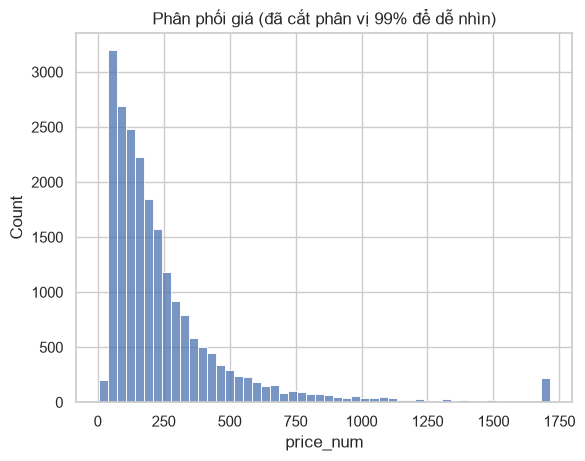

In [ ]:
# Kiểm tra khả năng GOM CỤM: phân phối các đặc trưng số chính
sns.histplot(airbnb_df['price_num'].clip(upper=airbnb_df['price_num'].quantile(0.99)), bins=50)
plt.title('Phân phối giá (đã cắt phân vị 99% để dễ nhìn)')
plt.show()


## 2.4 Kỹ thuật đề xuất trên Bộ 2

**Lý do chọn Luật kết hợp cho bộ này:** mỗi listing có nhiều tiện nghi cùng lúc trong `amenities` (thường vài chục tiện nghi/listing) — "giỏ tiện nghi" tự nhiên, giàu hơn nhiều so với "giỏ hàng" Olist (đa số 1 sản phẩm/đơn) — phù hợp hơn cho Apriori/FP-Growth.

→ **Luật kết hợp** (tiện nghi nào hay đi cùng nhau trong `amenities`) và **Gom cụm** (phân khúc thị trường lưu trú).
*(Phân lớp Superhost/phân khúc giá — dataset đã chuẩn bị sẵn — để dành làm phương án dự phòng/mở rộng, không phải kỹ thuật chính thức nộp cho bộ này.)*

## 2.5 Điều tra tiền xử lý (Mục 3.3)

### 2.5.1 Giá trị thiếu


In [ ]:
missing_value_report(airbnb_df, threshold=0).head(20)


,ti_le_thieu_%
neighborhood_overview,100.00
host_neighbourhood,100.00
host_response_rate,100.00
host_acceptance_rate,100.00
host_since,100.00
host_response_time,100.00
host_thumbnail_url,100.00
host_verifications,100.00
instant_bookable,100.00
calendar_updated,100.00


### Quyết định xử lý giá trị thiếu – Airbnb

- 12 thuộc tính thiếu 100% thông tin được loại bỏ vì không cung cấp dữ liệu hữu ích.
- `license` thiếu khoảng 82,53% nên không dùng làm đặc trưng chính.
- `bedrooms`, `bathrooms`, `beds` có tỷ lệ thiếu cao nhưng vẫn có ý nghĩa nghiệp vụ nên giữ lại; việc imputation được thực hiện trong pipeline Gom cụm.
- `price` được chuyển thành `price_num`; giá không hợp lệ hoặc bằng 0 được chuyển thành missing.
- `reviews_per_month` được đặt bằng 0 khi listing có `number_of_reviews = 0`, vì trường hợp này thể hiện chưa có hoạt động review thay vì dữ liệu bị lỗi.

### 2.5.2 Nhiễu và ngoại lai

In [ ]:
numeric_cols_airbnb = ['price_num', 'minimum_nights', 'accommodates', 'bedrooms', 'beds']
outlier_iqr_report(airbnb_df, numeric_cols_airbnb)


,thuoc_tinh,Q1,Q3,IQR,nguong_duoi,nguong_tren,so_ngoai_lai,ti_le_ngoai_lai_%
0,price_num,96.875,302.72,205.845,-211.8925,611.4875,1608,7.47
1,minimum_nights,30.000,30.00,0.000,30.0000,30.0000,6455,21.33
2,accommodates,2.000,4.00,2.000,-1.0000,7.0000,1072,3.54
3,bedrooms,1.000,2.00,1.000,-0.5000,3.5000,707,3.67
4,beds,1.000,2.00,1.000,-0.5000,3.5000,1600,7.68


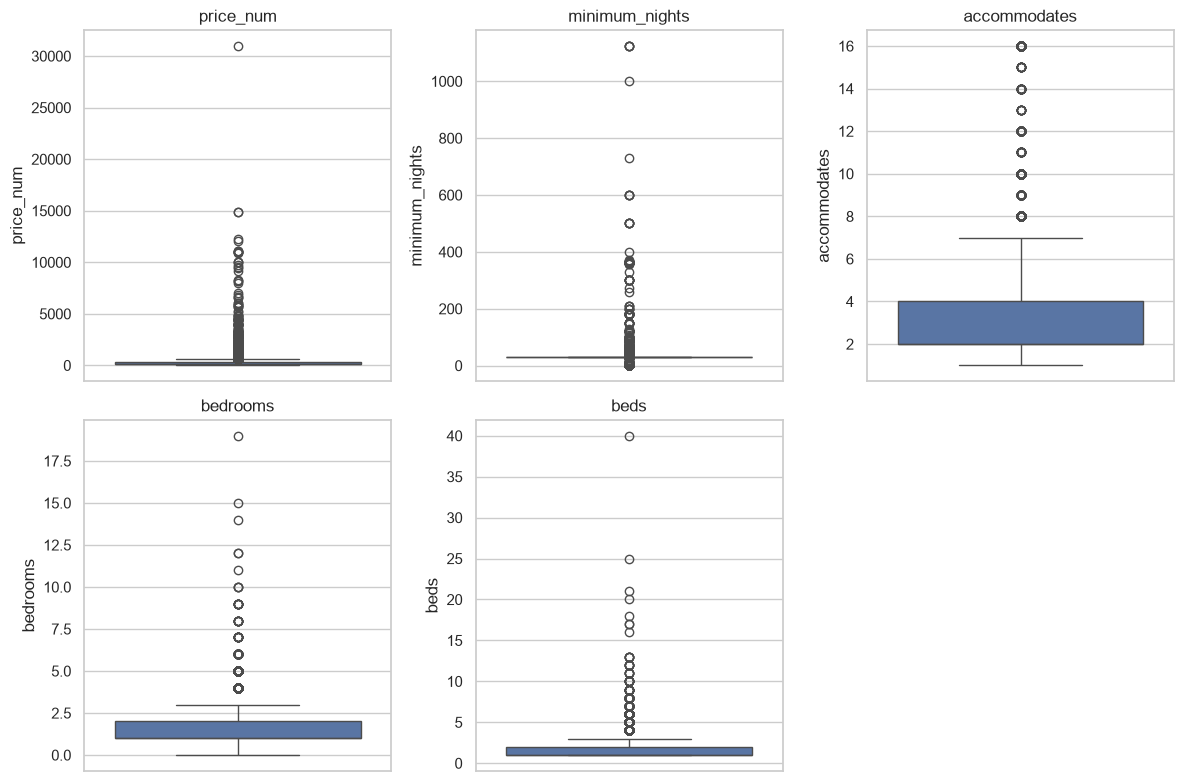

In [ ]:
plot_boxplots(airbnb_df, numeric_cols_airbnb)


In [ ]:
# ============================================================
# AIRBNB - CLEANING THỰC SỰ
# ============================================================

airbnb_clean = airbnb_df.copy()

# ============================================================
# XÓA CÁC CỘT ĐỊNH DANH CÁ NHÂN (PII) CỦA HOST
# ============================================================
# Đề bài yêu cầu dữ liệu "không chứa thông tin định danh cá nhân
# chưa ẩn danh". Các cột này chỉ mang tính tham chiếu/hiển thị (URL,
# tên, ảnh, tiểu sử tự thuật của host) và không dùng cho bất kỳ kỹ
# thuật khai phá nào -> xóa hẳn khỏi dataset thay vì chỉ "không dùng
# trực tiếp" như trước.

pii_cols = [
    'host_name', 'host_url', 'host_thumbnail_url',
    'host_picture_url', 'host_about',
    'listing_url', 'picture_url'
]
pii_cols = [c for c in pii_cols if c in airbnb_clean.columns]

print("Xóa cột định danh cá nhân (PII):", pii_cols)

airbnb_clean = airbnb_clean.drop(columns=pii_cols)

# ============================================================
# XÓA CÁC THUỘC TÍNH THIẾU 100%
# ============================================================

all_missing_cols = [
    col
    for col in airbnb_clean.columns
    if airbnb_clean[col].isna().all()
]

print(
    "Các cột thiếu 100%:",
    all_missing_cols
)

airbnb_clean = airbnb_clean.drop(
    columns=all_missing_cols
)

print(
    "Đã xóa:",
    len(all_missing_cols),
    "cột thiếu 100%"
)

# ============================================================
# 1. CHUẨN HÓA KIỂU DỮ LIỆU VÀ GIÁ
# ============================================================

airbnb_clean['price_num'] = (
    airbnb_clean['price']
    .astype(str)
    .str.replace('[$,]', '', regex=True)
)

airbnb_clean['price_num'] = pd.to_numeric(
    airbnb_clean['price_num'],
    errors='coerce'
)

# Giá phải > 0
invalid_price = airbnb_clean['price_num'] <= 0

print(
    "Số price <= 0:",
    invalid_price.sum()
)

airbnb_clean.loc[
    invalid_price,
    'price_num'
] = np.nan


# ============================================================
# 2. KIỂM TRA CÁC BIẾN ĐỊNH LƯỢNG KHÔNG HỢP LỆ
# ============================================================

for col in [
    'accommodates',
    'bedrooms',
    'beds',
    'minimum_nights'
]:

    if col not in airbnb_clean.columns:
        continue

    invalid = airbnb_clean[col] <= 0

    print(
        f"{col} <= 0:",
        invalid.sum()
    )

    airbnb_clean.loc[
        invalid,
        col
    ] = np.nan


# ============================================================
# 3. XỬ LÝ REVIEWS_PER_MONTH
# ============================================================

if (
    'number_of_reviews' in airbnb_clean.columns
    and
    'reviews_per_month' in airbnb_clean.columns
):

    no_review = (
        airbnb_clean['number_of_reviews']
        .fillna(0)
        == 0
    )

    airbnb_clean.loc[
        no_review,
        'reviews_per_month'
    ] = 0


# ============================================================
# 4. CHUẨN HÓA TARGET SUPERHOST
# ============================================================

airbnb_clean['target_superhost'] = (
    airbnb_clean['host_is_superhost']
    .map({
        't': 1,
        'f': 0,
        True: 1,
        False: 0
    })
)

print("\nPhân phối target:")
print(
    airbnb_clean['target_superhost']
    .value_counts(dropna=False)
)


# ============================================================
# 5. AMENITIES
# ============================================================

if 'amenities' in airbnb_clean.columns:

    airbnb_clean['amenities_list'] = (
        airbnb_clean['amenities']
        .apply(parse_amenities)
    )

    airbnb_clean['amenity_count'] = (
        airbnb_clean['amenities_list']
        .apply(len)
    )

    for amenity in [
        'Wifi',
        'Kitchen',
        'Air conditioning',
        'Pool'
    ]:

        col_name = (
            'has_' +
            amenity.lower().replace(' ', '_')
        )

        airbnb_clean[col_name] = (
            airbnb_clean['amenities_list']
            .apply(
                lambda x: amenity in x
            )
            .astype(int)
        )


# ============================================================
# 6. FEATURE ENGINEERING
# ============================================================

airbnb_clean['price_per_person'] = (
    airbnb_clean['price_num']
    /
    airbnb_clean['accommodates']
)


print("\n=== AIRBNB CLEANING HOÀN TẤT ===")
print("Shape:", airbnb_clean.shape)

Xóa cột định danh cá nhân (PII): ['host_name', 'host_url', 'host_thumbnail_url', 'host_picture_url', 'host_about', 'listing_url', 'picture_url']
Các cột thiếu 100%: ['neighborhood_overview', 'host_since', 'host_response_time', 'host_response_rate', 'host_acceptance_rate', 'host_neighbourhood', 'host_total_listings_count', 'host_verifications', 'neighbourhood', 'calendar_updated', 'instant_bookable']
Đã xóa: 11 cột thiếu 100%
Số price <= 0: 0
accommodates <= 0: 0
bedrooms <= 0: 15
beds <= 0: 0
minimum_nights <= 0: 0

Phân phối target:
target_superhost
0.0    22814
1.0     7096
NaN      349
Name: count, dtype: int64

=== AIRBNB CLEANING HOÀN TẤT ===
Shape: (30259, 81)


### Quyết định thêm / xóa / biến đổi thuộc tính — Airbnb

#### Xóa thuộc tính

- Các cột thiếu 100% dữ liệu được loại bỏ vì không cung cấp thông tin
  cho mô hình.
- Các URL như `listing_url`, `picture_url`, `host_url` không được dùng
  trực tiếp vì chỉ mang tính tham chiếu.
- Các cột văn bản dài như `name`, `description`, `neighborhood_overview`
  không sử dụng trong phạm vi bài này vì nhóm không thực hiện NLP.
- Các cột địa lý tự khai báo bị trùng ý nghĩa với thuộc tính đã chuẩn hóa
  như `neighbourhood_cleansed` sẽ được xem xét loại bỏ để tránh thông tin
  trùng lặp.

#### Thêm thuộc tính

- `price_per_person`: giá mỗi người, giúp so sánh listing có sức chứa
  khác nhau.
- `amenity_count`: số lượng tiện nghi, tạo đặc trưng số cho phân lớp
  và gom cụm.
- `has_wifi`, `has_kitchen`, `has_pool`, ...: biến nhị phân được tạo từ
  `amenities`, phục vụ trực tiếp cho luật kết hợp.
- Các biến về thời gian/kinh nghiệm host nếu đã được tạo sẽ giúp mô tả
  mức độ hoạt động của host.

#### Biến đổi

- Chuyển `price` từ chuỗi sang số.
- Các biến hạng mục như `room_type`, `property_type` được mã hóa khi
  đưa vào mô hình.
- Các biến số được scaling trước khi gom cụm vì các thuật toán dựa trên
  khoảng cách nhạy với độ lớn của biến.
- `amenities` được chuyển thành transaction để áp dụng Apriori/FP-Growth.

In [ ]:
# ============================================================
# XỬ LÝ DUPLICATE AIRBNB
# ============================================================

# Một số cột Airbnb có thể chứa list, ví dụ:
# amenities, host_verifications.
# DataFrame.duplicated() không xử lý trực tiếp được list
# vì list là kiểu dữ liệu unhashable.

airbnb_duplicate_check = airbnb_clean.copy()


def make_hashable(value):
    """
    Chuyển list/dict/set thành dạng hashable để kiểm tra duplicate.
    Không thay đổi dữ liệu gốc trong airbnb_clean.
    """

    if isinstance(value, list):
        return tuple(
            make_hashable(item)
            for item in value
        )

    if isinstance(value, dict):
        return tuple(
            sorted(
                (key, make_hashable(val))
                for key, val in value.items()
            )
        )

    if isinstance(value, set):
        return tuple(
            sorted(
                make_hashable(item)
                for item in value
            )
        )

    return value


# Chỉ chuyển đổi bản COPY để kiểm tra duplicate
for col in airbnb_duplicate_check.columns:

    if airbnb_duplicate_check[col].apply(
        lambda x: isinstance(x, (list, dict, set))
    ).any():

        airbnb_duplicate_check[col] = (
            airbnb_duplicate_check[col]
            .apply(make_hashable)
        )


# Kiểm tra duplicate
duplicate_before = airbnb_duplicate_check.duplicated().sum()

print(
    "Duplicate trước khi xử lý:",
    duplicate_before
)


# Xóa duplicate trên bản kiểm tra
duplicate_mask = airbnb_duplicate_check.duplicated(
    keep="first"
)

duplicate_removed = duplicate_mask.sum()

print(
    "Số dòng duplicate sẽ loại:",
    duplicate_removed
)


# Giữ lại đúng các dòng không duplicate
airbnb_clean = airbnb_clean.loc[
    ~duplicate_mask
].copy()

print(
    "Kích thước sau khi xử lý duplicate:",
    airbnb_clean.shape
)

print(
    "Duplicate sau khi xử lý:",
    airbnb_duplicate_check.loc[
        ~duplicate_mask
    ].duplicated().sum()
)

Duplicate trước khi xử lý: 0
Số dòng duplicate sẽ loại: 0
Kích thước sau khi xử lý duplicate: (30259, 81)
Duplicate sau khi xử lý: 0


In [ ]:
# ============================================================
# KIỂM TRA CÁC CỘT CHỨA LIST / DICTIONARY / SET
# ============================================================

complex_columns = []

for col in airbnb_clean.columns:

    has_complex = airbnb_clean[col].apply(
        lambda x: isinstance(x, (list, dict, set))
    ).any()

    if has_complex:
        complex_columns.append(col)

print("Các cột chứa dữ liệu dạng list/dict/set:")
print(complex_columns)

print("\nSố cột dạng phức tạp:", len(complex_columns))

Các cột chứa dữ liệu dạng list/dict/set:
['amenities_list']

Số cột dạng phức tạp: 1


In [ ]:
# ============================================================
# AIRBNB - VALIDATION SAU CLEANING
# ============================================================

print("=" * 60)
print("AIRBNB AFTER CLEANING")
print("=" * 60)

print(
    "Shape:",
    airbnb_clean.shape
)

# Không kiểm tra duplicate trên toàn bộ DataFrame
# vì amenities_list chứa list (unhashable).
# Kiểm tra duplicate theo ID listing.

if 'id' in airbnb_clean.columns:
    duplicate_listing_id = (
        airbnb_clean['id']
        .duplicated()
        .sum()
    )
else:
    duplicate_listing_id = (
        airbnb_clean[
            [
                c for c in [
                    'listing_url',
                    'host_id'
                ]
                if c in airbnb_clean.columns
            ]
        ]
        .duplicated()
        .sum()
    )

print(
    "Duplicate listing:",
    duplicate_listing_id
)

print("\nMissing percentage:")

print(
    airbnb_clean.isna()
    .mean()
    .mul(100)
    .sort_values(
        ascending=False
    )
    .head(20)
    .round(2)
)

print("\nInvalid price:")

print(
    (
        airbnb_clean['price_num']
        <= 0
    ).sum()
)

print("\nTarget missing:")

print(
    airbnb_clean[
        'target_superhost'
    ].isna().sum()
)

AIRBNB AFTER CLEANING
Shape: (30259, 81)
Duplicate listing: 0

Missing percentage:
license                        82.53
bedrooms                       36.31
bathrooms                      33.42
beds                           31.13
price_quote_price_per_night    28.90
price_quote_total_price        28.90
estimated_revenue_l365d        28.90
price                          28.90
price_per_person               28.90
price_num                      28.90
review_scores_location         28.32
review_scores_value            28.32
review_scores_checkin          28.31
review_scores_accuracy         28.31
review_scores_communication    28.30
first_review                   28.29
review_scores_rating           28.29
review_scores_cleanliness      28.29
last_review                    28.29
price_quote_raw                25.05
dtype: float64

Invalid price:
0

Target missing:
349


In [ ]:
# ============================================================
# AIRBNB - CHUẨN HÓA AMENITIES
# ============================================================

if 'amenities' in airbnb_clean.columns:

    airbnb_clean['amenities_list'] = (
        airbnb_clean['amenities']
        .apply(parse_amenities)
    )

    airbnb_clean['amenity_count'] = (
        airbnb_clean['amenities_list']
        .apply(len)
    )

    for amenity in [
        'Wifi',
        'Kitchen',
        'Air conditioning',
        'Pool'
    ]:

        col_name = (
            'has_' +
            amenity.lower().replace(' ', '_')
        )

        airbnb_clean[col_name] = (
            airbnb_clean['amenities_list']
            .apply(lambda x: amenity in x)
            .astype(int)
        )

In [ ]:
# ============================================================
# AIRBNB - KIỂM TRA LOGIC SAU CLEANING
# ============================================================

logic_violation_airbnb = airbnb_clean[
    airbnb_clean['accommodates']
    <
    airbnb_clean['bedrooms']
]

print(
    'Số listing vi phạm:',
    len(logic_violation_airbnb)
)

print("\nMột số dòng vi phạm logic:")
print(
    logic_violation_airbnb[
        [
            'id',
            'accommodates',
            'bedrooms',
            'beds'
        ]
    ].head(20)
)

# Kiểm tra price_per_person
invalid_price_per_person = (
    airbnb_clean['price_per_person'] <= 0
).sum()

print(
    'price_per_person <= 0:',
    invalid_price_per_person
)

Số listing vi phạm: 392

Một số dòng vi phạm logic:
           id  accommodates  bedrooms  beds
55     276317           2.0       3.0   3.0
72     152819           2.0       3.0   NaN
107    301372           1.0       2.0   NaN
146     38663           2.0       5.0   6.0
193    367810           1.0       2.0   NaN
275    252865           1.0       2.0   NaN
300    255476           1.0       2.0   2.0
342    675793           1.0       2.0   3.0
368    496166           2.0       4.0   4.0
412    530576           1.0       2.0   1.0
597    808476           1.0       2.0   2.0
628    820801           4.0       9.0   NaN
670    920930           1.0       3.0   NaN
733   1635088           2.0       6.0   NaN
830   1307723           1.0       2.0   2.0
947   1466552           1.0       2.0   2.0
1141  2081850           1.0       2.0   2.0
1160  3067062           1.0       7.0   NaN
1222  2501809           1.0       2.0   NaN
1236  2151558           1.0       2.0   2.0
price_per_person <= 0: 0

### 2.5.3 Thêm / xóa / biến đổi thuộc tính

#### Xóa thuộc tính

Các thuộc tính thiếu 100% dữ liệu được loại bỏ vì không cung cấp thông tin
cho mô hình.

Các URL như `listing_url`, `picture_url`, `host_url` chỉ có vai trò tham
chiếu nên không được sử dụng trực tiếp làm biến đầu vào.

Các trường văn bản tự do như `name`, `description` và
`neighborhood_overview` không được đưa trực tiếp vào mô hình vì phạm vi
bài không thực hiện NLP.

Các thuộc tính định danh như `id` và `host_id` được giữ để nhận diện
listing/host nhưng không sử dụng trực tiếp trong khoảng cách hoặc mô hình
dự đoán.

#### Thêm thuộc tính

- `price_num`: giá sau khi chuyển từ chuỗi sang số.
- `price_per_person`: giá trung bình trên một người.
- `amenity_count`: số lượng tiện nghi của listing.
- `has_wifi`, `has_kitchen`, `has_air_conditioning`, `has_pool`: biến
  nhị phân được tạo từ danh sách tiện nghi.
- `target_superhost`: biến mục tiêu nhị phân dùng cho phương án phân lớp
  dự phòng.

#### Biến đổi

`price` được chuyển thành số và các giá trị không hợp lệ được chuyển thành
missing.

`amenities` được phân tích thành danh sách các item để tạo transaction
cho luật kết hợp.

Các biến hạng mục sẽ được mã hóa khi sử dụng cho mô hình phân lớp.

Các biến số sẽ được scaling trong Bài 4 trước khi áp dụng các thuật toán
gom cụm dựa trên khoảng cách.

Các thuộc tính số có thể được rời rạc hóa nếu cần tạo transaction từ
các đặc trưng định lượng.

In [ ]:
# ============================================================
# AIRBNB - DATASET CHO PHÂN LỚP
# Dataset đã CLEAN
# Target: host_is_superhost
# ============================================================

airbnb_classification_clean = (
    airbnb_clean[
        airbnb_clean['target_superhost'].notna()
    ]
    .copy()
)

airbnb_cls_features = [
    'price_num',
    'accommodates',
    'bathrooms',
    'bedrooms',
    'beds',
    'minimum_nights',
    'maximum_nights',
    'availability_365',
    'number_of_reviews',
    'reviews_per_month',
    'review_scores_rating',
    'review_scores_cleanliness',
    'review_scores_location',
    'review_scores_value',
    'host_listings_count',
    'amenity_count',
    'price_per_person'
]

airbnb_cls_features = [
    col
    for col in airbnb_cls_features
    if col in airbnb_classification_clean.columns
]

airbnb_classification = (
    airbnb_classification_clean[
        airbnb_cls_features
        +
        ['target_superhost']
    ]
    .copy()
)

print("=== AIRBNB CLASSIFICATION FINAL ===")

print(
    "Shape:",
    airbnb_classification.shape
)

print("\nTarget:")
print(
    airbnb_classification[
        'target_superhost'
    ].value_counts()
)

print("\nMissing:")
print(
    airbnb_classification.isna().sum()
)

=== AIRBNB CLASSIFICATION FINAL ===
Shape: (29910, 18)

Target:
target_superhost
0.0    22814
1.0     7096
Name: count, dtype: int64

Missing:
price_num                     8673
accommodates                     0
bathrooms                     9763
bedrooms                     10640
beds                          9071
minimum_nights                   2
maximum_nights                   2
availability_365                 0
number_of_reviews                0
reviews_per_month                0
review_scores_rating          8459
review_scores_cleanliness     8459
review_scores_location        8468
review_scores_value           8468
host_listings_count              0
amenity_count                    0
price_per_person              8673
target_superhost                 0
dtype: int64


In [ ]:
# ============================================================
# AIRBNB - DATASET CHO LUẬT KẾT HỢP
# Mỗi listing = 1 giao dịch, mỗi tiện nghi = 1 item
# ============================================================

from mlxtend.preprocessing import TransactionEncoder

# Lấy danh sách giao dịch (mỗi phần tử là list tiện nghi của 1 listing)
airbnb_transactions = airbnb_clean['amenities_list'].tolist()
# ============================================================
# KIỂM TRA TRANSACTION CHO LUẬT KẾT HỢP
# ============================================================

empty_transactions = sum(
    len(transaction) == 0
    for transaction in airbnb_transactions
)

print(
    "Số transaction không có amenity:",
    empty_transactions
)

print(
    "Tỷ lệ transaction rỗng:",
    round(
        empty_transactions / len(airbnb_transactions) * 100,
        2
    ),
    "%"
)

# Loại transaction không có item trước khi mã hóa
airbnb_transactions = [
    transaction
    for transaction in airbnb_transactions
    if len(transaction) > 0
]

print(
    "Số transaction sau khi loại transaction rỗng:",
    len(airbnb_transactions)
)
te = TransactionEncoder()
te_array = te.fit(airbnb_transactions).transform(airbnb_transactions)

airbnb_association = pd.DataFrame(te_array, columns=te.columns_)

# ============================================================
# LỌC AMENITY QUÁ HIẾM
# ============================================================

item_support = airbnb_association.mean()

# Giữ item xuất hiện ít nhất 0.5% listing
min_support = 0.005

selected_items = item_support[
    item_support >= min_support
].index

airbnb_association = (
    airbnb_association[
        selected_items
    ]
    .copy()
)

print(
    "Số amenities sau lọc:",
    airbnb_association.shape[1]
)

print(
    "Shape Association:",
    airbnb_association.shape
)

print("=== AIRBNB ASSOCIATION DATASET ===")
print("Shape (listing x tiện nghi):", airbnb_association.shape)
print("\nSố tiện nghi trung bình mỗi listing:", airbnb_clean['amenity_count'].mean().round(1))
print("\n10 tiện nghi phổ biến nhất:")
print(airbnb_association.sum().sort_values(ascending=False).head(10))


Số transaction không có amenity: 41
Tỷ lệ transaction rỗng: 0.14 %
Số transaction sau khi loại transaction rỗng: 30218
Số amenities sau lọc: 182
Shape Association: (30218, 182)
=== AIRBNB ASSOCIATION DATASET ===
Shape (listing x tiện nghi): (30218, 182)

Số tiện nghi trung bình mỗi listing: 28.5

10 tiện nghi phổ biến nhất:
Wifi                     28275
Smoke alarm              28083
Kitchen                  26079
Carbon monoxide alarm    24972
Essentials               22066
Hangers                  21827
Hot water                21603
Air conditioning         21373
Heating                  19751
Hair dryer               19683
dtype: int64


In [ ]:
# ============================================================
# AIRBNB - IMPUTATION CHO GOM CỤM (bổ sung: khắc phục missing)
# ============================================================
# Mục 2.5.1 đã ghi "imputation được thực hiện trong pipeline Gom
# cụm" nhưng bước điền missing thực tế chưa được viết, khiến
# airbnb_clustering vẫn còn thiếu ở nhiều cột (bedrooms, bathrooms,
# beds, price_num, review_scores_*, host_listings_count...).
# Cell này bổ sung đúng phần còn thiếu đó.
#
# Chiến lược: điền theo median của từng room_type (một phòng riêng
# thường có quy mô/giá khác hẳn nguyên căn hộ, nên median theo
# nhóm hợp lý hơn median toàn cục). Nếu một nhóm room_type quá
# nhỏ/toàn NaN thì dùng tiếp median toàn cục làm phương án dự phòng.

airbnb_impute_cols = [
    'price_num', 'accommodates', 'bathrooms', 'bedrooms', 'beds',
    'minimum_nights', 'number_of_reviews', 'reviews_per_month',
    'review_scores_rating', 'review_scores_cleanliness',
    'review_scores_location', 'review_scores_value',
    'availability_365', 'host_listings_count'
]
airbnb_impute_cols = [
    col for col in airbnb_impute_cols
    if col in airbnb_clean.columns
]

for col in airbnb_impute_cols:
    group_median = airbnb_clean.groupby('room_type')[col].transform('median')
    airbnb_clean[col] = airbnb_clean[col].fillna(group_median)
    airbnb_clean[col] = airbnb_clean[col].fillna(airbnb_clean[col].median())

# price_per_person phụ thuộc price_num và accommodates -> tính lại
# sau khi hai cột này đã được điền đầy đủ
airbnb_clean['price_per_person'] = (
    airbnb_clean['price_num'] / airbnb_clean['accommodates']
)

print("Missing sau imputation (các cột dùng cho Gom cụm):")
print(
    airbnb_clean[airbnb_impute_cols + ['price_per_person']]
    .isna()
    .sum()
)

# ============================================================
# AIRBNB - DATASET CHO GOM CỤM
# Dataset đã CLEAN
# Đơn vị: listing
# ============================================================

airbnb_cluster_features = [
    'price_num',
    'accommodates',
    'bathrooms',
    'bedrooms',
    'beds',
    'minimum_nights',
    'number_of_reviews',
    'reviews_per_month',
    'review_scores_rating',
    'review_scores_cleanliness',
    'review_scores_location',
    'review_scores_value',
    'availability_365',
    'host_listings_count',
    'amenity_count',
    'price_per_person'
]

airbnb_cluster_features = [
    col
    for col in airbnb_cluster_features
    if col in airbnb_clean.columns
]

airbnb_clustering = (
    airbnb_clean[
        airbnb_cluster_features
    ]
    .copy()
)

print("=== AIRBNB CLUSTERING FINAL ===")

print(
    "Shape:",
    airbnb_clustering.shape
)

print("\nFeatures:")
print(airbnb_cluster_features)

print("\nMissing:")
print(
    airbnb_clustering.isna().sum()
)


Missing sau imputation (các cột dùng cho Gom cụm):
price_num                    0
accommodates                 0
bathrooms                    0
bedrooms                     0
beds                         0
minimum_nights               0
number_of_reviews            0
reviews_per_month            0
review_scores_rating         0
review_scores_cleanliness    0
review_scores_location       0
review_scores_value          0
availability_365             0
host_listings_count          0
price_per_person             0
dtype: int64
=== AIRBNB CLUSTERING FINAL ===
Shape: (30259, 16)

Features:
['price_num', 'accommodates', 'bathrooms', 'bedrooms', 'beds', 'minimum_nights', 'number_of_reviews', 'reviews_per_month', 'review_scores_rating', 'review_scores_cleanliness', 'review_scores_location', 'review_scores_value', 'availability_365', 'host_listings_count', 'amenity_count', 'price_per_person']

Missing:
price_num                    0
accommodates                 0
bathrooms                    0
b

In [ ]:
# ============================================================
# LƯU DỮ LIỆU ĐÃ TIỀN XỬ LÝ - AIRBNB
# ============================================================

import os

os.makedirs(f'{PROCESSED_DIR}/airbnb', exist_ok=True)

# Bản đầy đủ đã khảo sát + feature engineering
airbnb_clean.to_csv(
    f'{PROCESSED_DIR}/airbnb/airbnb_preprocessed.csv',
    index=False
)


# Dataset cho Classification
airbnb_classification.to_csv(
    f'{PROCESSED_DIR}/airbnb/airbnb_classification.csv',
    index=False
)

# Dataset cho Clustering
airbnb_clustering.to_csv(
    f'{PROCESSED_DIR}/airbnb/airbnb_clustering.csv',
    index=False
)

print('Đã lưu dữ liệu Airbnb:')
print('- airbnb_preprocessed.csv')
print('- airbnb_classification.csv')
print('- airbnb_clustering.csv')

# Dataset cho Luật kết hợp
airbnb_association.to_csv(
    f'{PROCESSED_DIR}/airbnb/airbnb_association.csv',
    index=False
)
print('- airbnb_association.csv')


Đã lưu dữ liệu Airbnb:
- airbnb_preprocessed.csv
- airbnb_classification.csv
- airbnb_clustering.csv
- airbnb_association.csv


---
# BỘ 3: US Accidents (2016–2023)

**Nguồn:** https://www.kaggle.com/datasets/sobhanmoosavi/us-accidents
**Đơn vị công bố:** Sobhan Moosavi và cộng sự (nhóm nghiên cứu, tổng hợp từ nhiều API giao thông của Mỹ), đăng tải qua Kaggle
**Ngày tải:** ......... *(nhóm điền ngày thực tế tải bộ dữ liệu về máy)*
**Giấy phép:** CC BY-NC-SA 4.0 — chỉ dùng phi thương mại
**Quy mô sau khi lọc CA + TX (số liệu thật, xem Mục 3.1):** 2.324.270 dòng × 46 thuộc tính gốc — vượt xa ngưỡng tối thiểu 10.000 bản ghi × 30 thuộc tính của đề bài. Bộ gốc (chưa lọc bang) có khoảng 7,7 triệu dòng; nhóm lọc còn 2 bang để dễ xử lý nhưng vẫn giữ quy mô rất lớn so với yêu cầu.

## 3.1 Tải dữ liệu (khuyến nghị lấy mẫu / lọc theo 1–2 bang để dễ xử lý)
### Tiêu chí lấy mẫu US Accidents

Do bộ dữ liệu gốc có quy mô rất lớn, nhóm sử dụng phương pháp đọc theo
chunk và lọc các bản ghi thuộc hai bang California (CA) và Texas (TX)
ngay trong notebook.

Cách lọc này được thực hiện bằng code để bảo đảm có thể tái lập, thay vì
lọc thủ công file CSV trước khi đưa vào notebook.

Hai bang được giữ cố định trong toàn bộ Bài 1–4 để bảo đảm các thành viên
sử dụng cùng một tập dữ liệu.


In [ ]:
# ============================================================
# US ACCIDENTS - LẤY MẪU DỮ LIỆU
# ============================================================

accidents_path = f'{RAW_DIR}/us_accidents/US_Accidents.csv'

TARGET_ROWS = 80_000
RANDOM_STATE = 42

# ------------------------------------------------------------
# 1. Đọc dữ liệu theo chunk, chỉ giữ CA + TX và lấy mẫu theo luồng
# ------------------------------------------------------------

# Gán mỗi dòng một khóa ngẫu nhiên và giữ 80.000 khóa nhỏ nhất.
# Cách này tạo mẫu ngẫu nhiên tái lập được nhưng không cần giữ toàn bộ
# dữ liệu CA + TX (hàng triệu dòng) trong RAM.
rng = np.random.default_rng(RANDOM_STATE)
reservoir = pd.DataFrame()
total_ca_tx_rows = 0

for chunk in pd.read_csv(
    accidents_path,
    chunksize=200_000
):
    
    filtered = chunk.loc[
        chunk['State'].isin(['CA', 'TX'])
    ].copy()
    
    if len(filtered) > 0:
        total_ca_tx_rows += len(filtered)
        filtered['_sample_key'] = rng.random(len(filtered))
        reservoir = pd.concat(
            [reservoir, filtered],
            ignore_index=True
        ).nsmallest(TARGET_ROWS, '_sample_key')

accidents_df = reservoir.drop(columns='_sample_key').reset_index(drop=True)

print("Số dòng CA + TX trước khi lấy mẫu:", total_ca_tx_rows)

# ------------------------------------------------------------
# 2. Lấy mẫu xuống 80.000 dòng
# ------------------------------------------------------------

# ------------------------------------------------------------
# 3. Kiểm tra
# ------------------------------------------------------------

print("=" * 60)
print("US ACCIDENTS - DATASET SAU KHI GIẢM QUY MÔ")
print("=" * 60)

print("Số dòng:", len(accidents_df))
print("Số cột:", len(accidents_df.columns))

print("\nPhân bố theo State:")
print(accidents_df['State'].value_counts())

print("\nKích thước:", accidents_df.shape)

accidents_df.head()

Số dòng CA + TX trước khi lấy mẫu: 2324270
US ACCIDENTS - DATASET SAU KHI GIẢM QUY MÔ
Số dòng: 80000
Số cột: 46

Phân bố theo State:
State
CA    59903
TX    20097
Name: count, dtype: int64

Kích thước: (80000, 46)


,ID,Source,Severity,Start_Time,End_Time,Start_Lat,Start_Lng,End_Lat,End_Lng,Distance(mi),Description,Street,City,County,State,Zipcode,Country,Timezone,Airport_Code,Weather_Timestamp,Temperature(F),Wind_Chill(F),Humidity(%),Pressure(in),Visibility(mi),Wind_Direction,Wind_Speed(mph),Precipitation(in),Weather_Condition,Amenity,Bump,Crossing,Give_Way,Junction,No_Exit,Railway,Roundabout,Station,Stop,Traffic_Calming,Traffic_Signal,Turning_Loop,Sunrise_Sunset,Civil_Twilight,Nautical_Twilight,Astronomical_Twilight
0,A-2653192,Source2,2,2018-08-17 15:40:06,2018-08-17 16:09:46,32.836655,-96.822029,NaN,NaN,0.000,Accident on Inwood Rd at Mockingbird Ln.,W Mockingbird Ln,Dallas,Dallas,TX,75209,US,US/Central,KDAL,2018-08-17 15:53:00,99.0,NaN,35.0,29.95,10.0,WSW,10.4,NaN,Partly Cloudy,False,False,True,False,False,False,False,False,False,False,False,True,False,Day,Day,Day,Day
1,A-1233929,Source2,2,2020-12-11 20:12:29,2020-12-11 21:43:55,37.875389,-122.510101,NaN,NaN,0.000,Right hand shoulder blocked and #3 #4 lane blo...,CA-1 S,Mill Valley,Marin,CA,94941,US,US/Pacific,KDVO,2020-12-11 20:15:00,46.0,44.0,93.0,30.00,6.0,VAR,6.0,0.00,Cloudy,False,False,False,False,False,False,False,False,False,False,False,False,False,Night,Night,Night,Night
2,A-1425185,Source2,2,2020-08-15 05:07:44,2020-08-15 06:07:31,37.639561,-122.490402,NaN,NaN,0.000,Right hand shoulder blocked due to accident on...,CA-1 S,Pacifica,San Mateo,CA,94044,US,US/Pacific,KSFO,2020-08-15 04:56:00,67.0,67.0,66.0,29.84,10.0,WNW,9.0,0.00,Fair,False,False,False,False,True,False,False,False,False,False,False,False,False,Night,Night,Night,Day
3,A-6138971,Source1,2,2021-12-16 17:18:23.000000000,2021-12-16 19:04:30.000000000,34.481825,-118.388232,34.493695,-118.385862,0.831,Stationary traffic from Davenport Rd (Sierra H...,Calle de Las Casas,Santa Clarita,Los Angeles,CA,91390,US,US/Pacific,K3A6,2021-12-16 16:51:00,50.0,50.0,89.0,29.18,3.0,NNW,3.0,0.01,Cloudy,False,False,False,False,False,False,False,False,False,False,False,False,False,Night,Night,Day,Day
4,A-933958,Source2,3,2021-08-18 14:19:16,2021-08-18 15:04:08,32.766129,-96.914619,NaN,NaN,0.000,Lane blocked due to accident on I-30 Eastbound...,Tom Landry Fwy,Dallas,Dallas,TX,75212,US,US/Central,KDAL,2021-08-18 13:53:00,77.0,77.0,94.0,29.49,6.0,ESE,5.0,0.03,Light Rain,False,False,False,False,False,False,False,False,False,False,False,False,False,Day,Day,Day,Day


In [ ]:
print("accidents_df đã được tạo:", "accidents_df" in globals())

if "accidents_df" in globals():
    print("Shape:", accidents_df.shape)
    print("Số cột:", len(accidents_df.columns))
    print("Các bang:", accidents_df["State"].dropna().unique())

accidents_df đã được tạo: True
Shape: (80000, 46)
Số cột: 46
Các bang: <StringArray>
['TX', 'CA']
Length: 2, dtype: str


## 3.2 Từ điển dữ liệu (tự động sinh)

In [ ]:
# ============================================================
# US ACCIDENTS - DATA DICTIONARY HOÀN CHỈNH
# ============================================================

accidents_meaning = {

    "ID":
        "Mã định danh duy nhất của vụ tai nạn",

    "Source":
        "Nguồn cung cấp dữ liệu tai nạn",

    "Severity":
        "Mức độ nghiêm trọng của vụ tai nạn",

    "Start_Time":
        "Thời điểm bắt đầu ảnh hưởng của vụ tai nạn",

    "End_Time":
        "Thời điểm kết thúc ảnh hưởng của vụ tai nạn",

    "Start_Lat":
        "Vĩ độ tại điểm bắt đầu",

    "Start_Lng":
        "Kinh độ tại điểm bắt đầu",

    "End_Lat":
        "Vĩ độ tại điểm kết thúc",

    "End_Lng":
        "Kinh độ tại điểm kết thúc",

    "Distance(mi)":
        "Chiều dài đoạn đường bị ảnh hưởng bởi vụ tai nạn",

    "Description":
        "Mô tả chi tiết về vụ tai nạn",

    "Street":
        "Tên đường xảy ra tai nạn",

    "City":
        "Thành phố xảy ra tai nạn",

    "County":
        "Quận/hạt xảy ra tai nạn",

    "State":
        "Bang xảy ra tai nạn",

    "Zipcode":
        "Mã bưu chính tại vị trí xảy ra tai nạn",

    "Country":
        "Quốc gia xảy ra tai nạn",

    "Timezone":
        "Múi giờ tại vị trí xảy ra tai nạn",

    "Airport_Code":
        "Mã sân bay gần vị trí xảy ra tai nạn",

    "Weather_Timestamp":
        "Thời điểm ghi nhận thông tin thời tiết",

    "Temperature(F)":
        "Nhiệt độ tại thời điểm xảy ra tai nạn",

    "Wind_Chill(F)":
        "Nhiệt độ cảm nhận do ảnh hưởng của gió",

    "Humidity(%)":
        "Độ ẩm không khí",

    "Pressure(in)":
        "Áp suất khí quyển",

    "Visibility(mi)":
        "Tầm nhìn tại thời điểm xảy ra tai nạn",

    "Wind_Direction":
        "Hướng gió",

    "Wind_Speed(mph)":
        "Tốc độ gió",

    "Precipitation(in)":
        "Lượng mưa",

    "Weather_Condition":
        "Điều kiện thời tiết",

    "Amenity":
        "Cho biết gần vị trí tai nạn có tiện ích giao thông hay không",

    "Bump":
        "Cho biết có gờ giảm tốc gần vị trí tai nạn hay không",

    "Crossing":
        "Cho biết có giao cắt đường bộ gần vị trí tai nạn hay không",

    "Give_Way":
        "Cho biết có biển báo nhường đường gần vị trí tai nạn hay không",

    "Junction":
        "Cho biết vụ tai nạn xảy ra gần nút giao hay không",

    "No_Exit":
        "Cho biết có đường cụt gần vị trí tai nạn hay không",

    "Railway":
        "Cho biết có đường sắt gần vị trí tai nạn hay không",

    "Roundabout":
        "Cho biết có vòng xuyến gần vị trí tai nạn hay không",

    "Station":
        "Cho biết có trạm giao thông gần vị trí tai nạn hay không",

    "Stop":
        "Cho biết có biển báo hoặc điểm dừng gần vị trí tai nạn hay không",

    "Traffic_Calming":
        "Cho biết có biện pháp giảm tốc giao thông hay không",

    "Traffic_Signal":
        "Cho biết có tín hiệu giao thông gần vị trí tai nạn hay không",

    "Turning_Loop":
        "Cho biết có vòng quay đầu xe gần vị trí tai nạn hay không",

    "Sunrise_Sunset":
        "Trạng thái ngày hoặc đêm dựa trên thời điểm mặt trời mọc/lặn",

    "Civil_Twilight":
        "Trạng thái ngày hoặc đêm theo thời điểm chạng vạng dân dụng",

    "Nautical_Twilight":
        "Trạng thái ngày hoặc đêm theo thời điểm chạng vạng hàng hải",

    "Astronomical_Twilight":
        "Trạng thái ngày hoặc đêm theo thời điểm chạng vạng thiên văn"
}


accidents_scale = {

    "ID": "Định danh",
    "Source": "Định danh",

    "Severity": "Thứ tự",

    "Start_Time": "Khoảng",
    "End_Time": "Khoảng",

    "Start_Lat": "Khoảng",
    "Start_Lng": "Khoảng",
    "End_Lat": "Khoảng",
    "End_Lng": "Khoảng",

    "Distance(mi)": "Tỉ lệ",

    "Description": "Định danh",
    "Street": "Định danh",
    "City": "Định danh",
    "County": "Định danh",
    "State": "Định danh",
    "Zipcode": "Định danh",
    "Country": "Định danh",
    "Timezone": "Định danh",
    "Airport_Code": "Định danh",

    "Weather_Timestamp": "Khoảng",

    "Temperature(F)": "Khoảng",
    "Wind_Chill(F)": "Khoảng",
    "Humidity(%)": "Tỉ lệ",
    "Pressure(in)": "Tỉ lệ",
    "Visibility(mi)": "Tỉ lệ",
    "Wind_Direction": "Định danh",
    "Wind_Speed(mph)": "Tỉ lệ",
    "Precipitation(in)": "Tỉ lệ",
    "Weather_Condition": "Định danh",

    "Amenity": "Định danh",
    "Bump": "Định danh",
    "Crossing": "Định danh",
    "Give_Way": "Định danh",
    "Junction": "Định danh",
    "No_Exit": "Định danh",
    "Railway": "Định danh",
    "Roundabout": "Định danh",
    "Station": "Định danh",
    "Stop": "Định danh",
    "Traffic_Calming": "Định danh",
    "Traffic_Signal": "Định danh",
    "Turning_Loop": "Định danh",

    "Sunrise_Sunset": "Định danh",
    "Civil_Twilight": "Định danh",
    "Nautical_Twilight": "Định danh",
    "Astronomical_Twilight": "Định danh"
}


accidents_dict = add_metadata_to_dictionary(
    accidents_df,
    data_dictionary(accidents_df),
    accidents_meaning,
    accidents_scale
)

accidents_dict

Số thuộc tính: 46
Thiếu Ý nghĩa: 0
Thiếu Thang đo: 0


,thuoc_tinh,kieu_du_lieu,so_gia_tri_duy_nhat,ti_le_thieu_%,gia_tri_min,gia_tri_max,vi_du,Ý nghĩa,Thang đo
0,ID,str,80000,0.00,None,None,A-2653192,Mã định danh duy nhất của vụ tai nạn,Định danh
1,Source,str,3,0.00,None,None,Source2,Nguồn cung cấp dữ liệu tai nạn,Định danh
2,Severity,int64,4,0.00,1,4,2,Mức độ nghiêm trọng của vụ tai nạn,Thứ tự
3,Start_Time,str,79234,0.00,None,None,2018-08-17 15:40:06,Thời điểm bắt đầu ảnh hưởng của vụ tai nạn,Khoảng
4,End_Time,str,79664,0.00,None,None,2018-08-17 16:09:46,Thời điểm kết thúc ảnh hưởng của vụ tai nạn,Khoảng
5,Start_Lat,float64,65103,0.00,26.071659,42.005278,32.836655,Vĩ độ tại điểm bắt đầu,Khoảng
6,Start_Lng,float64,65160,0.00,-124.335596,-93.736459,-96.822029,Kinh độ tại điểm bắt đầu,Khoảng
7,End_Lat,float64,38790,42.99,26.314275,42.005278,34.493695,Vĩ độ tại điểm kết thúc,Khoảng
8,End_Lng,float64,38989,42.99,-124.334646,-93.728354,-118.385862,Kinh độ tại điểm kết thúc,Khoảng
9,Distance(mi),float64,4921,0.00,0.0,57.327,0.0,Chiều dài đoạn đường bị ảnh hưởng bởi vụ tai nạn,Tỉ lệ


In [ ]:
# ============================================================
# KIỂM TRA CUỐI DATA DICTIONARY
# ============================================================

print("=" * 70)
print("KIỂM TRA DATA DICTIONARY")
print("=" * 70)

for name, df, original_df in [
    ("OLIST", olist_dict, olist_df),
    ("AIRBNB", airbnb_dict, airbnb_df),
    ("US ACCIDENTS", accidents_dict, accidents_df)
]:

    print(f"\n{name}")
    print("-" * 70)

    print("Số cột thực tế:", len(original_df.columns))
    print("Số dòng trong dictionary:", len(df))

    print(
        "Thiếu Ý nghĩa:",
        df["Ý nghĩa"].isna().sum()
    )

    print(
        "Thiếu Thang đo:",
        df["Thang đo"].isna().sum()
    )

    print(
        "Trùng thuộc tính:",
        df["thuoc_tinh"].duplicated().sum()
    )

    # Kiểm tra dictionary có đúng toàn bộ cột dataset hay không
    missing_in_dictionary = [
        col for col in original_df.columns
        if col not in df["thuoc_tinh"].tolist()
    ]

    extra_in_dictionary = [
        col for col in df["thuoc_tinh"].tolist()
        if col not in original_df.columns
    ]

    print(
        "Cột dataset chưa có trong dictionary:",
        missing_in_dictionary
    )

    print(
        "Thuộc tính dư trong dictionary:",
        extra_in_dictionary
    )

print("\n" + "=" * 70)
print("HOÀN TẤT KIỂM TRA")
print("=" * 70)

KIỂM TRA DATA DICTIONARY

OLIST
----------------------------------------------------------------------
Số cột thực tế: 35
Số dòng trong dictionary: 35
Thiếu Ý nghĩa: 0
Thiếu Thang đo: 0
Trùng thuộc tính: 0
Cột dataset chưa có trong dictionary: []
Thuộc tính dư trong dictionary: []

AIRBNB
----------------------------------------------------------------------
Số cột thực tế: 93
Số dòng trong dictionary: 90
Thiếu Ý nghĩa: 0
Thiếu Thang đo: 0
Trùng thuộc tính: 0
Cột dataset chưa có trong dictionary: ['price_num', 'amenities_list', 'amenity_count']
Thuộc tính dư trong dictionary: []

US ACCIDENTS
----------------------------------------------------------------------
Số cột thực tế: 46
Số dòng trong dictionary: 46
Thiếu Ý nghĩa: 0
Thiếu Thang đo: 0
Trùng thuộc tính: 0
Cột dataset chưa có trong dictionary: []
Thuộc tính dư trong dictionary: []

HOÀN TẤT KIỂM TRA


### Ý nghĩa và thang đo của các thuộc tính chính

- `ID`: thuộc tính định danh, chỉ dùng để nhận diện vụ tai nạn.

- `Severity`: thuộc tính thứ tự (Ordinal), từ mức 1 đến 4; các mức có
  thứ tự tăng dần về độ nghiêm trọng.

- `Start_Time`, `End_Time`: thuộc tính ngày giờ, dùng để tạo các biến
  thời gian như `Hour_of_Day`, `Day_of_Week`.

- `Start_Lat`, `Start_Lng`: thuộc tính định lượng biểu diễn vị trí,
  thuộc thang đo khoảng trong phạm vi phân tích địa lý.

- `Temperature(F)`, `Humidity(%)`, `Visibility(mi)`,
  `Wind_Speed(mph)`, `Precipitation(in)`, `Distance(mi)`: thuộc tính
  định lượng, chủ yếu thuộc thang đo tỉ lệ.

- `Weather_Condition`, `City`, `County`, `State`: thuộc tính hạng mục
  định danh.

- Các thuộc tính `Amenity`, `Junction`, `Crossing`, `Traffic_Signal`,
  ...: thuộc tính nhị phân, biểu diễn sự có mặt/không có mặt của đặc điểm
  hạ tầng.

- `Sunrise_Sunset`: thuộc tính hạng mục nhị phân (Day/Night).

- `Hour_of_Day`, `Day_of_Week`, `Is_Weekend` và các biến nhóm thời tiết
  được tạo thêm từ thuộc tính gốc để phù hợp với mục tiêu khai phá ở
  các bài sau.

## 3.3 Điều tra tri thức lĩnh vực & lập luận khả năng khai phá

### Điều tra tri thức lĩnh vực — US Accidents

US Accidents là bộ dữ liệu mô tả các vụ tai nạn giao thông tại Hoa Kỳ
trong giai đoạn 2016–2023, bao gồm thời gian, vị trí, mức độ nghiêm trọng,
điều kiện thời tiết và các đặc điểm hạ tầng giao thông.

`Severity` là biến mục tiêu tự nhiên cho bài toán phân lớp vì biểu diễn
mức độ nghiêm trọng của vụ tai nạn. Các thuộc tính về thời tiết như nhiệt
độ, độ ẩm, tầm nhìn, tốc độ gió và lượng mưa có thể cung cấp thông tin
để phân biệt các mức Severity.

Các thuộc tính hạ tầng như `Crossing`, `Junction`, `Traffic_Signal`,
`Railway`, `Stop`, `Amenity`... có dạng nhị phân và có thể tạo thành các
item trong transaction. Tuy nhiên khảo sát thực tế cho thấy các cờ này
khá hiếm (đa số dưới 10%), nên nếu chỉ dùng riêng chúng thì phần lớn giao
dịch sẽ có 0–1 item — không đủ để sinh luật có ý nghĩa.

Vì vậy nhóm kết hợp thêm các điều kiện thời tiết và thời điểm đã rời rạc
hóa (khung giờ, cuối tuần/ngày thường, nhóm nhiệt độ, nhóm điều kiện thời
tiết, ngày/đêm) và cả nhóm mức độ nghiêm trọng (Nhẹ/Nặng) làm item, để mỗi
giao dịch có đủ số item cho Apriori/FP-Growth khai phá (xem chi tiết xây
dựng ở Mục 3.5.3 và dataset `us_accidents_association_transactions.csv`).

**Kết luận:** US Accidents phù hợp với Phân lớp và Luật kết hợp.
**Kiểm chứng nhanh bằng code:**

Severity
1      520
2    65334
3    13439
4      707
Name: count, dtype: int64


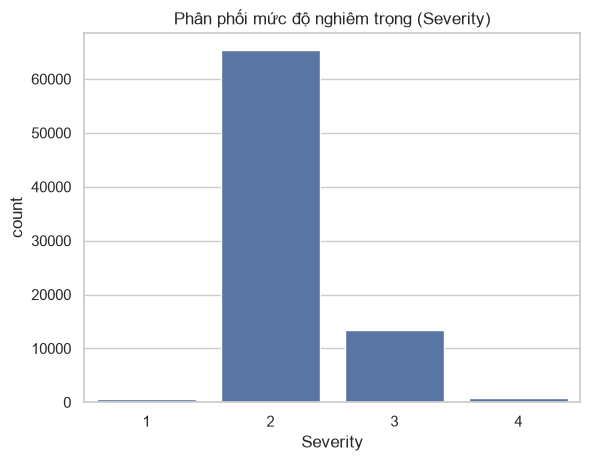

In [ ]:
# Kiểm tra khả năng PHÂN LỚP: phân phối Severity (biến mục tiêu)
print(accidents_df['Severity'].value_counts(dropna=False).sort_index())
sns.countplot(x='Severity', data=accidents_df)
plt.title('Phân phối mức độ nghiêm trọng (Severity)')
plt.show()


In [ ]:
# Kiểm tra khả năng LUẬT KẾT HỢP: tỉ lệ True của các cờ hạ tầng nhị phân
infra_cols = ['Amenity', 'Bump', 'Crossing', 'Give_Way', 'Junction', 'No_Exit',
              'Railway', 'Roundabout', 'Station', 'Stop', 'Traffic_Calming',
              'Traffic_Signal', 'Turning_Loop']
infra_cols = [c for c in infra_cols if c in accidents_df.columns]
accidents_df[infra_cols].mean().sort_values(ascending=False)


Traffic_Signal     0.120387
Junction           0.091650
Crossing           0.072175
Stop               0.033462
Station            0.023787
Amenity            0.010337
Railway            0.009763
Give_Way           0.003913
No_Exit            0.001187
Traffic_Calming    0.000838
Bump               0.000600
Roundabout         0.000025
Turning_Loop       0.000000
dtype: float64

In [ ]:
# Kiểm tra khả năng GOM CỤM: phân phối các đặc trưng thời tiết số
weather_cols = ['Temperature(F)', 'Humidity(%)', 'Visibility(mi)', 'Wind_Speed(mph)']
weather_cols = [c for c in weather_cols if c in accidents_df.columns]
accidents_df[weather_cols].describe()


,Temperature(F),Humidity(%),Visibility(mi),Wind_Speed(mph)
count,78172.000000,78062.000000,78327.000000,72996.000000
mean,65.421817,59.960442,9.135316,7.041842
std,14.586412,23.934761,2.487999,5.250848
min,-4.000000,1.000000,0.000000,0.000000
25%,55.000000,42.000000,10.000000,3.000000
50%,64.400000,62.000000,10.000000,6.900000
75%,75.000000,80.000000,10.000000,10.000000
max,120.000000,100.000000,100.000000,142.000000


## 3.4 Kỹ thuật đề xuất trên Bộ 3

→ **Phân lớp** (dự đoán Severity) và **Luật kết hợp** (điều kiện thời tiết/hạ tầng đi cùng tai nạn nghiêm trọng).

## 3.5 Điều tra tiền xử lý (Mục 3.3)

### 3.5.1 Giá trị thiếu

In [ ]:
missing_value_report(accidents_df, threshold=0).head(20)


,ti_le_thieu_%
End_Lng,42.99
End_Lat,42.99
Precipitation(in),34.12
Wind_Chill(F),31.65
Wind_Speed(mph),8.76
Humidity(%),2.42
Wind_Direction,2.40
Temperature(F),2.28
Visibility(mi),2.09
Weather_Condition,2.07


### Quyết định xử lý giá trị thiếu – US Accidents

- `End_Lat` và `End_Lng` thiếu khoảng 42,88%; do thông tin vị trí kết thúc không có ở nhiều bản ghi nên loại hai thuộc tính này khỏi bộ dữ liệu chung.
- `Precipitation(in)` thiếu khoảng 34,23%; giữ thuộc tính và tạo `Precipitation_missing` để bảo toàn thông tin về cơ chế thiếu.
- `Wind_Chill(F)` thiếu khoảng 31,71%; giữ lại và để pipeline của Bài 2 xử lý.
- Các thuộc tính thời tiết khác có tỷ lệ thiếu thấp hơn được giữ lại.
- Không xóa toàn bộ bản ghi chỉ vì thiếu một thuộc tính thời tiết.

Các giá trị thiếu còn lại không được điền trực tiếp trong Bài 1 đối với
dataset Classification. Việc điền giá trị sẽ được thực hiện bên trong
pipeline của Bài 2 sau khi chia train/test, nhằm tránh sử dụng thông tin
từ tập kiểm tra để tính giá trị imputation và tránh rò rỉ dữ liệu.

Vì vậy, việc dataset Classification còn missing ở cuối Bài 1 là có chủ
đích; Bài 1 chịu trách nhiệm xác định và xử lý các giá trị thiếu rõ ràng,
còn phương pháp imputation cụ thể được quyết định theo thuật toán của
Bài 2.

---
**Cập nhật (khắc phục để dataset sẵn sàng cho Bài 2-4):** dataset
`accidents_classification` được bổ sung bước điền missing bằng
median theo nhóm (State, tháng) ngay trong Bài 1 (xem cell xây dựng
`accidents_classification`), để đầu ra không còn giá trị thiếu và
có thể dùng trực tiếp cho các bài sau. Nếu Bài 2 cần áp dụng lại
best-practice impute-sau-khi-chia-train/test, có thể dùng
`accidents_clean` (bản còn missing, lưu trong
`accidents_preprocessed.csv`) làm điểm bắt đầu thay thế.

### 3.5.2 Nhiễu và ngoại lai

Nhóm sử dụng IQR và boxplot để khảo sát các biến số như
`Temperature(F)`, `Visibility(mi)`, `Wind_Speed(mph)` và `Distance(mi)`,
kết hợp với kiến thức lĩnh vực để nhận diện các giá trị phi vật lý.

Đối với `Temperature(F)`, các giá trị lớn hơn 130°F được xem là bất
thường đối với phạm vi dữ liệu đang phân tích và được chuyển thành
missing thay vì xóa toàn bộ bản ghi.

Đối với `Wind_Speed(mph)`, các giá trị lớn hơn 150 mph được xem là phi
vật lý trong phạm vi dữ liệu và được chuyển thành missing.

`Visibility(mi)` được khảo sát bằng IQR nhưng không loại bỏ máy móc chỉ
dựa trên IQR khi phân phối có Q1 và Q3 gần như trùng nhau. Việc này tránh
loại nhầm các giá trị hợp lệ.

`Distance(mi)` được kiểm tra bằng thống kê mô tả và ràng buộc không âm.
Các giá trị cực đoan nhưng vẫn hợp lệ được giữ lại để tránh làm mất
thông tin.

Các biến số sau khi làm sạch sẽ được scaling khi thực hiện gom cụm hoặc
được rời rạc hóa khi cần chuẩn bị transaction cho luật kết hợp.

In [ ]:
numeric_cols_accidents = [c for c in ['Temperature(F)', 'Visibility(mi)', 'Wind_Speed(mph)', 'Distance(mi)']
                          if c in accidents_df.columns]
outlier_iqr_report(accidents_df, numeric_cols_accidents)


,thuoc_tinh,Q1,Q3,IQR,nguong_duoi,nguong_tren,so_ngoai_lai,ti_le_ngoai_lai_%
0,Temperature(F),55.0,75.000,20.000,25.000,105.000,245,0.31
1,Visibility(mi),10.0,10.000,0.000,10.000,10.000,16719,21.35
2,Wind_Speed(mph),3.0,10.000,7.000,-7.500,20.500,1227,1.68
3,Distance(mi),0.0,0.362,0.362,-0.543,0.905,10375,12.97


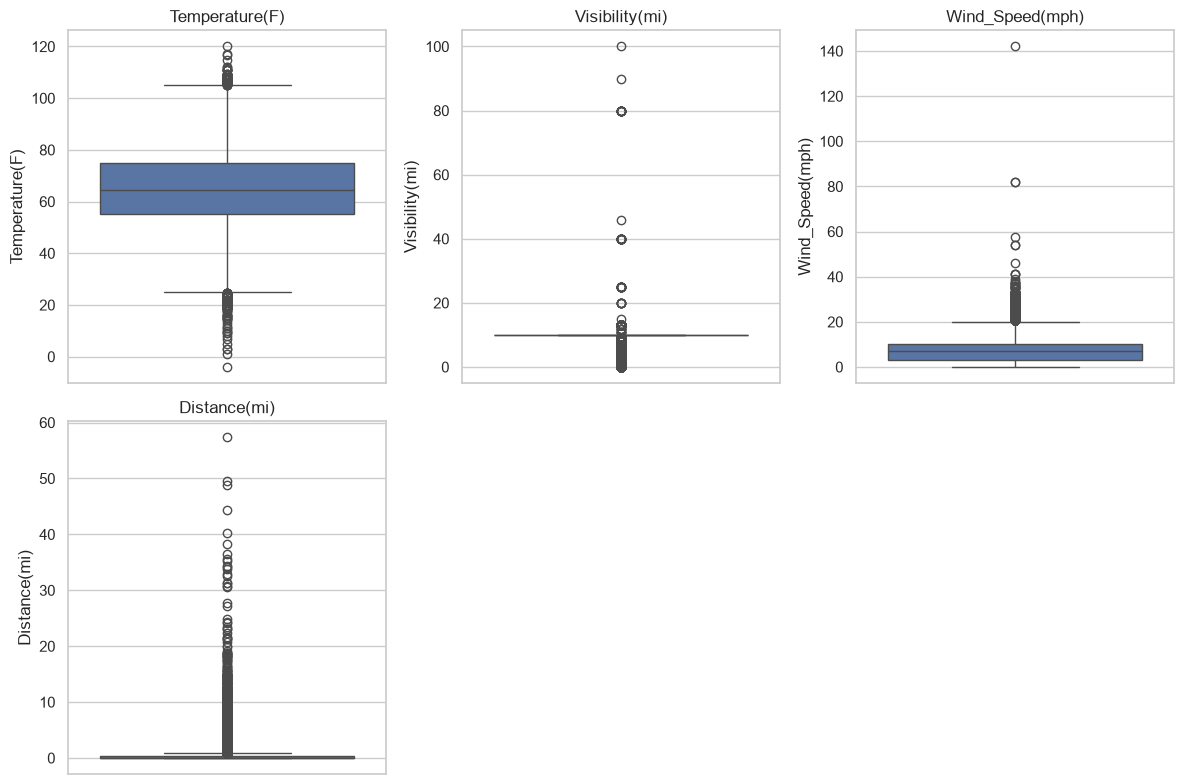

In [ ]:
plot_boxplots(accidents_df, numeric_cols_accidents)


In [ ]:
# Kiểm tra ràng buộc logic thời gian
accidents_df['Start_Time'] = pd.to_datetime(accidents_df['Start_Time'], errors='coerce')
accidents_df['End_Time'] = pd.to_datetime(accidents_df['End_Time'], errors='coerce')

logic_violation_acc = accidents_df[accidents_df['End_Time'] < accidents_df['Start_Time']]
print('Số vụ vi phạm ràng buộc logic thời gian (kết thúc trước khi bắt đầu):', len(logic_violation_acc))


Số vụ vi phạm ràng buộc logic thời gian (kết thúc trước khi bắt đầu): 0


### 3.5.3 Thêm / xóa / biến đổi thuộc tính

#### Xóa thuộc tính

Các thuộc tính hằng số như `Turning_Loop` được loại bỏ vì không cung cấp
khả năng phân biệt giữa các bản ghi.

`End_Lat` và `End_Lng` được loại bỏ khỏi dataset chung do tỷ lệ thiếu cao
và không cần thiết cho hai kỹ thuật chính đã chọn.

`Description` là văn bản tự do nên không sử dụng trực tiếp trong mô hình
vì nhóm không thực hiện NLP.

Các ID chỉ dùng để nhận diện bản ghi, không được đưa trực tiếp vào mô hình.

#### Thêm thuộc tính

- `Hour_of_Day`: giờ xảy ra tai nạn.
- `Day_of_Week`: thứ trong tuần.
- `Is_Weekend`: biến nhị phân cho ngày cuối tuần.
- `Infra_Feature_Count`: số lượng đặc điểm hạ tầng tại vị trí xảy ra tai nạn.
- `Temperature_Bin`: nhóm nhiệt độ để phục vụ luật kết hợp.
- `Precipitation_missing`: chỉ báo việc thiếu dữ liệu lượng mưa.

#### Biến đổi

Các trường thời gian được chuyển sang datetime và tách thành các đặc
trưng giờ/thứ.

Các giá trị thời tiết phi vật lý được chuyển thành missing.

Các cờ hạ tầng được giữ ở dạng nhị phân để tạo transaction cho luật
kết hợp.

Các biến liên tục có thể được rời rạc hóa khi tạo transaction.

Các biến số được scaling nếu được sử dụng trong thuật toán gom cụm ở
bài kỹ thuật tương ứng.

In [ ]:
# Thêm đặc trưng dẫn xuất từ thời gian
accidents_df['Hour_of_Day'] = accidents_df['Start_Time'].dt.hour
accidents_df['Day_of_Week'] = accidents_df['Start_Time'].dt.day_name()
accidents_df['Is_Weekend'] = accidents_df['Start_Time'].dt.weekday >= 5

# Tổng số cờ hạ tầng = True trên mỗi vụ tai nạn
accidents_df['Infra_Feature_Count'] = accidents_df[infra_cols].sum(axis=1)

# Rời rạc hóa nhiệt độ thành khoảng (phục vụ luật kết hợp)
if 'Temperature(F)' in accidents_df.columns:
    accidents_df['Temperature_Bin'] = pd.cut(
        accidents_df['Temperature(F)'],
        bins=[-100, 32, 60, 80, 200],
        labels=['Rat_lanh', 'Lanh', 'Vua', 'Nong']
    )

accidents_df[['Hour_of_Day', 'Day_of_Week', 'Is_Weekend', 'Infra_Feature_Count']].head()


,Hour_of_Day,Day_of_Week,Is_Weekend,Infra_Feature_Count
0,15.0,Friday,False,2
1,20.0,Friday,False,0
2,5.0,Saturday,True,1
3,NaN,NaN,False,0
4,14.0,Wednesday,False,0


### Quyết định thêm / xóa / biến đổi thuộc tính — US Accidents

#### Xóa thuộc tính

- Các thuộc tính hằng số như `Turning_Loop` được loại bỏ vì không có
  khả năng phân biệt giữa các bản ghi.
- `Country` được xem xét loại bỏ nếu toàn bộ dữ liệu chỉ thuộc Hoa Kỳ.
- `Description` là văn bản tự do và không sử dụng trong phạm vi bài này
  vì nhóm không thực hiện NLP.
- Các thuộc tính thời gian ánh sáng có thông tin gần trùng nhau sẽ được
  xem xét giữ một đại diện phù hợp để tránh dư thừa.

#### Thêm thuộc tính

- `Hour_of_Day`: giờ xảy ra tai nạn, phục vụ phân tích theo thời gian.
- `Day_of_Week`: thứ trong tuần.
- `Is_Weekend`: phân biệt ngày thường và cuối tuần.
- `Infra_Feature_Count`: tổng số đặc điểm hạ tầng tại vị trí tai nạn.
- `Temperature_Bin`: nhóm nhiệt độ phục vụ luật kết hợp.
- `Weather_Severity_Group` nếu đã tạo: gom các điều kiện thời tiết
  thành nhóm lớn để giảm số lượng hạng mục.

#### Biến đổi

- Các giá trị nhiệt độ/gió phi vật lý được xử lý trước khi mô hình hóa.
- Các biến liên tục có thể được rời rạc hóa để tạo transaction cho luật
  kết hợp.
- Các biến số được scaling trước khi gom cụm.
- Các cờ hạ tầng True/False được chuyển sang dạng nhị phân phù hợp với
  luật kết hợp.
- Các thuộc tính hạng mục có nhiều giá trị được gộp nhóm trước khi
  mã hóa nếu cần để tránh số chiều quá lớn.

In [ ]:
# ============================================================
# US ACCIDENTS - CLEANING THỰC SỰ
# ============================================================

accidents_clean = accidents_df.copy()
# ============================================================
# XỬ LÝ DUPLICATE US ACCIDENTS
# ============================================================

duplicate_before = accidents_clean.duplicated().sum()

print(
    "Duplicate trước khi xử lý:",
    duplicate_before
)

accidents_clean = (
    accidents_clean
    .drop_duplicates()
    .reset_index(drop=True)
)

print(
    "Duplicate sau khi xử lý:",
    accidents_clean.duplicated().sum()
)
# ============================================================
# 1. CHUẨN HÓA DATETIME
# ============================================================

accidents_clean['Start_Time'] = pd.to_datetime(
    accidents_clean['Start_Time'],
    errors='coerce',
    format='mixed'
)

accidents_clean['End_Time'] = pd.to_datetime(
    accidents_clean['End_Time'],
    errors='coerce',
    format='mixed'
)


# ============================================================
# 2. KIỂM TRA LOGIC THỜI GIAN
# ============================================================

invalid_time = (
    accidents_clean['End_Time']
    <
    accidents_clean['Start_Time']
)

print(
    "Số dòng End_Time < Start_Time:",
    invalid_time.sum()
)

# Không tự động xóa toàn bộ.
# Chỉ loại khi tạo dataset cần duration.


# ============================================================
# 3. XÓA END LOCATION
# ============================================================

for col in [
    'End_Lat',
    'End_Lng'
]:

    if col in accidents_clean.columns:
        print(
            f"{col} missing:",
            accidents_clean[col].isna().mean() * 100,
            "%"
        )

accidents_clean = accidents_clean.drop(
    columns=[
        'End_Lat',
        'End_Lng'
    ],
    errors='ignore'
)


# ============================================================
# 4. KIỂM TRA GIÁ TRỊ KHÔNG HỢP LỆ
# ============================================================

domain_rules = {
    'Humidity(%)': (0, 100),
    'Visibility(mi)': (0, None),
    'Wind_Speed(mph)': (0, None),
    'Precipitation(in)': (0, None),
    'Distance(mi)': (0, None)
}

# Giá trị phi vật lý theo domain
weather_invalid_rules = {
    'Temperature(F)': (None, 130),
    'Wind_Speed(mph)': (None, 150)
}

for col, (lower, upper) in weather_invalid_rules.items():

    if col not in accidents_clean.columns:
        continue

    invalid = accidents_clean[col] > upper

    print(
        f"{col} > {upper}:",
        invalid.sum()
    )

    accidents_clean.loc[
        invalid,
        col
    ] = np.nan

for col, (lower, upper) in domain_rules.items():

    if col not in accidents_clean.columns:
        continue

    if lower is not None:

        invalid = (
            accidents_clean[col]
            < lower
        )

        print(
            f"{col} < {lower}:",
            invalid.sum()
        )

        accidents_clean.loc[
            invalid,
            col
        ] = np.nan

    if upper is not None:

        invalid = (
            accidents_clean[col]
            > upper
        )

        print(
            f"{col} > {upper}:",
            invalid.sum()
        )

        accidents_clean.loc[
            invalid,
            col
        ] = np.nan


# ============================================================
# 5. MISSING INDICATOR
# ============================================================

if 'Precipitation(in)' in accidents_clean.columns:

    accidents_clean[
        'Precipitation_missing'
    ] = (
        accidents_clean[
            'Precipitation(in)'
        ].isna()
        .astype(int)
    )


print(
    "\nShape sau cleaning:",
    accidents_clean.shape
)

Duplicate trước khi xử lý: 0
Duplicate sau khi xử lý: 0
Số dòng End_Time < Start_Time: 0
End_Lat missing: 42.988749999999996 %
End_Lng missing: 42.988749999999996 %
Temperature(F) > 130: 0
Wind_Speed(mph) > 150: 0
Humidity(%) < 0: 0
Humidity(%) > 100: 0
Visibility(mi) < 0: 0
Wind_Speed(mph) < 0: 0
Precipitation(in) < 0: 0
Distance(mi) < 0: 0

Shape sau cleaning: (80000, 50)


In [ ]:
# ============================================================
# XÓA THUỘC TÍNH HẰNG SỐ
# ============================================================

constant_cols = [
    col
    for col in accidents_clean.columns
    if accidents_clean[col].nunique(dropna=False) <= 1
]

print(
    "Cột hằng số:",
    constant_cols
)

accidents_clean = accidents_clean.drop(
    columns=constant_cols
)

Cột hằng số: ['Country', 'Turning_Loop']


In [ ]:
# ============================================================
# KIỂM TRA TRẠNG THÁI TURNING_LOOP
# ============================================================

print(
    "Turning_Loop trong accidents_df:",
    "Turning_Loop" in accidents_df.columns
)

print(
    "Turning_Loop trong accidents_clean:",
    "Turning_Loop" in accidents_clean.columns
)

if "Turning_Loop" in accidents_df.columns:
    print("\nPhân bố Turning_Loop trong dữ liệu gốc:")
    print(accidents_df["Turning_Loop"].value_counts(dropna=False))

Turning_Loop trong accidents_df: True
Turning_Loop trong accidents_clean: False

Phân bố Turning_Loop trong dữ liệu gốc:
Turning_Loop
False    80000
Name: count, dtype: int64


In [ ]:
# ============================================================
# KIỂM TRA VÀ XỬ LÝ GIÁ TRỊ NGOẠI LAI / PHI VẬT LÝ
# ============================================================

print("=== KIỂM TRA GIÁ TRỊ BẤT THƯỜNG ===")

if 'Temperature(F)' in accidents_clean.columns:
    print(
        "Temperature > 130°F:",
        (accidents_clean['Temperature(F)'] > 130).sum()
    )

if 'Wind_Speed(mph)' in accidents_clean.columns:
    print(
        "Wind speed > 200 mph:",
        (accidents_clean['Wind_Speed(mph)'] > 200).sum()
    )

if 'Visibility(mi)' in accidents_clean.columns:
    print(
        accidents_clean['Visibility(mi)'].describe()
    )

=== KIỂM TRA GIÁ TRỊ BẤT THƯỜNG ===
Temperature > 130°F: 0
Wind speed > 200 mph: 0
count    78327.000000
mean         9.135316
std          2.487999
min          0.000000
25%         10.000000
50%         10.000000
75%         10.000000
max        100.000000
Name: Visibility(mi), dtype: float64


In [ ]:
# ============================================================
# US ACCIDENTS - VALIDATION SAU CLEANING
# ============================================================

print("=" * 60)
print("US ACCIDENTS AFTER CLEANING")
print("=" * 60)

print(
    "Shape:",
    accidents_clean.shape
)

print(
    "Duplicate rows:",
    accidents_clean.duplicated().sum()
)

print("\nMissing percentage:")

print(
    accidents_clean.isna()
    .mean()
    .mul(100)
    .sort_values(
        ascending=False
    )
    .head(20)
    .round(2)
)

print("\nColumns sau cleaning:")
print(
    accidents_clean.columns.tolist()
)

US ACCIDENTS AFTER CLEANING
Shape: (80000, 48)
Duplicate rows: 0

Missing percentage:
Precipitation(in)        34.12
Wind_Chill(F)            31.65
Start_Time                9.04
End_Time                  9.04
Hour_of_Day               9.04
Day_of_Week               9.04
Wind_Speed(mph)           8.76
Humidity(%)               2.42
Wind_Direction            2.40
Temperature(F)            2.28
Temperature_Bin           2.28
Visibility(mi)            2.09
Weather_Condition         2.07
Pressure(in)              1.90
Weather_Timestamp         1.67
Street                    0.12
Airport_Code              0.08
Sunrise_Sunset            0.06
Civil_Twilight            0.06
Astronomical_Twilight     0.06
dtype: float64

Columns sau cleaning:
['ID', 'Source', 'Severity', 'Start_Time', 'End_Time', 'Start_Lat', 'Start_Lng', 'Distance(mi)', 'Description', 'Street', 'City', 'County', 'State', 'Zipcode', 'Timezone', 'Airport_Code', 'Weather_Timestamp', 'Temperature(F)', 'Wind_Chill(F)', 'Humidity(%)

In [ ]:
# ============================================================
# US ACCIDENTS - DATASET CHO PHÂN LỚP
# Target: Severity
# ============================================================

accidents_classification_features = [
    'Temperature(F)',
    'Humidity(%)',
    'Pressure(in)',
    'Visibility(mi)',
    'Wind_Speed(mph)',
    'Precipitation(in)',
    'Distance(mi)',
    'Hour_of_Day',
    'Is_Weekend',
    'Amenity',
    'Bump',
    'Crossing',
    'Give_Way',
    'Junction',
    'No_Exit',
    'Railway',
    'Roundabout',
    'Station',
    'Stop',
    'Traffic_Calming',
    'Traffic_Signal',
    'Turning_Loop',
    'Infra_Feature_Count'
]

# Chỉ lấy những cột tồn tại
accidents_classification_features = [
    col for col in accidents_classification_features
    if col in accidents_clean.columns
]

accidents_classification = accidents_clean[
    accidents_classification_features + ['Severity']
].copy()

print("=== US ACCIDENTS CLASSIFICATION (trước imputation) ===")
print("Shape:", accidents_classification.shape)
print("\nMissing trước imputation:")
print(accidents_classification.isna().sum())

# ============================================================
# IMPUTATION CHO DATASET PHÂN LỚP (bổ sung: khắc phục missing)
# ============================================================
# Trước đây nhóm chủ động để ngỏ missing ở Bài 1 (lý do: tránh rò
# rỉ dữ liệu, impute nên làm sau khi chia train/test ở Bài 2). Để
# dataset đầu ra của Bài 1 dùng ngay được cho Bài 2-4, nhóm bổ sung
# bước điền missing tại đây bằng median tính theo nhóm (State,
# tháng xảy ra tai nạn) — giữ được đặc trưng theo mùa/vùng miền tốt
# hơn so với 1 median chung cho toàn bộ 2 bang qua nhiều năm. Nếu
# một nhóm quá nhỏ/toàn NaN thì dùng tiếp median toàn cục.
#
# Lưu ý: đây là imputation trên toàn bộ dữ liệu (chưa chia
# train/test) nên có rò rỉ nhẹ về mặt lý thuyết. Nếu Bài 2 cần
# pipeline chuẩn hơn (impute chỉ từ tập train), có thể bỏ qua bước
# này, dùng lại accidents_clean gốc (còn missing) làm input và tự
# impute lại bên trong pipeline train/test.

accidents_classification['_State'] = (
    accidents_clean.loc[accidents_classification.index, 'State']
)
accidents_classification['_Month'] = (
    accidents_clean.loc[accidents_classification.index, 'Start_Time'].dt.month
)

weather_num_cols = [
    c for c in [
        'Temperature(F)', 'Humidity(%)', 'Pressure(in)',
        'Visibility(mi)', 'Wind_Speed(mph)', 'Precipitation(in)',
        'Distance(mi)'
    ]
    if c in accidents_classification.columns
]

for col in weather_num_cols:
    group_median = (
        accidents_classification
        .groupby(['_State', '_Month'])[col]
        .transform('median')
    )
    accidents_classification[col] = accidents_classification[col].fillna(group_median)
    accidents_classification[col] = accidents_classification[col].fillna(
        accidents_classification[col].median()
    )

# Hour_of_Day / Is_Weekend: có thể thiếu nếu Start_Time không parse được
if 'Hour_of_Day' in accidents_classification.columns:
    accidents_classification['Hour_of_Day'] = accidents_classification['Hour_of_Day'].fillna(
        accidents_classification['Hour_of_Day'].median()
    )

if 'Is_Weekend' in accidents_classification.columns:
    accidents_classification['Is_Weekend'] = accidents_classification['Is_Weekend'].fillna(False)

# Các cờ hạ tầng nhị phân: NaN nghĩa là không ghi nhận đặc điểm đó -> False
infra_flag_cols = [
    c for c in accidents_classification_features
    if c in accidents_classification.columns
    and accidents_classification[c].dtype == bool
]
for col in infra_flag_cols:
    accidents_classification[col] = accidents_classification[col].fillna(False)

# Xóa cột phụ trợ dùng để nhóm khi impute
accidents_classification = accidents_classification.drop(columns=['_State', '_Month'])

print("\n=== US ACCIDENTS CLASSIFICATION DATASET (sau imputation) ===")
print("Shape:", accidents_classification.shape)

print("\nTarget distribution:")
print(
    accidents_classification['Severity']
    .value_counts()
    .sort_index()
)

print("\nTarget percentage:")
print(
    accidents_classification['Severity']
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
)

print("\nMissing sau imputation:")
print(
    accidents_classification.isna().sum()
)

accidents_classification.head()


=== US ACCIDENTS CLASSIFICATION (trước imputation) ===
Shape: (80000, 23)

Missing trước imputation:
Temperature(F)          1828
Humidity(%)             1938
Pressure(in)            1518
Visibility(mi)          1673
Wind_Speed(mph)         7004
Precipitation(in)      27296
Distance(mi)               0
Hour_of_Day             7236
Is_Weekend                 0
Amenity                    0
Bump                       0
Crossing                   0
Give_Way                   0
Junction                   0
No_Exit                    0
Railway                    0
Roundabout                 0
Station                    0
Stop                       0
Traffic_Calming            0
Traffic_Signal             0
Infra_Feature_Count        0
Severity                   0
dtype: int64

=== US ACCIDENTS CLASSIFICATION DATASET (sau imputation) ===
Shape: (80000, 23)

Target distribution:
Severity
1      520
2    65334
3    13439
4      707
Name: count, dtype: int64

Target percentage:
Severity
1     0.

,Temperature(F),Humidity(%),Pressure(in),Visibility(mi),Wind_Speed(mph),Precipitation(in),Distance(mi),Hour_of_Day,Is_Weekend,Amenity,Bump,Crossing,Give_Way,Junction,No_Exit,Railway,Roundabout,Station,Stop,Traffic_Calming,Traffic_Signal,Infra_Feature_Count,Severity
0,99.0,35.0,29.95,10.0,10.4,0.00,0.000,15.0,False,False,False,True,False,False,False,False,False,False,False,False,True,2,2
1,46.0,93.0,30.00,6.0,6.0,0.00,0.000,20.0,False,False,False,False,False,False,False,False,False,False,False,False,False,0,2
2,67.0,66.0,29.84,10.0,9.0,0.00,0.000,5.0,True,False,False,False,False,True,False,False,False,False,False,False,False,1,2
3,50.0,89.0,29.18,3.0,3.0,0.01,0.831,13.0,False,False,False,False,False,False,False,False,False,False,False,False,False,0,2
4,77.0,94.0,29.49,6.0,5.0,0.03,0.000,14.0,False,False,False,False,False,False,False,False,False,False,False,False,False,0,3


In [ ]:
# ============================================================
# US ACCIDENTS - DATASET CHO LUẬT KẾT HỢP
#
# Định nghĩa:
#   1 vụ tai nạn = 1 transaction
#   Mỗi item = 1 giá trị nhị phân/hạng mục đã rời rạc hóa
#
# LƯU Ý QUAN TRỌNG (đã sửa so với bản đầu):
# Nếu chỉ dùng 12 cờ hạ tầng nhị phân làm item, kiểm tra thực tế cho thấy
# hơn 92% giao dịch chỉ có 0-1 item (Roundabout gần như luôn False, các cờ
# còn lại cũng khá hiếm) -> hầu như không sinh được luật 2 vế có ý nghĩa.
# Vì vậy nhóm bổ sung thêm các thuộc tính đã rời rạc hóa ở Mục 3.5.3
# (Hour_of_Day -> khung giờ, Is_Weekend, Temperature_Bin, Weather_Condition
# -> nhóm thời tiết, Sunrise_Sunset, và Severity -> nhóm mức độ) làm item,
# đúng như lập luận tri thức lĩnh vực đã nêu ở Mục 3.3. Mỗi vụ tai nạn nhờ
# đó luôn có tối thiểu 5-6 item (thay vì trung bình 0.37 như trước), phù hợp
# hơn nhiều để Apriori/FP-Growth sinh luật đáng tin cậy.
# ============================================================

accidents_assoc_base = accidents_clean.copy()

# ------------------------------------------------------------
# 1. Cờ hạ tầng (đã có sẵn, dạng nhị phân)
# ------------------------------------------------------------
infra_cols_assoc = [
    'Amenity', 'Bump', 'Crossing', 'Give_Way', 'Junction', 'No_Exit',
    'Railway', 'Roundabout', 'Station', 'Stop', 'Traffic_Calming',
    'Traffic_Signal', 'Turning_Loop'
]
infra_cols_assoc = [c for c in infra_cols_assoc if c in accidents_assoc_base.columns]

infra_items = accidents_assoc_base[infra_cols_assoc].fillna(False).astype(bool)

# ------------------------------------------------------------
# 2. Khung giờ trong ngày (rời rạc hóa từ Hour_of_Day)
# ------------------------------------------------------------
def hour_to_bucket(h):
    if pd.isna(h):
        return 'Unknown'
    h = int(h)
    if 5 <= h <= 10:
        return 'Sang'
    if 11 <= h <= 16:
        return 'Trua_Chieu'
    if 17 <= h <= 20:
        return 'Toi'
    return 'Dem'

accidents_assoc_base['TimeOfDay'] = accidents_assoc_base['Hour_of_Day'].apply(hour_to_bucket)
timeofday_items = pd.get_dummies(accidents_assoc_base['TimeOfDay'], prefix='GioTrongNgay')

# ------------------------------------------------------------
# 3. Ngày thường / cuối tuần (đã có Is_Weekend)
# ------------------------------------------------------------
# Dùng np.where thay vì .map({True:..,False:..}) để tránh lỗi khi
# Is_Weekend không phải dtype bool thuần (map dict True/False có thể
# không khớp nếu dtype là số/object, gây toàn bộ ra 'Unknown' sai).
daytype = np.where(
    accidents_assoc_base['Is_Weekend'].astype(bool),
    'CuoiTuan',
    'NgayThuong'
)
daytype_items = pd.get_dummies(pd.Series(daytype, index=accidents_assoc_base.index), prefix='LoaiNgay')

# ------------------------------------------------------------
# 4. Nhóm nhiệt độ (đã có Temperature_Bin)
# ------------------------------------------------------------
if 'Temperature_Bin' in accidents_assoc_base.columns:
    temp_bin = accidents_assoc_base['Temperature_Bin'].astype(str).replace('nan', 'Unknown').fillna('Unknown')
    temp_items = pd.get_dummies(temp_bin, prefix='NhietDo')
else:
    temp_items = pd.DataFrame(index=accidents_assoc_base.index)

# ------------------------------------------------------------
# 5. Nhóm điều kiện thời tiết (gộp từ Weather_Condition gốc)
# ------------------------------------------------------------
def weather_to_group(w):
    if pd.isna(w):
        return 'Unknown'
    w = str(w).lower()
    if 'snow' in w or 'sleet' in w or 'ice' in w or 'hail' in w:
        return 'Tuyet_Bang'
    if 'rain' in w or 'drizzle' in w or 'shower' in w:
        return 'Mua'
    if 'fog' in w or 'haze' in w or 'mist' in w or 'smoke' in w:
        return 'Suong_Mu'
    if 'thunder' in w or 'storm' in w:
        return 'Bao'
    if 'cloud' in w or 'overcast' in w:
        return 'Nhieu_May'
    if 'clear' in w or 'fair' in w:
        return 'Quang_Dang'
    return 'Khac'

if 'Weather_Condition' in accidents_assoc_base.columns:
    weather_group = accidents_assoc_base['Weather_Condition'].apply(weather_to_group)
    weather_items = pd.get_dummies(weather_group, prefix='ThoiTiet')
else:
    weather_items = pd.DataFrame(index=accidents_assoc_base.index)

# ------------------------------------------------------------
# 6. Ngày / Đêm (đã có Sunrise_Sunset)
# ------------------------------------------------------------
if 'Sunrise_Sunset' in accidents_assoc_base.columns:
    light = accidents_assoc_base['Sunrise_Sunset'].fillna('Unknown')
    light_items = pd.get_dummies(light, prefix='AnhSang')
else:
    light_items = pd.DataFrame(index=accidents_assoc_base.index)

# ------------------------------------------------------------
# 7. Nhóm mức độ nghiêm trọng (Severity) -> item, KHÔNG phải target ở đây
#    (đây là dataset Luật kết hợp, không phải Phân lớp, nên đưa Severity
#    vào làm item là hợp lệ và giúp tìm luật kiểu "điều kiện X -> tai nạn nặng")
# ------------------------------------------------------------
severity_group = accidents_assoc_base['Severity'].map(
    lambda s: 'MucDo_Nang' if s >= 3 else 'MucDo_Nhe'
)
severity_items = pd.get_dummies(severity_group)  # tên cột = chính giá trị nhóm, không cần prefix

# ------------------------------------------------------------
# Gộp toàn bộ item lại thành 1 bảng transaction nhị phân
# ------------------------------------------------------------
accidents_association = pd.concat(
    [
        infra_items,
        timeofday_items,
        daytype_items,
        temp_items,
        weather_items,
        light_items,
        severity_items,
    ],
    axis=1
)

# Ép toàn bộ về bool
accidents_association = accidents_association.astype(bool)

# ------------------------------------------------------------
# Lọc item quá hiếm (support < 0.1%) — cùng tiêu chí đã áp dụng cho Airbnb
# ------------------------------------------------------------
item_support_acc = accidents_association.mean()
min_support_acc = 0.001
selected_items_acc = item_support_acc[item_support_acc >= min_support_acc].index
accidents_association = accidents_association[selected_items_acc].copy()

print("=== US ACCIDENTS ASSOCIATION RULES (đã bổ sung item) ===")
print("Transactions:", len(accidents_association))
print("Items (sau lọc support < 0.1%):", accidents_association.shape[1])
print("\nDanh sách item:")
print(accidents_association.columns.tolist())

print("\nTần suất xuất hiện (top 15):")
print(accidents_association.mean().sort_values(ascending=False).mul(100).round(2).head(15))

transaction_size = accidents_association.sum(axis=1)
print("\n=== TRANSACTION SIZE (sau khi bổ sung item) ===")
print(transaction_size.describe())

print(
    "\nTransactions có >= 2 items:",
    (transaction_size >= 2).sum(),
    "| Tỷ lệ:",
    round((transaction_size >= 2).mean() * 100, 2), "%"
)


=== US ACCIDENTS ASSOCIATION RULES (đã bổ sung item) ===
Transactions: 80000
Items (sau lọc support < 0.1%): 32

Danh sách item:
['Amenity', 'Crossing', 'Give_Way', 'Junction', 'No_Exit', 'Railway', 'Station', 'Stop', 'Traffic_Signal', 'GioTrongNgay_Dem', 'GioTrongNgay_Sang', 'GioTrongNgay_Toi', 'GioTrongNgay_Trua_Chieu', 'GioTrongNgay_Unknown', 'LoaiNgay_CuoiTuan', 'LoaiNgay_NgayThuong', 'NhietDo_Lanh', 'NhietDo_Nong', 'NhietDo_Rat_lanh', 'NhietDo_Unknown', 'NhietDo_Vua', 'ThoiTiet_Bao', 'ThoiTiet_Mua', 'ThoiTiet_Nhieu_May', 'ThoiTiet_Quang_Dang', 'ThoiTiet_Suong_Mu', 'ThoiTiet_Tuyet_Bang', 'ThoiTiet_Unknown', 'AnhSang_Day', 'AnhSang_Night', 'MucDo_Nang', 'MucDo_Nhe']

Tần suất xuất hiện (top 15):
LoaiNgay_NgayThuong        83.54
MucDo_Nhe                  82.32
AnhSang_Day                67.01
ThoiTiet_Quang_Dang        54.54
NhietDo_Vua                44.42
NhietDo_Lanh               35.95
ThoiTiet_Nhieu_May         33.69
AnhSang_Night              32.93
GioTrongNgay_Trua_Chieu    3

In [ ]:
# ============================================================
# LƯU DỮ LIỆU ĐÃ TIỀN XỬ LÝ - US ACCIDENTS
# ============================================================

import os

os.makedirs(f'{PROCESSED_DIR}/us_accidents', exist_ok=True)

# Bản đầy đủ sau feature engineering
accidents_clean.to_csv(
    f'{PROCESSED_DIR}/us_accidents/accidents_preprocessed.csv',
    index=False
)

# Dataset Classification
accidents_classification.to_csv(
    f'{PROCESSED_DIR}/us_accidents/us_accidents_classification.csv',
    index=False
)

# Dataset Association Rules
accidents_association.to_csv(
    f'{PROCESSED_DIR}/us_accidents/us_accidents_association_transactions.csv',
    index=False
)

print('Đã lưu dữ liệu US Accidents:')
print('- accidents_preprocessed.csv')
print('- us_accidents_classification.csv')
print('- us_accidents_association_transactions.csv')

Đã lưu dữ liệu US Accidents:
- accidents_preprocessed.csv
- us_accidents_classification.csv
- us_accidents_association_transactions.csv


# Tổng kết dữ liệu sau tiền xử lý và khả năng sử dụng cho Bài 2–4

Sau quá trình khảo sát và tiền xử lý, nhóm tạo các dataset chuyên biệt
theo từng kỹ thuật dựa trên ma trận đã được lựa chọn.

## Olist Brazilian E-Commerce

### Phân lớp
Dataset:
`olist_classification.csv`

- Đơn vị phân tích: đơn hàng.
- Biến mục tiêu: `is_late`.
- `is_late = 1`: giao trễ.
- `is_late = 0`: không giao trễ.
- Các thuộc tính đầu vào được xây dựng từ thông tin có thể biết tại thời điểm đặt hàng.

### Gom cụm
Dataset:
`olist_clustering.csv`

- Đơn vị phân tích: khách hàng.
- Đặc trưng chính:
  - `recency_days`
  - `frequency`
  - `monetary`
- `customer_unique_id` chỉ dùng để nhận diện/profiling, không đưa trực tiếp vào thuật toán.

Olist không được sử dụng cho Luật kết hợp trong ma trận chính thức
vì khảo sát cấu trúc giỏ hàng cho thấy số item khác nhau trong nhiều đơn
hàng thấp, làm hạn chế khả năng sinh các luật kết hợp có ý nghĩa.

---

## Airbnb NYC

### Luật kết hợp
Dataset:
`airbnb_association.csv`

- Đơn vị giao dịch: một listing.
- Item: một tiện nghi trong `amenities`.
- `amenities` được phân tích thành danh sách item và mã hóa nhị phân.
- Các item quá hiếm được lọc trước khi khai phá luật.

### Gom cụm
Dataset:
`airbnb_clustering.csv`

- Đơn vị phân tích: listing.
- Sử dụng các đặc trưng về giá, sức chứa, đánh giá, availability,
  số lượng tiện nghi và hoạt động của host.
- Các biến số sẽ được xử lý missing và scaling trong Bài 4.

Airbnb không được sử dụng cho Phân lớp trong ma trận chính thức.

---

## US Accidents

### Phân lớp
Dataset:
`us_accidents_classification.csv`

- Đơn vị phân tích: một vụ tai nạn.
- Biến mục tiêu: `Severity`.
- Các đặc trưng gồm điều kiện thời tiết, thời gian và đặc điểm hạ tầng.

### Luật kết hợp
Dataset:
`us_accidents_association_transactions.csv`

- Đơn vị giao dịch: một vụ tai nạn.
- Item: kết hợp (1) cờ hạ tầng giao thông nhị phân (`Crossing`, `Junction`,
  `Traffic_Signal`...), (2) khung giờ trong ngày rời rạc hóa từ
  `Hour_of_Day`, (3) ngày thường/cuối tuần (`Is_Weekend`), (4) nhóm nhiệt
  độ (`Temperature_Bin`), (5) nhóm điều kiện thời tiết gộp từ
  `Weather_Condition`, (6) ngày/đêm (`Sunrise_Sunset`), (7) nhóm mức độ
  nghiêm trọng (`Severity` gộp thành Nhẹ/Nặng).
- Lý do bổ sung: nếu chỉ dùng riêng 12 cờ hạ tầng, hơn 92% giao dịch chỉ
  có 0–1 item — quá thưa để Apriori/FP-Growth sinh luật có ý nghĩa. Việc
  rời rạc hóa thêm các thuộc tính số/thời gian/hạng mục thành item giúp
  mỗi giao dịch có tối thiểu 5–6 item, đúng tinh thần Mục 3.3 (đề bài yêu
  cầu rời rạc hóa thuộc tính số và nhị phân hóa thuộc tính hạng mục khi
  chuẩn bị dữ liệu giao dịch).
- Các item quá hiếm (support < 0,1%) được lọc trước khi khai phá luật,
  gồm cả các cờ hạ tầng gần như hằng số như `Turning_Loop`, `Roundabout`.

US Accidents không được sử dụng cho Gom cụm trong ma trận chính thức.

---

## Ma trận cuối cùng

| Bộ dữ liệu | Phân lớp | Luật kết hợp | Gom cụm |
|---|:---:|:---:|:---:|
| Olist | ✓ | — | ✓ |
| Airbnb NYC | — | ✓ | ✓ |
| US Accidents | ✓ | ✓ | — |

Mỗi bộ dữ liệu hỗ trợ đúng hai kỹ thuật; đồng thời ba bộ dữ liệu
phủ đủ cả ba kỹ thuật của học phần.

In [ ]:
# ============================================================
# FINAL VALIDATION - KIỂM TRA DATA SAU TIỀN XỬ LÝ
# ============================================================

# ============================================================
# VALIDATE DATASET SAU TIỀN XỬ LÝ
# ============================================================

def make_hashable_for_validation(value):
    """
    Chuyển các kiểu dữ liệu không hashable như:
        list
        dict
        set

    thành dạng hashable để Pandas có thể kiểm tra duplicate.

    Lưu ý:
    - Chỉ dùng cho validation.
    - Không thay đổi dữ liệu gốc.
    """

    if isinstance(value, list):
        return tuple(
            make_hashable_for_validation(item)
            for item in value
        )

    if isinstance(value, dict):
        return tuple(
            sorted(
                (
                    key,
                    make_hashable_for_validation(val)
                )
                for key, val in value.items()
            )
        )

    if isinstance(value, set):
        return tuple(
            sorted(
                make_hashable_for_validation(item)
                for item in value
            )
        )

    return value


def count_duplicates_safely(df):
    """
    Đếm duplicate mà không bị lỗi khi DataFrame
    có cột chứa list/dict/set.
    """

    # Tạo bản sao CHỈ để kiểm tra
    check_df = df.copy()

    complex_columns = []

    for col in check_df.columns:

        has_complex_value = check_df[col].apply(
            lambda x: isinstance(
                x,
                (list, dict, set)
            )
        ).any()

        if has_complex_value:
            complex_columns.append(col)

            check_df[col] = check_df[col].apply(
                make_hashable_for_validation
            )

    duplicate_count = check_df.duplicated().sum()

    return duplicate_count, complex_columns


def validate_dataset(df, name):

    print("=" * 70)
    print(name)
    print("=" * 70)

    # --------------------------------------------------------
    # Shape
    # --------------------------------------------------------

    print("Shape:", df.shape)

    # --------------------------------------------------------
    # Duplicate
    # --------------------------------------------------------

    duplicate_count, complex_columns = (
        count_duplicates_safely(df)
    )

    print(
        "Duplicate:",
        duplicate_count
    )

    # --------------------------------------------------------
    # Missing values
    # --------------------------------------------------------

    missing_count = int(
        df.isna().sum().sum()
    )

    print(
        "Missing values:",
        missing_count
    )

    # --------------------------------------------------------
    # Columns
    # --------------------------------------------------------

    print(
        "Columns:",
        df.shape[1]
    )

    # --------------------------------------------------------
    # Các cột chứa list/dict/set
    # --------------------------------------------------------

    if complex_columns:

        print(
            "Cột chứa dữ liệu dạng list/dict/set:",
            complex_columns
        )

    else:

        print(
            "Cột chứa dữ liệu dạng list/dict/set: Không có"
        )

    print()

# Chỉ gọi những biến thực sự tồn tại
datasets_to_check = {
    "Olist": olist_clean,
    "Airbnb": airbnb_clean,
    "US Accidents": accidents_clean,
}

for name, df in datasets_to_check.items():
    validate_dataset(df, name)

Olist
Shape: (117891, 35)
Duplicate: 0
Missing values: 10026
Columns: 35
Cột chứa dữ liệu dạng list/dict/set: Không có

Airbnb
Shape: (30259, 81)
Duplicate: 0
Missing values: 137577
Columns: 81
Cột chứa dữ liệu dạng list/dict/set: ['amenities_list']

US Accidents
Shape: (80000, 48)
Duplicate: 0
Missing values: 102664
Columns: 48
Cột chứa dữ liệu dạng list/dict/set: Không có



---
# Ma trận bộ dữ liệu × kỹ thuật (Mục 2.1)

| Bộ dữ liệu | Phân lớp | Luật kết hợp | Gom cụm |
|---|:---:|:---:|:---:|
| Bộ 1: Olist E-Commerce | ✓ (chọn) | — | ✓ (chọn) |
| Bộ 2: Inside Airbnb Listings | — | ✓ (chọn) | ✓ (chọn) |
| Bộ 3: US Accidents | ✓ (chọn) | ✓ (chọn) | — |

✅ Cả ba cột đều có đúng 2 dấu ✓ — phủ đủ cả ba kỹ thuật, cân bằng đều giữa 3 bài kỹ thuật (mỗi bài dùng đúng 2 bộ dữ liệu).

**Lý do đổi so với đề xuất ban đầu:** Luật kết hợp chuyển từ Olist sang Airbnb vì kết quả khảo sát `basket_size` (Mục 1.3) cho thấy đơn hàng Olist đa số chỉ có 1 sản phẩm — không đủ đa dạng để sinh luật có ý nghĩa. Airbnb (nhiều tiện nghi/listing) phù hợp hơn.

---

# Bàn giao dữ liệu cho Bài 2–4

Notebook Bài 1 xuất **6 dataset đã tiền xử lý** vào `data/processed/`, mỗi
dataset ứng với đúng 1 kỹ thuật trên 1 bộ dữ liệu theo ma trận trên. Các
thành viên phụ trách Bài 2–4 **không cần chạy lại Bài 1**, chỉ cần đọc
thẳng file CSV tương ứng:

| Bài | Kỹ thuật | Dataset cần dùng | File | Biến mục tiêu / đơn vị giao dịch |
|---|---|---|---|---|
| Bài 2 | Phân lớp | Olist | `data/processed/olist/olist_classification.csv` | `is_late` (đơn hàng giao trễ hay không) |
| Bài 2 | Phân lớp | US Accidents | `data/processed/us_accidents/us_accidents_classification.csv` | `Severity` (mức độ nghiêm trọng, 1–4) |
| Bài 3 | Luật kết hợp | Airbnb | `data/processed/airbnb/airbnb_association.csv` | mỗi dòng = 1 listing, cột nhị phân = tiện nghi (amenity) |
| Bài 3 | Luật kết hợp | US Accidents | `data/processed/us_accidents/us_accidents_association_transactions.csv` | mỗi dòng = 1 vụ tai nạn, cột nhị phân = hạ tầng + khung giờ + cuối tuần/ngày thường + nhóm nhiệt độ + nhóm thời tiết + ngày/đêm + mức độ (Nhẹ/Nặng) |
| Bài 4 | Gom cụm | Olist | `data/processed/olist/olist_clustering.csv` | mỗi dòng = 1 khách hàng, đặc trưng RFM (`recency_days`, `frequency`, `monetary`) |
| Bài 4 | Gom cụm | Airbnb | `data/processed/airbnb/airbnb_clustering.csv` | mỗi dòng = 1 listing, đặc trưng giá/sức chứa/đánh giá/tiện nghi |

Lưu ý khi các bài sau sử dụng các dataset này:
- **Cập nhật:** `us_accidents_classification.csv` và `airbnb_clustering.csv`
  **đã được điền missing ngay trong Bài 1** (median theo nhóm — xem cell
  imputation ở Mục 3.5.1/2.5.1) để bàn giao dữ liệu sạch, sẵn dùng ngay
  cho Bài 2/Bài 4, không cần impute lại. Đây là điền bằng median trên
  toàn bộ dữ liệu (chưa tách train/test), nên có rò rỉ nhẹ về lý thuyết.
  Nếu Bài 2/Bài 4 muốn làm chuẩn hơn (impute chỉ từ tập train), có thể
  bỏ qua bản đã impute và dùng lại `accidents_preprocessed.csv` /
  `airbnb_preprocessed.csv` (bản còn missing) làm điểm bắt đầu thay thế.
  Cả 4 dataset còn lại (`olist_classification.csv`, `olist_clustering.csv`,
  `airbnb_association.csv`, `us_accidents_association_transactions.csv`)
  vốn đã sạch, không còn missing.
- `us_accidents_association_transactions.csv` đã được làm giàu item
  (không chỉ cờ hạ tầng) để tránh giao dịch quá thưa — xem giải thích ở
  Mục 3.3/3.5.3. Nếu chạy Apriori trên toàn bộ 2,3 triệu giao dịch quá
  chậm, có thể lấy mẫu ngẫu nhiên (ví dụ 300–500 nghìn dòng) mà vẫn giữ
  được cấu trúc item.
- Với `us_accidents_classification.csv`, `Severity` mất cân bằng rất mạnh
  (lớp 2 chiếm ~82%, lớp 1+4 cộng lại chưa tới 1,5%) — Bài 2 nên dùng
  `class_weight`, oversampling (SMOTE) hoặc gộp lớp, và không dùng accuracy
  làm độ đo chính.
- Các dataset Luật kết hợp đã ở dạng ma trận nhị phân (item × transaction),
  sẵn sàng để đưa thẳng vào `mlxtend` (Apriori/FP-Growth).
- File `data/processed/{bo}/{bo}_preprocessed.csv` là bản dữ liệu đã làm
  sạch chung (trước khi tách theo kỹ thuật) — dùng khi cần tạo thêm đặc
  trưng khác ngoài các cột đã có sẵn trong 6 file trên.

## Việc còn lại trước khi nộp

- [x] Đã chạy lại toàn bộ notebook bằng "Run All" — số liệu US Accidents Association và imputation cho Airbnb Clustering / US Accidents Classification đã phản ánh code mới nhất (xác nhận qua log: cả 2 dataset đều 0 missing, transaction size US Accidents Association mean ~6.37, >=2 item 100%).
- [ ] Điền ngày tải thực tế của 3 bộ dữ liệu (đánh dấu `.........` ở đầu mỗi phần Bộ 1/2/3).
- [ ] Sau khi Run All, kiểm tra lại transaction size trung bình của US Accidents Association (kỳ vọng tăng từ 0.37 lên khoảng 5-6 item/giao dịch) để xác nhận việc sửa có hiệu quả.
- [ ] Đóng gói `data/raw/` và `data/processed/` (hoặc script tải + hướng dẫn) kèm theo khi nộp, hoặc để trong Google Drive/GitHub dùng chung cho cả nhóm.
- [ ] Viết `README.md` mô tả cách chạy lại (đã có bản mẫu ở file `README.md` đính kèm — nhóm chỉnh sửa cho khớp thực tế).
- [ ] Xuất báo cáo `bao-cao-bai1.pdf` (3 đề xuất + ma trận + điều tra tiền xử lý) theo khung Mục 3.4 của đề bài — có thể in trực tiếp từ notebook này (File → Export/Print to PDF) rồi bổ sung phần dẫn nhập/kết luận.


In [ ]:
# ============================================================
# KIỂM TRA 6 DATASET OUTPUT CHO BÀI 2–4
# ============================================================

output_datasets = {
    "Olist - Classification": olist_classification,
    "Olist - Clustering": olist_clustering,

    "Airbnb - Association": airbnb_association,
    "Airbnb - Clustering": airbnb_clustering,

    "US Accidents - Classification": accidents_classification,
    "US Accidents - Association": accidents_association,
}


def check_output_dataset(name, df):
    print("\n" + "=" * 80)
    print(name)
    print("=" * 80)

    print("Shape:", df.shape)
    print("Số dòng:", len(df))
    print("Số cột:", len(df.columns))

    # --------------------------------------------------------
    # Missing
    # --------------------------------------------------------
    missing = df.isna().sum()
    missing_cols = missing[missing > 0]

    print("\n--- MISSING ---")

    if len(missing_cols) == 0:
        print("Không có missing.")
    else:
        print("Có missing:")
        print(missing_cols.sort_values(ascending=False))

    # --------------------------------------------------------
    # Duplicate
    # --------------------------------------------------------
    try:
        duplicate_count = df.duplicated().sum()
        print("\n--- DUPLICATE ---")
        print("Duplicate:", duplicate_count)

    except TypeError:
        print("\n--- DUPLICATE ---")
        print(
            "Không thể kiểm tra duplicate trực tiếp "
            "vì dataset có list/dict/set."
        )

    # --------------------------------------------------------
    # Data types
    # --------------------------------------------------------
    print("\n--- DATA TYPES ---")
    print(df.dtypes.value_counts())

    # --------------------------------------------------------
    # Object columns
    # --------------------------------------------------------
    object_cols = df.select_dtypes(
        include=["object"]
    ).columns.tolist()

    print("\n--- OBJECT COLUMNS ---")
    print(object_cols)

    # --------------------------------------------------------
    # Constant columns
    # --------------------------------------------------------
    constant_cols = [
        col
        for col in df.columns
        if df[col].nunique(dropna=False) <= 1
    ]

    print("\n--- CONSTANT COLUMNS ---")
    print(constant_cols)

    # --------------------------------------------------------
    # Sample
    # --------------------------------------------------------
    print("\n--- 5 DÒNG ĐẦU ---")
    display(df.head())

    print("\n--- THỐNG KÊ ---")
    display(df.describe(include="all").T.head(20))


# ============================================================
# CHẠY KIỂM TRA
# ============================================================

for name, df in output_datasets.items():
    check_output_dataset(name, df)


Olist - Classification
Shape: (96476, 11)
Số dòng: 96476
Số cột: 11

--- MISSING ---
Không có missing.

--- DUPLICATE ---
Duplicate: 0

--- DATA TYPES ---
float64           5
int32             3
str               1
datetime64[us]    1
boolean           1
Name: count, dtype: int64

--- OBJECT COLUMNS ---
['order_id']

--- CONSTANT COLUMNS ---
[]

--- 5 DÒNG ĐẦU ---


C:\Users\ASUS\AppData\Local\Temp\ipykernel_17912\2052026435.py:64: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  object_cols = df.select_dtypes(


,order_id,order_purchase_timestamp,is_late,purchase_month,purchase_dayofweek,purchase_hour,order_item_count,unique_product_count,unique_seller_count,total_order_price,total_freight_value
0,e481f51cbdc54678b7cc49136f2d6af7,2017-10-02 10:56:33,False,10,0,10,1.0,1.0,1.0,29.99,8.72
1,53cdb2fc8bc7dce0b6741e2150273451,2018-07-24 20:41:37,False,7,1,20,1.0,1.0,1.0,118.70,22.76
2,47770eb9100c2d0c44946d9cf07ec65d,2018-08-08 08:38:49,False,8,2,8,1.0,1.0,1.0,159.90,19.22
3,949d5b44dbf5de918fe9c16f97b45f8a,2017-11-18 19:28:06,False,11,5,19,1.0,1.0,1.0,45.00,27.20
4,ad21c59c0840e6cb83a9ceb5573f8159,2018-02-13 21:18:39,False,2,1,21,1.0,1.0,1.0,19.90,8.72



--- THỐNG KÊ ---


,count,unique,top,freq,mean,min,25%,50%,75%,max,std
order_id,96476,96476,e481f51cbdc54678b7cc49136f2d6af7,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
order_purchase_timestamp,96476,NaN,NaN,NaN,2018-01-01 22:44:47.156474,2016-09-15 12:16:38,2017-09-14 08:10:58,2018-01-20 19:21:46,2018-05-05 18:28:21.750000,2018-08-29 15:00:37,NaN
is_late,96476,2,False,89941,NaN,NaN,NaN,NaN,NaN,NaN,NaN
purchase_month,96476.0,NaN,NaN,NaN,6.03121,1.0,3.0,6.0,8.0,12.0,3.228532
purchase_dayofweek,96476.0,NaN,NaN,NaN,2.75654,0.0,1.0,3.0,4.0,6.0,1.967093
purchase_hour,96476.0,NaN,NaN,NaN,14.773032,0.0,11.0,15.0,19.0,23.0,5.328476
order_item_count,96476.0,NaN,NaN,NaN,1.142212,1.0,1.0,1.0,1.0,21.0,0.538816
unique_product_count,96476.0,NaN,NaN,NaN,1.038548,1.0,1.0,1.0,1.0,8.0,0.227965
unique_seller_count,96476.0,NaN,NaN,NaN,1.0139,1.0,1.0,1.0,1.0,5.0,0.123538
total_order_price,96476.0,NaN,NaN,NaN,137.038176,0.85,45.9,86.5,149.9,13440.0,209.047091


...

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Temperature(F),80000.0,NaN,NaN,NaN,65.395506,14.486143,-4.0,55.0,64.4,75.0,120.0
Humidity(%),80000.0,NaN,NaN,NaN,60.033,23.666556,1.0,42.0,62.0,79.0,100.0
Pressure(in),80000.0,NaN,NaN,NaN,29.648201,0.730327,0.39,29.55,29.86,29.99,38.44
Visibility(mi),80000.0,NaN,NaN,NaN,9.153398,2.464953,0.0,10.0,10.0,10.0,100.0
Wind_Speed(mph),80000.0,NaN,NaN,NaN,6.979025,5.031578,0.0,3.5,6.0,9.2,142.0
Precipitation(in),80000.0,NaN,NaN,NaN,0.003248,0.026931,0.0,0.0,0.0,0.0,1.42
Distance(mi),80000.0,NaN,NaN,NaN,0.442596,1.322032,0.0,0.0,0.01,0.362,57.327
Hour_of_Day,80000.0,NaN,NaN,NaN,12.429163,5.385557,0.0,8.0,13.0,16.0,23.0
Is_Weekend,80000,2,False,66833,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Amenity,80000,2,False,79173,NaN,NaN,NaN,NaN,NaN,NaN,NaN



US Accidents - Association
Shape: (80000, 32)
Số dòng: 80000
Số cột: 32

--- MISSING ---
Không có missing.

--- DUPLICATE ---
Duplicate: 76210

--- DATA TYPES ---
bool    32
Name: count, dtype: int64

--- OBJECT COLUMNS ---
[]

--- CONSTANT COLUMNS ---
[]

--- 5 DÒNG ĐẦU ---


,Amenity,Crossing,Give_Way,Junction,No_Exit,Railway,Station,Stop,Traffic_Signal,GioTrongNgay_Dem,GioTrongNgay_Sang,GioTrongNgay_Toi,GioTrongNgay_Trua_Chieu,GioTrongNgay_Unknown,LoaiNgay_CuoiTuan,LoaiNgay_NgayThuong,NhietDo_Lanh,NhietDo_Nong,NhietDo_Rat_lanh,NhietDo_Unknown,NhietDo_Vua,ThoiTiet_Bao,ThoiTiet_Mua,ThoiTiet_Nhieu_May,ThoiTiet_Quang_Dang,ThoiTiet_Suong_Mu,ThoiTiet_Tuyet_Bang,ThoiTiet_Unknown,AnhSang_Day,AnhSang_Night,MucDo_Nang,MucDo_Nhe
0,False,True,False,False,False,False,False,False,True,False,False,False,True,False,False,True,False,True,False,False,False,False,False,True,False,False,False,False,True,False,False,True
1,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,True,True,False,False,False,False,False,False,True,False,False,False,False,False,True,False,True
2,False,False,False,True,False,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False,True,False,False,False,True,False,False,False,False,True,False,True
3,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,True,True,False,False,False,False,False,False,True,False,False,False,False,False,True,False,True
4,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,True,False,False,False,False,True,False,True,False,False,False,False,False,True,False,True,False



--- THỐNG KÊ ---


,count,unique,top,freq
Amenity,80000,2,False,79173
Crossing,80000,2,False,74226
Give_Way,80000,2,False,79687
Junction,80000,2,False,72668
No_Exit,80000,2,False,79905
Railway,80000,2,False,79219
Station,80000,2,False,78097
Stop,80000,2,False,77323
Traffic_Signal,80000,2,False,70369
GioTrongNgay_Dem,80000,2,False,68780


In [ ]:
# ============================================================
# KIỂM TRA ĐIỀU KIỆN RIÊNG CHO BÀI 2–4
# ============================================================

print("=" * 80)
print("1. OLIST CLASSIFICATION")
print("=" * 80)

print("Shape:", olist_classification.shape)

print("\nColumns:")
print(olist_classification.columns.tolist())

if "is_late" in olist_classification.columns:
    print("\nPhân bố target is_late:")
    print(olist_classification["is_late"].value_counts(dropna=False))
    print("\nTỷ lệ target:")
    print(
        olist_classification["is_late"]
        .value_counts(normalize=True)
        .sort_index()
    )
else:
    print("❌ THIẾU TARGET is_late")


print("\n" + "=" * 80)
print("2. OLIST CLUSTERING")
print("=" * 80)

print("Shape:", olist_clustering.shape)

print("\nColumns:")
print(olist_clustering.columns.tolist())

rfm_cols = [
    "recency_days",
    "frequency",
    "monetary"
]

print("\nKiểm tra RFM:")

for col in rfm_cols:
    if col in olist_clustering.columns:
        print(
            col,
            "✓",
            "| missing =",
            olist_clustering[col].isna().sum()
        )
    else:
        print(col, "❌ THIẾU")


print("\n" + "=" * 80)
print("3. AIRBNB ASSOCIATION")
print("=" * 80)

print("Shape:", airbnb_association.shape)

print("\nColumns:")
print(airbnb_association.columns.tolist())

print("\nKiểu dữ liệu:")
print(airbnb_association.dtypes.value_counts())

print("\nSố item mỗi transaction:")

airbnb_transaction_size = airbnb_association.sum(axis=1)

print(
    airbnb_transaction_size.describe()
)

print(
    "\nTransaction có >= 2 items:",
    (airbnb_transaction_size >= 2).sum()
)

print(
    "Tỷ lệ:",
    round(
        (airbnb_transaction_size >= 2).mean() * 100,
        2
    ),
    "%"
)


print("\n" + "=" * 80)
print("4. AIRBNB CLUSTERING")
print("=" * 80)

print("Shape:", airbnb_clustering.shape)

print("\nColumns:")
print(airbnb_clustering.columns.tolist())

print("\nMissing:")
print(
    airbnb_clustering.isna().sum()
    .sort_values(ascending=False)
    .head(20)
)


print("\n" + "=" * 80)
print("5. US ACCIDENTS CLASSIFICATION")
print("=" * 80)

print("Shape:", accidents_classification.shape)

print("\nColumns:")
print(accidents_classification.columns.tolist())

if "Severity" in accidents_classification.columns:
    print("\nPhân bố Severity:")
    print(
        accidents_classification["Severity"]
        .value_counts(dropna=False)
        .sort_index()
    )

    print("\nTỷ lệ Severity:")
    print(
        accidents_classification["Severity"]
        .value_counts(normalize=True)
        .sort_index()
    )
else:
    print("❌ THIẾU TARGET Severity")


print("\n" + "=" * 80)
print("6. US ACCIDENTS ASSOCIATION")
print("=" * 80)

print("Shape:", accidents_association.shape)

print("\nColumns:")
print(accidents_association.columns.tolist())

print("\nKiểu dữ liệu:")
print(accidents_association.dtypes.value_counts())

print("\nKiểm tra giá trị:")
print(
    accidents_association
    .stack()
    .value_counts()
    .head(10)
)

print("\nSố item mỗi transaction:")

us_transaction_size = accidents_association.sum(axis=1)

print(
    us_transaction_size.describe()
)

print(
    "\nTransaction có >= 2 items:",
    (us_transaction_size >= 2).sum()
)

print(
    "Tỷ lệ:",
    round(
        (us_transaction_size >= 2).mean() * 100,
        2
    ),
    "%"
)

1. OLIST CLASSIFICATION
Shape: (96476, 11)

Columns:
['order_id', 'order_purchase_timestamp', 'is_late', 'purchase_month', 'purchase_dayofweek', 'purchase_hour', 'order_item_count', 'unique_product_count', 'unique_seller_count', 'total_order_price', 'total_freight_value']

Phân bố target is_late:
is_late
False    89941
True      6535
Name: count, dtype: Int64

Tỷ lệ target:
is_late
False    0.932263
True     0.067737
Name: proportion, dtype: Float64

2. OLIST CLUSTERING
Shape: (96096, 4)

Columns:
['customer_unique_id', 'recency_days', 'frequency', 'monetary']

Kiểm tra RFM:
recency_days ✓ | missing = 0
frequency ✓ | missing = 0
monetary ✓ | missing = 0

3. AIRBNB ASSOCIATION
Shape: (30218, 182)

Columns:
['AC - split type ductless system', 'Air conditioning', 'BBQ grill', 'Baby bath', 'Baby safety gates', 'Babysitter recommendations', 'Backyard', 'Baking sheet', 'Bar', 'Barbecue utensils', 'Bathtub', 'Beach access', 'Beach essentials', 'Bed linens', 'Bidet', 'Bikes', 'Blender', 'Bluet

In [ ]:
# ============================================================
# CELL KIỂM TRA TỔNG HỢP — paste vào cuối notebook, chạy SAU khi Run All
# Gửi lại toàn bộ output của cell này để kiểm tra dữ liệu trước khi
# chia cho 6 người làm Bài 2-4.
# ============================================================

print("#" * 70)
print("# 1. OLIST - CLASSIFICATION (is_late)")
print("#" * 70)
print("Shape:", olist_classification.shape)
print("Missing (tổng):", olist_classification.isna().sum().sum())
print(olist_classification["is_late"].value_counts(normalize=True).round(4))

print("\n" + "#" * 70)
print("# 2. OLIST - CLUSTERING (RFM)")
print("#" * 70)
print("Shape:", olist_clustering.shape)
print("Missing (tổng):", olist_clustering.isna().sum().sum())
print(olist_clustering[["recency_days", "frequency", "monetary"]].describe())

print("\n" + "#" * 70)
print("# 3. AIRBNB - ASSOCIATION")
print("#" * 70)
print("Shape:", airbnb_association.shape)
print("Dtypes:", airbnb_association.dtypes.unique())
_size_ab = airbnb_association.sum(axis=1)
print("Item/giao dịch - mean/median/max:", _size_ab.mean().round(2), _size_ab.median(), _size_ab.max())
print(">=2 item:", (_size_ab >= 2).mean().round(4) * 100, "%")

print("\n" + "#" * 70)
print("# 4. AIRBNB - CLUSTERING")
print("#" * 70)
print("Shape:", airbnb_clustering.shape)
print("Missing theo cột (top 10):")
print(airbnb_clustering.isna().sum().sort_values(ascending=False).head(10))

print("\n" + "#" * 70)
print("# 5. US ACCIDENTS - CLASSIFICATION (Severity)")
print("#" * 70)
print("Shape:", accidents_classification.shape)
print("Missing (tổng):", accidents_classification.isna().sum().sum())
print(accidents_classification["Severity"].value_counts(normalize=True).sort_index().round(4))

print("\n" + "#" * 70)
print("# 6. US ACCIDENTS - ASSOCIATION (đã sửa: bổ sung item thời tiết/thời gian/mức độ)")
print("#" * 70)
print("Shape:", accidents_association.shape)
print("Dtypes:", accidents_association.dtypes.unique())
print("Có NaN không:", accidents_association.isna().sum().sum())
print("\nDanh sách item (cột):")
print(accidents_association.columns.tolist())
print("\nTần suất xuất hiện của từng item (%):")
print(accidents_association.mean().sort_values(ascending=False).mul(100).round(2))

_size_us = accidents_association.sum(axis=1)
print("\n--- QUAN TRỌNG NHẤT: kích thước giao dịch sau khi sửa ---")
print(_size_us.describe())
print(">=2 item:", round((_size_us >= 2).mean() * 100, 2), "%")
print("(Kỳ vọng: mean ~5-7, >=2 item gần 100% — nếu vẫn thấp như cũ (~0.37, ~7%) thì có nghĩa notebook chưa chạy lại đúng cell mới.)")

print("\n" + "#" * 70)
print("# 7. KIỂM TRA CHÉO: mọi biến id/khóa join có bị trùng lặp bất thường không")
print("#" * 70)
print("Olist classification - order_id trùng:", olist_classification["order_id"].duplicated().sum())
print("Olist clustering - customer_unique_id trùng:", olist_clustering["customer_unique_id"].duplicated().sum())

######################################################################
# 1. OLIST - CLASSIFICATION (is_late)
######################################################################
Shape: (96476, 11)
Missing (tổng): 0
is_late
False    0.9323
True     0.0677
Name: proportion, dtype: Float64

######################################################################
# 2. OLIST - CLUSTERING (RFM)
######################################################################
Shape: (96096, 4)
Missing (tổng): 0
       recency_days     frequency      monetary
count  96096.000000  96096.000000  96096.000000
mean     287.735691      1.034809    166.592492
std      153.414676      0.214384    231.428332
min        0.000000      1.000000      0.000000
25%      163.000000      1.000000     63.120000
50%      268.000000      1.000000    108.000000
75%      397.000000      1.000000    183.530000
max      772.000000     17.000000  13664.080000

####################################################################